# AAL3 All ROI Decoding: Avg voxel+trial+source z only

This notebook uses the grouped 20-ROI Kastner/Wang visual atlas set plus all 170 AAL3v1 ROIs. It runs only `voxel_trial_source_zscore` Avg(random) decoding for within-source and cross-source comparisons. No permutation test is included.


In [1]:
import os, gc, pickle, threading
import numpy as np
import pandas as pd
import nibabel as nib
from nilearn.image import resample_img
from sklearn.svm import SVC
from sklearn.model_selection import KFold
from scipy.stats import zscore
from tqdm.notebook import tqdm
import warnings, scipy.io
from joblib import Parallel, delayed

warnings.filterwarnings("ignore")


## Configuration

In [48]:
beta_dir = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\GLM_singletrial\betas'
label_file = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\GLM_singletrial\beta_groups.csv'
mask_file = r'N:\Experimental_Data\yujunchen\projects\data\masks\MNI152_T1_2mm_brain_mask.nii.gz'

kastner_atlas_file = r'C:\MRIcroGL\Resources\atlas\kastner.nii.gz'
kastner_label_file = r'C:\MRIcroGL\Resources\atlas\kastner.nii.txt'
aal3_atlas_file = r'N:\Experimental_Data\yujunchen\projects\data\masks\AAL3\AAL3v1.nii.gz'
aal3_label_file = r'C:\MRIcroGL\Resources\atlas\AAL3v1.nii.txt'
roi_source_label = 'grouped_kastner20_plus_all_aal3v1_170'

onset_base_dir = r'N:\Experimental_Data\yujunchen\projects\LAB_IAPS_AI\DataRecording'
output_dir = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results'
os.makedirs(output_dir, exist_ok=True)

subs = ['Sub1', 'Sub2', 'Sub3', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub8', 'Sub9',
        'Sub11', 'Sub12', 'Sub13', 'Sub14', 'Sub15', 'Sub16', 'Sub17', 'Sub18',
        'Sub19', 'Sub20', 'Sub21', 'Sub22', 'Sub23', 'Sub24', 'Sub25', 'Sub26',
        'Sub27', 'Sub28', 'Sub29', 'Sub30', 'Sub31']

runs = ['Run01','Run02','Run03','Run04','Run05','Run06','Run07','Run08','Run09','Run10']

N_REPEATS = 20
N_FOLDS = 4
N_AVG_GROUPS = 3
N_JOBS = 10  # parallel subjects; lower this if memory is tight
AVG_MODE = 'voxel_trial_source_zscore'

natural_cats = ['pleasant', 'neutral', 'unpleasant']
ai_cats = ['pleasantAI', 'neutralAI', 'unpleasantAI']
all_categories = natural_cats + ai_cats

within_comparisons = [
    ('pleasantAI', 'neutralAI'),
    ('pleasant', 'neutral'),
    ('unpleasantAI', 'neutralAI'),
    ('unpleasant', 'neutral'),
]

cross_comparisons = [
    ('pleasantAI', 'neutralAI', 'pleasant', 'neutral'),
    ('pleasant', 'neutral', 'pleasantAI', 'neutralAI'),
    ('unpleasantAI', 'neutralAI', 'unpleasant', 'neutral'),
    ('unpleasant', 'neutral', 'unpleasantAI', 'neutralAI'),
]


## Build Stimulus Category Lookup

In [3]:
_bl = pd.read_csv(label_file, header=None, names=['beta_file', 'category'])
beta_file_list = _bl['beta_file'].tolist()

_stim = []
for run_name in runs:
    _mat = scipy.io.loadmat(os.path.join(onset_base_dir, 'Sub27', 'LogFiles', f'{run_name}.mat'), squeeze_me=False)
    _raw = _mat['dataLog']
    for _row in range(1, _raw.shape[0]):
        _c = _raw[_row, 1]
        if _c.size == 0:
            continue
        if str(_c.flat[0]).strip() == 'Stim on':
            _stim.append(str(_raw[_row, 2].flat[0]).strip())

stim_to_category = dict(zip(_stim, _bl['category']))
print(f"Lookup built: {len(stim_to_category)} stimuli -> 6 categories")
for cat in sorted(set(stim_to_category.values())):
    print(f"  {cat}: {sum(1 for v in stim_to_category.values() if v == cat)}")
del _bl, _stim, _mat, _raw


Lookup built: 120 stimuli -> 6 categories
  neutral: 20
  neutralAI: 20
  pleasant: 20
  pleasantAI: 20
  unpleasant: 20
  unpleasantAI: 20


## ROI Loading Helpers

In [4]:
def parse_mricrogl_label_file(label_file):
    """Parse MRIcroGL atlas label files: <id> <label> <id>."""
    labels = {}
    with open(label_file, 'r', encoding='utf-8-sig') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 2:
                continue
            try:
                roi_id = int(float(parts[0]))
            except ValueError:
                continue
            roi_name = parts[1]
            if roi_id > 0 and roi_name != '*.*.*.*.*':
                labels[roi_id] = roi_name
    return labels


KASTNER_ROI_GROUPS = {
    # Early visual
    'V1v': ['V1v'], 'V1d': ['V1d'],
    'V2v': ['V2v'], 'V2d': ['V2d'],
    'V3v': ['V3v'], 'V3d': ['V3d'],
    'hV4': ['hV4'],
    # Dorsal stream
    'V3a': ['V3a'], 'V3b': ['V3b'],
    'IPS': ['IPS0', 'IPS1', 'IPS2', 'IPS3', 'IPS4', 'IPS5'],
    'SPL1': ['SPL1'], 'FEF': ['FEF'],
    # Lateral stream
    'LO1': ['LO1'], 'LO2': ['LO2'],
    'MST': ['MST'], 'hMT': ['hMT'],
    # Ventral stream
    'VO1': ['VO1'], 'VO2': ['VO2'],
    'PHC1': ['PHC1'], 'PHC2': ['PHC2'],
}


def load_grouped_kastner_rois(kastner_atlas_file, kastner_label_file):
    """Create grouped Kastner/Wang masks from the official 25-label atlas."""
    kastner_img = nib.load(kastner_atlas_file)
    kastner_data = np.rint(kastner_img.get_fdata()).astype(np.int32)
    kastner_labels = parse_mricrogl_label_file(kastner_label_file)
    label_to_id = {name: roi_id for roi_id, name in kastner_labels.items()}

    kastner_masks = {}
    for group_name, member_names in KASTNER_ROI_GROUPS.items():
        missing = [name for name in member_names if name not in label_to_id]
        if missing:
            raise ValueError(f"Missing Kastner labels for {group_name}: {missing}")
        member_ids = [label_to_id[name] for name in member_names]
        roi_data = np.isin(kastner_data, member_ids).astype(np.uint8)
        if np.count_nonzero(roi_data) == 0:
            continue
        kastner_masks[group_name] = nib.Nifti1Image(roi_data, kastner_img.affine)
    return kastner_masks, kastner_labels


def load_all_aal3_rois(aal3_atlas_file, aal3_label_file):
    """Create one binary NIfTI mask per AAL3v1 atlas label."""
    aal3_img = nib.load(aal3_atlas_file)
    aal3_data = np.rint(aal3_img.get_fdata()).astype(np.int32)
    aal3_labels = parse_mricrogl_label_file(aal3_label_file)

    aal3_masks = {}
    for roi_id in sorted(aal3_labels):
        roi_name = aal3_labels[roi_id]
        roi_data = (aal3_data == roi_id).astype(np.uint8)
        if np.count_nonzero(roi_data) == 0:
            continue
        aal3_masks[roi_name] = nib.Nifti1Image(roi_data, aal3_img.affine)
    return aal3_masks, aal3_labels


def get_roi_voxels(roi_mask, ref_img):
    resampled = resample_img(roi_mask, target_affine=ref_img.affine,
                              target_shape=ref_img.shape)
    return np.where(resampled.get_fdata().flatten() > 0)[0]


## Decoding Helpers

In [5]:
def safe_pattern_zscore(X):
    """Pattern normalization: z-score across voxels within each trial/sample."""
    Xz = zscore(X, axis=1)
    return np.nan_to_num(Xz, nan=0.0, posinf=0.0, neginf=0.0)


def fit_trial_zscore(X_train):
    """Fit voxel-wise standardization parameters across trials/samples."""
    mean = np.mean(X_train, axis=0)
    std = np.std(X_train, axis=0)
    std[std == 0] = 1
    return mean, std


def apply_trial_zscore(X, mean, std):
    """Apply voxel-wise standardization using provided train/source parameters."""
    return (X - mean) / std


def compute_source_zscore(cond_data_dict):
    """Source-level z-scoring: pattern norm, then voxel-wise source standardization."""
    result = {}
    for source_cats in [natural_cats, ai_cats]:
        present = [c for c in source_cats if c in cond_data_dict]
        if not present:
            continue
        all_data = np.vstack([cond_data_dict[c] for c in present])
        sizes = [len(cond_data_dict[c]) for c in present]
        all_z = safe_pattern_zscore(all_data)
        m = np.mean(all_z, axis=0)
        s = np.std(all_z, axis=0)
        s[s == 0] = 1
        all_z = (all_z - m) / s
        idx = 0
        for c, sz in zip(present, sizes):
            result[c] = all_z[idx:idx+sz]
            idx += sz
    return result


def compute_voxel_source_zscore(cond_data_dict):
    """Voxel + source z-scoring used as the base for voxel_trial_source_zscore."""
    return compute_source_zscore(cond_data_dict)


def preprocess_voxel_trial_inside_fold(X_train, X_test):
    """Inside-fold step for voxel_trial_source_zscore: pattern norm, then trial z."""
    X_train = safe_pattern_zscore(X_train.copy())
    X_test = safe_pattern_zscore(X_test.copy())
    mean, std = fit_trial_zscore(X_train)
    return apply_trial_zscore(X_train, mean, std), apply_trial_zscore(X_test, mean, std)


def average_chunks(X, chunks):
    return np.array([np.mean(X[ch], axis=0) for ch in chunks])


def decode_within_avg_voxel_trial_source(d1, d2, n_repeats=N_REPEATS, n_folds=N_FOLDS, n_avg_groups=N_AVG_GROUPS):
    """Within-source Avg(random), voxel_trial_source_zscore mode only."""
    accuracies = []
    for repeat in range(n_repeats):
        kf = KFold(n_splits=n_folds, shuffle=True, random_state=42 + repeat)
        indices = np.arange(d1.shape[0])
        for train_idx, test_idx in kf.split(indices):
            train_all = np.vstack([d1[train_idx], d2[train_idx]])
            test_all = np.vstack([d1[test_idx], d2[test_idx]])
            train_all, test_all = preprocess_voxel_trial_inside_fold(train_all, test_all)

            n_train_1 = len(train_idx)
            n_test_1 = len(test_idx)
            d1_train_z, d2_train_z = train_all[:n_train_1], train_all[n_train_1:]
            d1_test_z, d2_test_z = test_all[:n_test_1], test_all[n_test_1:]

            train_chunks = np.array_split(np.arange(n_train_1), n_avg_groups)
            train_d1_avg = average_chunks(d1_train_z, train_chunks)
            train_d2_avg = average_chunks(d2_train_z, train_chunks)
            test_d1_avg = np.mean(d1_test_z, axis=0, keepdims=True)
            test_d2_avg = np.mean(d2_test_z, axis=0, keepdims=True)

            X_train = np.vstack([train_d1_avg, train_d2_avg])
            y_train = np.array([1]*len(train_d1_avg) + [0]*len(train_d2_avg))
            X_test = np.vstack([test_d1_avg, test_d2_avg])
            y_test = np.array([1, 0])

            clf = SVC(kernel='linear', C=1.0)
            clf.fit(X_train, y_train)
            accuracies.append(clf.score(X_test, y_test))
    return np.mean(accuracies)


def decode_cross_avg_voxel_trial_source(train_d1, train_d2, test_d1, test_d2, n_repeats=N_REPEATS, n_folds=N_FOLDS):
    """Cross-source Avg(random), voxel_trial_source_zscore mode only."""
    accuracies = []
    for repeat in range(n_repeats):
        train_all = np.vstack([train_d1, train_d2])
        test_all = np.vstack([test_d1, test_d2])
        train_all, test_all = preprocess_voxel_trial_inside_fold(train_all, test_all)

        n_tr1 = len(train_d1)
        n_te1 = len(test_d1)

        shuffle_idx = np.random.RandomState(42 + repeat).permutation(n_tr1)
        groups = np.array_split(shuffle_idx, n_folds)

        td1a = average_chunks(train_all[:n_tr1], groups)
        td2a = average_chunks(train_all[n_tr1:], groups)
        te1a = average_chunks(test_all[:n_te1], groups)
        te2a = average_chunks(test_all[n_te1:], groups)

        X_train = np.vstack([td1a, td2a])
        y_train = np.array([1]*len(td1a) + [0]*len(td2a))
        X_test = np.vstack([te1a, te2a])
        y_test = np.array([1]*len(te1a) + [0]*len(te2a))

        clf = SVC(kernel='linear', C=1.0)
        clf.fit(X_train, y_train)
        accuracies.append(clf.score(X_test, y_test))
    return np.mean(accuracies)


## Load ROIs

In [6]:
kastner_roi_masks, kastner_labels = load_grouped_kastner_rois(kastner_atlas_file, kastner_label_file)
aal3_roi_masks, aal3_labels = load_all_aal3_rois(aal3_atlas_file, aal3_label_file)

roi_masks = dict(kastner_roi_masks)
for roi_name, roi_mask in aal3_roi_masks.items():
    out_name = roi_name
    if out_name in roi_masks:
        out_name = f'AAL3_{roi_name}'
    roi_masks[out_name] = roi_mask

mask_img = nib.load(mask_file)
roi_names = list(roi_masks.keys())

print(f"Loaded {len(kastner_roi_masks)} grouped Kastner/Wang ROIs from {kastner_atlas_file}")
print(f"Kastner ROI names: {list(kastner_roi_masks.keys())}")
print(f"Loaded {len(aal3_roi_masks)} AAL3v1 ROIs from {aal3_atlas_file}")
print(f"Total decoding ROIs: {len(roi_masks)}")
print(f"First 10 AAL3 ROIs: {list(aal3_roi_masks.keys())[:10]}")
print(f"Last 10 AAL3 ROIs: {list(aal3_roi_masks.keys())[-10:]}")


Loaded 20 grouped Kastner/Wang ROIs from C:\MRIcroGL\Resources\atlas\kastner.nii.gz
Kastner ROI names: ['V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4', 'V3a', 'V3b', 'IPS', 'SPL1', 'FEF', 'LO1', 'LO2', 'MST', 'hMT', 'VO1', 'VO2', 'PHC1', 'PHC2']
Loaded 166 AAL3v1 ROIs from N:\Experimental_Data\yujunchen\projects\data\masks\AAL3\AAL3v1.nii.gz
Total decoding ROIs: 186
First 10 AAL3 ROIs: ['Precentral_L', 'Precentral_R', 'Frontal_Sup_2_L', 'Frontal_Sup_2_R', 'Frontal_Mid_2_L', 'Frontal_Mid_2_R', 'Frontal_Inf_Oper_L', 'Frontal_Inf_Oper_R', 'Frontal_Inf_Tri_L', 'Frontal_Inf_Tri_R']
Last 10 AAL3 ROIs: ['SN_pc_L', 'SN_pc_R', 'SN_pr_L', 'SN_pr_R', 'Red_N_L', 'Red_N_R', 'LC_L', 'LC_R', 'Raphe_D', 'Raphe_M']


## Run Decoding With Overall Progress Bar

In [49]:
overall_pbar = None
pbar_lock = threading.Lock()

# -----------------------------
# Optional one-pass cache for SVM weights and Haufe patterns
# -----------------------------
# The usual decoding result stores only accuracies. Set this True to save the
# classifier weights/Haufe patterns needed by later weight-map sections while
# the beta data are already loaded in the main decoding loop.
SAVE_WEIGHT_MAP_CACHE = True
WEIGHT_MAP_CACHE_USE_SUPERSET_ROIS = True
WEIGHT_MAP_CACHE_ROIS = ['Amygdala']  # fallback list used only if WEIGHT_MAP_CACHE_USE_SUPERSET_ROIS=False
WEIGHT_MAP_CACHE_SUBJECT_SCALING = 'raw'  # save raw subject vectors; group sections can z-score later
WEIGHT_MAP_CACHE_PATH = os.path.join(output_dir, 'weight_map_cache_avg_voxel_trial_source_zscore_superset_rois.pkl')

# Superset ROI list from the result tables. AAL3 L/R entries are collapsed to a
# bilateral base ROI; e.g., Amygdala_L/R -> Amygdala. Kastner IPS0-IPS5 are
# represented by the grouped IPS mask available in this notebook.
AAL3_WEIGHT_CACHE_SUPERSET_FROM_TABLE = [
    'ACC_sup_L',
    'Amygdala_L', 'Amygdala_R',
    'Angular_R',
    'Cerebellum_6_L', 'Cerebellum_6_R', 'Cerebellum_Crus1_R',
    'Frontal_Inf_Oper_R',
    'Frontal_Inf_Orb_2_L', 'Frontal_Inf_Orb_2_R',
    'Frontal_Inf_Tri_R',
    'Frontal_Mid_2_R',
    'Frontal_Sup_Medial_R',
    'Fusiform_L', 'Fusiform_R',
    'Insula_L', 'Insula_R',
    'OFCant_L', 'OFCpost_L', 'OFCpost_R',
    'Occipital_Inf_L', 'Occipital_Inf_R',
    'Occipital_Mid_L', 'Occipital_Mid_R',
    'Occipital_Sup_R',
    'Olfactory_L', 'Olfactory_R',
    'Parietal_Inf_L', 'Parietal_Inf_R',
    'Parietal_Sup_L', 'Parietal_Sup_R',
    'Precentral_R',
    'Red_N_L', 'Red_N_R',
    'SN_pr_R',
    'Supp_Motor_Area_L', 'Supp_Motor_Area_R',
    'SupraMarginal_R',
    'Temporal_Inf_L', 'Temporal_Inf_R',
    'Temporal_Mid_L', 'Temporal_Mid_R',
    'Temporal_Pole_Sup_L',
    'Temporal_Sup_R',
    'Thal_AV_L',
    'Thal_LGN_R', 'Thal_MGN_R',
    'Thal_PuI_R', 'Thal_PuM_R',
    'Thal_VA_L', 'Thal_VA_R',
    'Calcarine_L', 'Calcarine_R',
    'Cuneus_R',
    'Lingual_L', 'Lingual_R',
    'Occipital_Sup_L',
]

KASTNER_WEIGHT_CACHE_SUPERSET_FROM_TABLE = [
    'IPS0', 'IPS1', 'IPS2', 'IPS3', 'IPS4', 'IPS5',
    'LO1', 'LO2', 'MST',
    'V1d', 'V1v', 'V2d', 'V2v', 'V3a', 'V3b', 'V3d', 'V3v',
    'VO1', 'VO2', 'hMT', 'hV4',
]

KASTNER_WEIGHT_CACHE_ALIAS_TO_AVAILABLE = {
    'IPS0': 'IPS', 'IPS1': 'IPS', 'IPS2': 'IPS',
    'IPS3': 'IPS', 'IPS4': 'IPS', 'IPS5': 'IPS',
}


def _strip_aal3_hemi_suffix(roi_name):
    roi_name = str(roi_name)
    if roi_name.startswith('AAL3_'):
        roi_name = roi_name[5:]
    if roi_name.endswith('_L') or roi_name.endswith('_R'):
        return roi_name[:-2]
    return roi_name


def _build_superset_weight_cache_roi_names():
    names = []
    for roi in AAL3_WEIGHT_CACHE_SUPERSET_FROM_TABLE:
        base = _strip_aal3_hemi_suffix(roi)
        if base not in names:
            names.append(base)
    for requested in KASTNER_WEIGHT_CACHE_SUPERSET_FROM_TABLE:
        resolved = KASTNER_WEIGHT_CACHE_ALIAS_TO_AVAILABLE.get(requested, requested)
        if resolved not in names:
            names.append(resolved)
    return names

if WEIGHT_MAP_CACHE_USE_SUPERSET_ROIS:
    WEIGHT_MAP_CACHE_ROIS = _build_superset_weight_cache_roi_names()

WEIGHT_MAP_CACHE_CONTRASTS = [
    {'cache_key': 'natural_pleasant_vs_neutral', 'comp': 'pleasant_vs_neutral', 'cond1': 'pleasant', 'cond2': 'neutral'},
    {'cache_key': 'ai_pleasant_vs_neutral', 'comp': 'pleasantAI_vs_neutralAI', 'cond1': 'pleasantAI', 'cond2': 'neutralAI'},
    {'cache_key': 'natural_unpleasant_vs_neutral', 'comp': 'unpleasant_vs_neutral', 'cond1': 'unpleasant', 'cond2': 'neutral'},
    {'cache_key': 'ai_unpleasant_vs_neutral', 'comp': 'unpleasantAI_vs_neutralAI', 'cond1': 'unpleasantAI', 'cond2': 'neutralAI'},
]


def _combined_roi_mask_from_members(member_names):
    ref = roi_masks[member_names[0]]
    combined = np.zeros(ref.shape, dtype=bool)
    for member in member_names:
        img = roi_masks[member]
        if img.shape != ref.shape or not np.allclose(img.affine, ref.affine):
            img = resample_img(img, target_affine=ref.affine, target_shape=ref.shape, interpolation='nearest')
        combined |= np.asarray(img.get_fdata()) > 0
    return nib.Nifti1Image(combined.astype(np.uint8), ref.affine)


def _resolve_weight_cache_roi_specs(requested_rois):
    specs = []
    available = set(roi_masks.keys())
    for roi in requested_rois:
        if roi in available:
            members = [roi]
        elif f'{roi}_L' in available or f'{roi}_R' in available:
            members = [r for r in [f'{roi}_L', f'{roi}_R'] if r in available]
        elif f'AAL3_{roi}_L' in available or f'AAL3_{roi}_R' in available:
            members = [r for r in [f'AAL3_{roi}_L', f'AAL3_{roi}_R'] if r in available]
        else:
            print(f'Weight-map cache ROI not found and will be skipped: {roi}')
            continue
        specs.append({
            'roi': roi,
            'member_masks': members,
            'mask_img': _combined_roi_mask_from_members(members),
            'bilateral_combined': len(members) > 1,
        })
    return specs


weight_map_cache_roi_specs = _resolve_weight_cache_roi_specs(WEIGHT_MAP_CACHE_ROIS) if SAVE_WEIGHT_MAP_CACHE else []
if SAVE_WEIGHT_MAP_CACHE:
    print(f"Weight-map cache enabled for {len(weight_map_cache_roi_specs)} ROIs: {[s['roi'] for s in weight_map_cache_roi_specs]}")
    print(f"Weight-map cache will save to: {WEIGHT_MAP_CACHE_PATH}")


def _haufe_pattern_from_training_data(X_train, decision):
    """Haufe-style activation pattern: cov(X, decision) / var(decision)."""
    Xc = X_train.astype(np.float64) - np.mean(X_train, axis=0, keepdims=True)
    dc = decision.astype(np.float64) - np.mean(decision)
    denom = float(np.dot(dc, dc))
    if denom <= 0 or not np.isfinite(denom):
        return np.zeros(X_train.shape[1], dtype=np.float32)
    return (Xc.T @ dc / denom).astype(np.float32)


def decode_within_avg_voxel_trial_source_with_patterns(d1, d2, n_repeats=N_REPEATS, n_folds=N_FOLDS, n_avg_groups=N_AVG_GROUPS):
    """Same within-source decoding as decode_within..., plus mean SVM/Haufe patterns.

    This uses the same CV SVM fits that produce the accuracy, so later weight-map
    sections do not need to reload betas or refit these classifiers.
    """
    accuracies = []
    weights = []
    haufe_patterns = []
    for repeat in range(n_repeats):
        kf = KFold(n_splits=n_folds, shuffle=True, random_state=42 + repeat)
        indices = np.arange(d1.shape[0])
        for train_idx, test_idx in kf.split(indices):
            train_all = np.vstack([d1[train_idx], d2[train_idx]])
            test_all = np.vstack([d1[test_idx], d2[test_idx]])
            train_all, test_all = preprocess_voxel_trial_inside_fold(train_all, test_all)

            n_train_1 = len(train_idx)
            n_test_1 = len(test_idx)
            d1_train_z, d2_train_z = train_all[:n_train_1], train_all[n_train_1:]
            d1_test_z, d2_test_z = test_all[:n_test_1], test_all[n_test_1:]

            train_chunks = np.array_split(np.arange(n_train_1), n_avg_groups)
            train_d1_avg = average_chunks(d1_train_z, train_chunks)
            train_d2_avg = average_chunks(d2_train_z, train_chunks)
            test_d1_avg = np.mean(d1_test_z, axis=0, keepdims=True)
            test_d2_avg = np.mean(d2_test_z, axis=0, keepdims=True)

            X_train = np.vstack([train_d1_avg, train_d2_avg])
            y_train = np.array([1]*len(train_d1_avg) + [0]*len(train_d2_avg))
            X_test = np.vstack([test_d1_avg, test_d2_avg])
            y_test = np.array([1, 0])

            clf = SVC(kernel='linear', C=1.0)
            clf.fit(X_train, y_train)
            accuracies.append(clf.score(X_test, y_test))
            weights.append(clf.coef_[0].astype(np.float32))
            haufe_patterns.append(_haufe_pattern_from_training_data(X_train, clf.decision_function(X_train)))

    return {
        'accuracy': float(np.mean(accuracies)),
        'svm_weight': np.mean(weights, axis=0).astype(np.float32),
        'haufe_pattern': np.mean(haufe_patterns, axis=0).astype(np.float32),
        'n_models_averaged': int(len(accuracies)),
    }


def build_weight_map_cache_for_subject(bl, data, ref_img_global):
    subject_cache = {}
    for roi_spec in weight_map_cache_roi_specs:
        roi_name = roi_spec['roi']
        try:
            voxel_idx = get_roi_voxels(roi_spec['mask_img'], ref_img_global)
            cond_data = {}
            for cond in all_categories:
                idx_arr = bl[bl['category'] == cond].index.values
                cond_data[cond] = data[idx_arr][:, voxel_idx]

            valid = np.ones(len(voxel_idx), dtype=bool)
            for cond in all_categories:
                valid &= ~np.any(np.isnan(cond_data[cond]), axis=0)
            if np.sum(valid) < 10:
                subject_cache[roi_name] = {'status': 'skipped', 'reason': f'only {int(np.sum(valid))} valid voxels'}
                continue

            voxel_idx_valid = voxel_idx[valid].astype(np.int64)
            for cond in all_categories:
                cond_data[cond] = cond_data[cond][:, valid]
            voxel_source_z = compute_voxel_source_zscore(cond_data)

            roi_cache = {
                'status': 'ok',
                'roi': roi_name,
                'member_masks': roi_spec['member_masks'],
                'bilateral_combined': roi_spec['bilateral_combined'],
                'voxel_idx_valid': voxel_idx_valid,
                'ref_shape': tuple(ref_img_global.shape),
                'affine': ref_img_global.affine.astype(np.float32),
                'n_valid_voxels': int(len(voxel_idx_valid)),
                'contrasts': {},
            }

            for spec in WEIGHT_MAP_CACHE_CONTRASTS:
                patterns = decode_within_avg_voxel_trial_source_with_patterns(
                    voxel_source_z[spec['cond1']], voxel_source_z[spec['cond2']]
                )
                roi_cache['contrasts'][spec['cache_key']] = {
                    'comp': spec['comp'],
                    'cond1': spec['cond1'],
                    'cond2': spec['cond2'],
                    **patterns,
                }
            subject_cache[roi_name] = roi_cache
        except Exception as exc:
            subject_cache[roi_name] = {'status': 'failed', 'reason': f'{type(exc).__name__}: {exc}'}
    return subject_cache


def update_overall_progress(n=1):
    if overall_pbar is not None:
        with pbar_lock:
            overall_pbar.update(n)


def process_one_subject(sub):
    """Run voxel_trial_source_zscore Avg(random) decoding for one subject."""
    within_avg = {f"{c1}_vs_{c2}": {AVG_MODE: {}} for c1, c2 in within_comparisons}
    cross_avg = {f"train_{c1}v{c2}_test_{c3}v{c4}": {AVG_MODE: {}}
                 for c1, c2, c3, c4 in cross_comparisons}
    weight_map_cache = {}

    sub_onset_dir = os.path.join(onset_base_dir, sub, 'LogFiles')
    stim_names = []
    for run_name in runs:
        fpath = os.path.join(sub_onset_dir, f'{run_name}.mat')
        if not os.path.exists(fpath):
            alt_name = 'Run' + str(int(run_name.replace('Run', '')))
            fpath = os.path.join(sub_onset_dir, f'{alt_name}.mat')
        mat = scipy.io.loadmat(fpath, squeeze_me=False)
        raw = mat['dataLog']
        for row in range(1, raw.shape[0]):
            c = raw[row, 1]
            if c.size == 0:
                continue
            if str(c.flat[0]).strip() == 'Stim on':
                stim_names.append(str(raw[row, 2].flat[0]).strip())

    categories = [stim_to_category[s] for s in stim_names]
    bl = pd.DataFrame({'beta_file': beta_file_list, 'category': categories, 'stimulus': stim_names})

    sub_dir = os.path.join(beta_dir, sub)
    first_img = nib.load(os.path.join(sub_dir, bl['beta_file'].iloc[0]))
    ref_img_global = first_img
    n_vox = int(np.prod(first_img.shape))
    data = np.zeros((600, n_vox), dtype=np.float32)
    for idx in range(600):
        data[idx] = nib.load(os.path.join(sub_dir, bl.iloc[idx]['beta_file'])).get_fdata().flatten().astype(np.float32)

    if SAVE_WEIGHT_MAP_CACHE and weight_map_cache_roi_specs:
        weight_map_cache = build_weight_map_cache_for_subject(bl, data, ref_img_global)

    for roi_name, roi_mask in roi_masks.items():
        try:
            voxel_idx = get_roi_voxels(roi_mask, ref_img_global)

            cond_data = {}
            for cond in all_categories:
                idx_arr = bl[bl['category'] == cond].index.values
                cond_data[cond] = data[idx_arr][:, voxel_idx]

            valid = np.ones(len(voxel_idx), dtype=bool)
            for cond in all_categories:
                valid &= ~np.any(np.isnan(cond_data[cond]), axis=0)
            if np.sum(valid) < 10:
                continue
            for cond in all_categories:
                cond_data[cond] = cond_data[cond][:, valid]

            voxel_source_z = compute_voxel_source_zscore(cond_data)

            for cond1, cond2 in within_comparisons:
                comp = f"{cond1}_vs_{cond2}"
                within_avg[comp][AVG_MODE][roi_name] = decode_within_avg_voxel_trial_source(
                    voxel_source_z[cond1], voxel_source_z[cond2]
                )

            for train_c1, train_c2, test_c1, test_c2 in cross_comparisons:
                comp = f"train_{train_c1}v{train_c2}_test_{test_c1}v{test_c2}"
                cross_avg[comp][AVG_MODE][roi_name] = decode_cross_avg_voxel_trial_source(
                    voxel_source_z[train_c1], voxel_source_z[train_c2],
                    voxel_source_z[test_c1], voxel_source_z[test_c2]
                )
        finally:
            update_overall_progress(1)

    del data
    gc.collect()
    return {'sub': sub, 'within_avg': within_avg, 'cross_avg': cross_avg, 'weight_map_cache': weight_map_cache}


print(f"Processing {len(subs)} subjects x {len(roi_masks)} ROIs with {N_JOBS} parallel jobs...")
print(f"Mode: {AVG_MODE}")

overall_pbar = tqdm(total=len(subs) * len(roi_masks), desc='Overall subject x ROI', unit='ROI')
try:
    results_list = Parallel(n_jobs=N_JOBS, prefer='threads', verbose=0)(
        delayed(process_one_subject)(sub) for sub in subs
    )
finally:
    overall_pbar.close()
    overall_pbar = None

results_within_avg = {}
results_cross_avg = {}
weight_map_cache_by_subject = {}
for r in results_list:
    sub = r['sub']
    results_within_avg[sub] = r['within_avg']
    results_cross_avg[sub] = r['cross_avg']
    if SAVE_WEIGHT_MAP_CACHE:
        weight_map_cache_by_subject[sub] = r.get('weight_map_cache', {})

print(f"All {len(subs)} subjects complete.")
if SAVE_WEIGHT_MAP_CACHE:
    ok_count = sum(
        1 for sub_cache in weight_map_cache_by_subject.values()
        for roi_cache in sub_cache.values()
        if isinstance(roi_cache, dict) and roi_cache.get('status') == 'ok'
    )
    print(f"Weight-map cache complete: {ok_count} subject x ROI entries saved in memory.")




Weight-map cache enabled for 54 ROIs: ['ACC_sup', 'Amygdala', 'Angular', 'Cerebellum_6', 'Cerebellum_Crus1', 'Frontal_Inf_Oper', 'Frontal_Inf_Orb_2', 'Frontal_Inf_Tri', 'Frontal_Mid_2', 'Frontal_Sup_Medial', 'Fusiform', 'Insula', 'OFCant', 'OFCpost', 'Occipital_Inf', 'Occipital_Mid', 'Occipital_Sup', 'Olfactory', 'Parietal_Inf', 'Parietal_Sup', 'Precentral', 'Red_N', 'SN_pr', 'Supp_Motor_Area', 'SupraMarginal', 'Temporal_Inf', 'Temporal_Mid', 'Temporal_Pole_Sup', 'Temporal_Sup', 'Thal_AV', 'Thal_LGN', 'Thal_MGN', 'Thal_PuI', 'Thal_PuM', 'Thal_VA', 'Calcarine', 'Cuneus', 'Lingual', 'IPS', 'LO1', 'LO2', 'MST', 'V1d', 'V1v', 'V2d', 'V2v', 'V3a', 'V3b', 'V3d', 'V3v', 'VO1', 'VO2', 'hMT', 'hV4']
Weight-map cache will save to: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\weight_map_cache_avg_voxel_trial_source_zscore_superset_rois.pkl
Processing 30 subjects x 186 ROIs with 10 parallel jobs...
Mode: voxel_trial_source_zscore


Overall subject x ROI:   0%|          | 0/5580 [00:00<?, ?ROI/s]

All 30 subjects complete.
Weight-map cache complete: 1546 subject x ROI entries saved in memory.


## Summaries And Save

In [8]:
def print_group_summary(results_dict, title):
    print(f"\n{'='*90}")
    print(f"  {title}  (n={len(subs)} subjects, mean +/- std)")
    print(f"{'='*90}")

    for comp in results_dict[subs[0]].keys():
        print(f"\n  {comp} [{AVG_MODE}]:")
        print(f"  {'ROI':<24}  {'mean':>8}  {'std':>8}")
        print(f"  {'-'*44}")
        for roi in roi_names:
            v = [results_dict[s][comp][AVG_MODE].get(roi, np.nan) for s in subs]
            print(f"  {roi:<24}  {np.nanmean(v):>8.3f}  {np.nanstd(v):>8.3f}")


print_group_summary(results_within_avg, 'Within-Source Avg(random)')
print_group_summary(results_cross_avg, 'Cross-Source Avg(random)')

all_results = {
    'within_avg': results_within_avg,
    'cross_avg': results_cross_avg,
    'subs': subs,
    'roi_names': roi_names,
    'roi_source_label': roi_source_label,
    'kastner_atlas_file': kastner_atlas_file,
    'kastner_label_file': kastner_label_file,
    'kastner_roi_names': list(kastner_roi_masks.keys()),
    'aal3_atlas_file': aal3_atlas_file,
    'aal3_label_file': aal3_label_file,
    'aal3_roi_names': list(aal3_roi_masks.keys()),
    'within_comparisons': within_comparisons,
    'cross_comparisons': cross_comparisons,
    'avg_z_mode': AVG_MODE,
    'n_repeats': N_REPEATS,
    'n_folds': N_FOLDS,
    'n_avg_groups': N_AVG_GROUPS,
    'weight_map_cache_enabled': globals().get('SAVE_WEIGHT_MAP_CACHE', False),
    'weight_map_cache_rois': globals().get('WEIGHT_MAP_CACHE_ROIS', []),
    'weight_map_cache_path': globals().get('WEIGHT_MAP_CACHE_PATH', None),
    'notes': {
        'mode': 'voxel_source z before CV, then pattern norm + trial z inside each fold before Avg(random).',
        'permutation': 'No permutation test is included in this simplified run.',
    }
}

if globals().get('SAVE_WEIGHT_MAP_CACHE', False):
    weight_cache_payload = {
        'subject_cache': globals().get('weight_map_cache_by_subject', {}),
        'roi_specs': [
            {
                'roi': spec['roi'],
                'member_masks': spec['member_masks'],
                'bilateral_combined': spec['bilateral_combined'],
            }
            for spec in globals().get('weight_map_cache_roi_specs', [])
        ],
        'contrasts': globals().get('WEIGHT_MAP_CACHE_CONTRASTS', []),
        'subs': subs,
        'avg_z_mode': AVG_MODE,
        'n_repeats': N_REPEATS,
        'n_folds': N_FOLDS,
        'n_avg_groups': N_AVG_GROUPS,
        'notes': {
            'svm_weight': 'Mean linear SVM coefficient vector from the same CV models used for within-source Avg(random) accuracy.',
            'haufe_pattern': 'Mean Haufe-style activation pattern cov(X, decision) / var(decision) from those same CV training folds.',
            'label_convention': 'cond1/emotional class is +1; cond2/neutral class is 0.',
        },
    }
    with open(WEIGHT_MAP_CACHE_PATH, 'wb') as f:
        pickle.dump(weight_cache_payload, f)
    print(f"Weight-map cache saved to: {WEIGHT_MAP_CACHE_PATH}")

save_path = os.path.join(output_dir, 'decoding_multisub_avg_voxel_trial_source_zscore_aal3_all.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(all_results, f)

print(f"Results saved to: {save_path}")
print(f"Keys: {list(all_results.keys())}")




  Within-Source Avg(random)  (n=30 subjects, mean +/- std)

  pleasantAI_vs_neutralAI [voxel_trial_source_zscore]:
  ROI                           mean       std
  --------------------------------------------
  V1v                          0.576     0.121
  V1d                          0.597     0.129
  V2v                          0.571     0.136
  V2d                          0.512     0.151
  V3v                          0.600     0.154
  V3d                          0.601     0.140
  hV4                          0.625     0.140
  V3a                          0.625     0.130
  V3b                          0.634     0.119
  IPS                          0.668     0.151
  SPL1                         0.520     0.126
  FEF                            nan       nan
  LO1                          0.658     0.133
  LO2                          0.667     0.140
  MST                            nan       nan
  hMT                          0.726     0.113
  VO1                          0.642  

## Concordance of Natural and AI Within-Source Decoding

This section uses the union of the pleasant-vs-neutral and unpleasant-vs-neutral ROI tables. For each selected ROI, it plots natural within-source decoding accuracy on the x-axis and AI within-source decoding accuracy on the y-axis. The diagonal line marks equal natural and AI decoding.


In [ ]:
import os
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# This cell can run immediately after decoding/save, or later from the saved pickle.
default_results_path = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\decoding_multisub_avg_voxel_trial_source_zscore_aal3_all.pkl'
if 'all_results' not in globals():
    with open(default_results_path, 'rb') as f:
        all_results = pickle.load(f)
    print(f"Loaded saved results from: {default_results_path}")

results_within_avg = all_results['within_avg']
subs = all_results['subs']
roi_names = all_results['roi_names']
AVG_MODE = all_results.get('avg_z_mode', 'voxel_trial_source_zscore')
subs_plot = [s for s in subs if s not in ['Sub3', 'Sub8']]

# Union of AAL3 ROIs shown in the pleasant-vs-neutral and unpleasant-vs-neutral ROI tables.
AAL3_TABLE_SUPERSET_ROIS = [
    'ACC_sup_L',
    'Amygdala_L', 'Amygdala_R',
    'Angular_R',
    'Cerebellum_6_L', 'Cerebellum_6_R', 'Cerebellum_Crus1_R',
    'Frontal_Inf_Oper_R',
    'Frontal_Inf_Orb_2_L', 'Frontal_Inf_Orb_2_R',
    'Frontal_Inf_Tri_R',
    'Frontal_Mid_2_R',
    'Frontal_Sup_Medial_R',
    'Fusiform_L', 'Fusiform_R',
    'Insula_L', 'Insula_R',
    'OFCant_L', 'OFCpost_L', 'OFCpost_R',
    'Occipital_Inf_L', 'Occipital_Inf_R',
    'Occipital_Mid_L', 'Occipital_Mid_R',
    'Occipital_Sup_R',
    'Olfactory_L', 'Olfactory_R',
    'Parietal_Inf_L', 'Parietal_Inf_R',
    'Parietal_Sup_L', 'Parietal_Sup_R',
    'Precentral_R',
    'Red_N_L', 'Red_N_R',
    'SN_pr_R',
    'Supp_Motor_Area_L', 'Supp_Motor_Area_R',
    'SupraMarginal_R',
    'Temporal_Inf_L', 'Temporal_Inf_R',
    'Temporal_Mid_L', 'Temporal_Mid_R',
    'Temporal_Pole_Sup_L',
    'Temporal_Sup_R',
    'Thal_AV_L',
    'Thal_LGN_R', 'Thal_MGN_R',
    'Thal_PuI_R', 'Thal_PuM_R',
    'Thal_VA_L', 'Thal_VA_R',
    'Calcarine_L', 'Calcarine_R',
    'Cuneus_R',
    'Lingual_L', 'Lingual_R',
    'Occipital_Sup_L',
]

# Union of Kastner ROIs shown in the pleasant-vs-neutral and unpleasant-vs-neutral ROI tables.
# The current decoding notebook uses grouped IPS rather than IPS0-IPS5, so IPS0-IPS5 resolve to IPS.
KASTNER_TABLE_SUPERSET_ROIS = [
    'IPS0', 'IPS1', 'IPS2', 'IPS3', 'IPS4', 'IPS5',
    'LO1', 'LO2', 'MST',
    'V1d', 'V1v', 'V2d', 'V2v',
    'V3a', 'V3b', 'V3d', 'V3v',
    'VO1', 'VO2', 'hMT', 'hV4',
]


def _add_unique(items, item):
    if item is not None and item not in items:
        items.append(item)


def resolve_aal3_rois(requested_rois):
    available = set(all_results.get('aal3_roi_names', [])) | set(roi_names)
    selected, missing = [], []
    for roi in requested_rois:
        if roi in available:
            _add_unique(selected, roi)
        elif f'AAL3_{roi}' in available:
            _add_unique(selected, f'AAL3_{roi}')
        else:
            missing.append(roi)
    return selected, missing


def resolve_kastner_rois(requested_rois):
    available = set(all_results.get('kastner_roi_names', [])) | set(roi_names)
    selected, missing = [], []
    for roi in requested_rois:
        resolved = 'IPS' if re.fullmatch(r'IPS[0-5]', roi) and 'IPS' in available else roi
        if resolved in available:
            _add_unique(selected, resolved)
        else:
            missing.append(roi)
    return selected, missing


def mean_accuracy(result_dict, comp, roi):
    vals = [
        result_dict.get(s, {}).get(comp, {}).get(AVG_MODE, {}).get(roi, np.nan)
        for s in subs_plot
    ]
    return float(np.nanmean(vals)) if np.any(np.isfinite(vals)) else np.nan


aal3_rois, missing_aal3 = resolve_aal3_rois(AAL3_TABLE_SUPERSET_ROIS)
kastner_rois, missing_kastner = resolve_kastner_rois(KASTNER_TABLE_SUPERSET_ROIS)
selected_rois = [('AAL3', r) for r in aal3_rois] + [('Kastner/Wang', r) for r in kastner_rois]

print(f"Selected AAL3 ROIs: {len(aal3_rois)}")
print(f"Selected Kastner/Wang ROIs: {len(kastner_rois)}")
if missing_aal3:
    print(f"Missing AAL3 table ROIs: {missing_aal3}")
if missing_kastner:
    print(f"Missing Kastner table ROIs: {missing_kastner}")

contrast_pairs = [
    {
        'contrast': 'pleasant_vs_neutral',
        'title': 'Pleasant vs Neutral',
        'natural_comp': 'pleasant_vs_neutral',
        'ai_comp': 'pleasantAI_vs_neutralAI',
    },
    {
        'contrast': 'unpleasant_vs_neutral',
        'title': 'Unpleasant vs Neutral',
        'natural_comp': 'unpleasant_vs_neutral',
        'ai_comp': 'unpleasantAI_vs_neutralAI',
    },
]

rows = []
for spec in contrast_pairs:
    for atlas, roi in selected_rois:
        natural_acc = mean_accuracy(results_within_avg, spec['natural_comp'], roi)
        ai_acc = mean_accuracy(results_within_avg, spec['ai_comp'], roi)
        if not (np.isfinite(natural_acc) and np.isfinite(ai_acc)):
            continue
        rows.append({
            'contrast': spec['contrast'],
            'atlas': atlas,
            'roi': roi,
            'natural_accuracy': natural_acc,
            'ai_accuracy': ai_acc,
            'ai_minus_natural': ai_acc - natural_acc,
        })

concordance_df = pd.DataFrame(rows)

plots_dir = os.path.join(os.path.dirname(default_results_path), 'concordance_natural_ai_decoding_selected_rois')
os.makedirs(plots_dir, exist_ok=True)
csv_path = os.path.join(plots_dir, 'natural_ai_within_decoding_concordance_selected_rois.csv')
concordance_df.to_csv(csv_path, index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
atlas_style = {
    'AAL3': {'color': '#2f7ebc', 'marker': 'o', 's': 42, 'alpha': 0.82},
    'Kastner/Wang': {'color': '#d95f02', 'marker': 's', 's': 62, 'alpha': 0.92},
}

axis_min, axis_max = 0.40, 0.90
for ax, spec in zip(axes, contrast_pairs):
    d = concordance_df[concordance_df['contrast'] == spec['contrast']]
    for atlas, style in atlas_style.items():
        dd = d[d['atlas'] == atlas]
        ax.scatter(
            dd['natural_accuracy'], dd['ai_accuracy'],
            label=f'{atlas} (n={len(dd)})',
            edgecolor='black', linewidth=0.4,
            **style,
        )

    ax.plot([axis_min, axis_max], [axis_min, axis_max], color='black', linewidth=1.8, linestyle='-', label='AI = Natural')
    ax.axvline(0.5, color='#555555', linestyle='--', linewidth=1.2)
    ax.axhline(0.5, color='#555555', linestyle='--', linewidth=1.2)
    ax.set_xlim(axis_min, axis_max)
    ax.set_ylim(axis_min, axis_max)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linestyle='--', linewidth=0.6, color='#D0D0D0', alpha=0.8)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(0.05))
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.05))
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
    ax.tick_params(axis='both', labelsize=11)

    if len(d) >= 2:
        r = np.corrcoef(d['natural_accuracy'], d['ai_accuracy'])[0, 1]
        mean_diff = np.nanmean(d['ai_minus_natural'])
        ax.set_title(f"{spec['title']}\nr = {r:.2f}, mean AI-Natural = {mean_diff:+.3f}", fontsize=14, fontweight='bold')
    else:
        ax.set_title(spec['title'], fontsize=14, fontweight='bold')

axes[0].set_ylabel('AI within-source decoding accuracy', fontsize=13)
for ax in axes:
    ax.set_xlabel('Natural within-source decoding accuracy', fontsize=13)
axes[1].legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9, fontsize=10)

fig.suptitle('Natural-AI Concordance of Within-Source Decoding\nSelected ROI Superset from Pleasant and Unpleasant Tables', fontsize=16, fontweight='bold')
plt.tight_layout()

png_path = os.path.join(plots_dir, 'natural_ai_within_decoding_concordance_selected_rois.png')
fig.savefig(png_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved concordance CSV: {csv_path}")
print(f"Saved concordance plot: {png_path}")


## Plot Results - Kastner/Wang and AAL3 Separately

This section plots the saved `voxel_trial_source_zscore` Avg(random) results using the same comparison labels/colors as `plot_decoding_results.ipynb`. Kastner/Wang ROIs are plotted in one grouped bar chart; AAL3 ROIs are split into vertical pages with horizontal bars so the ROI names stay readable.


Plotting 28 subjects (excluded Sub3, Sub8 if present)
Z-score mode: voxel_trial_source_zscore
Kastner/Wang ROIs: 18
AAL3 table-union ROIs: 76


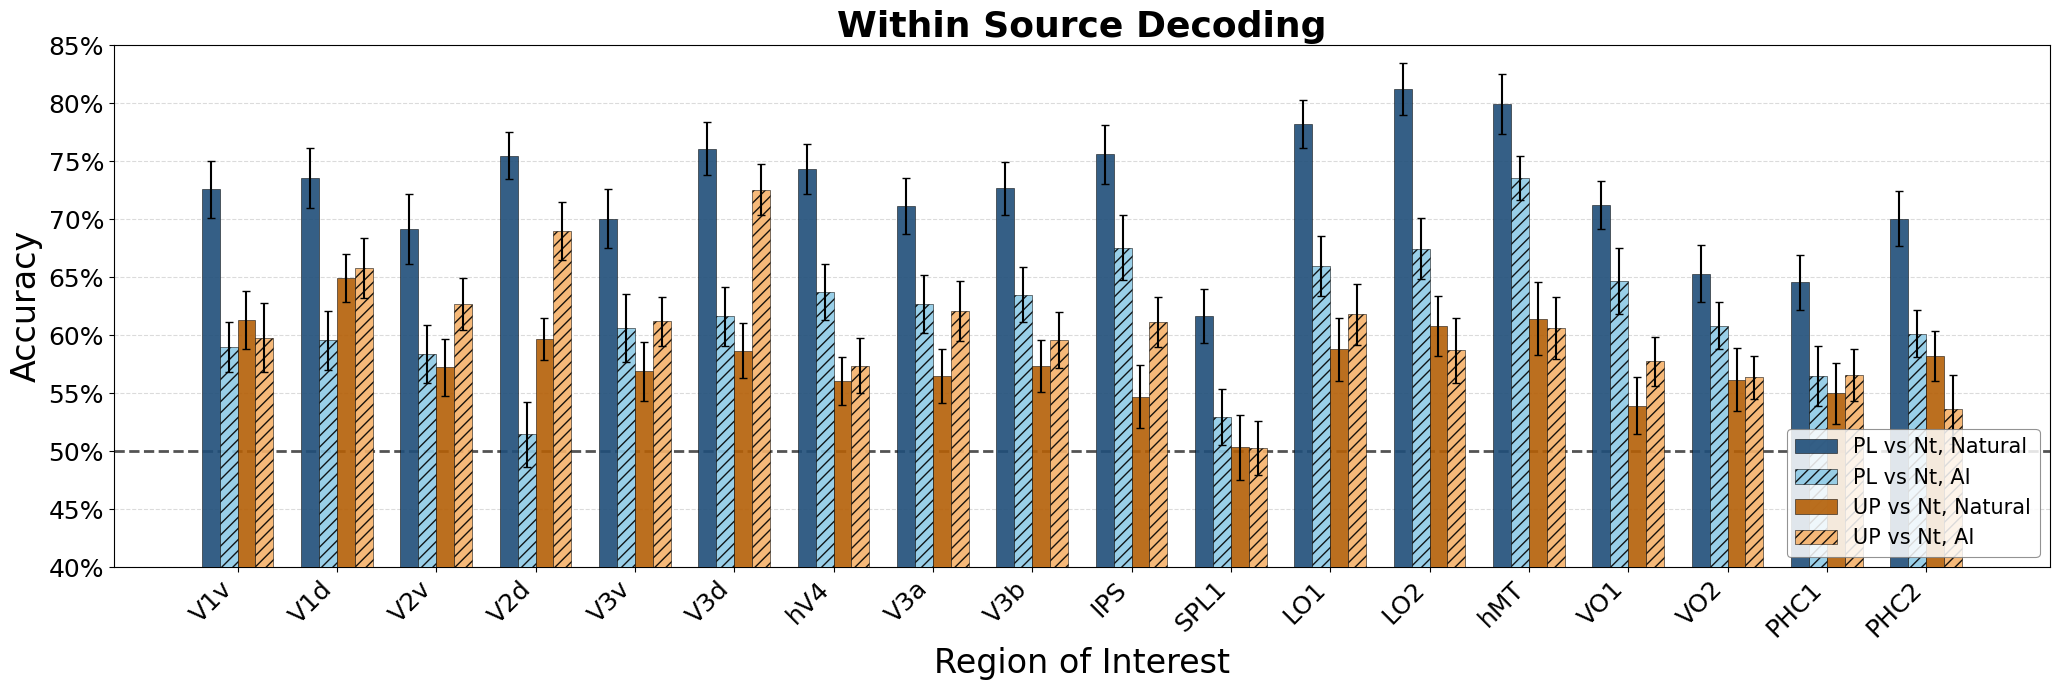

Saved: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\plots_avg_voxel_trial_source_zscore_aal3_all\within_kastner_wang.png


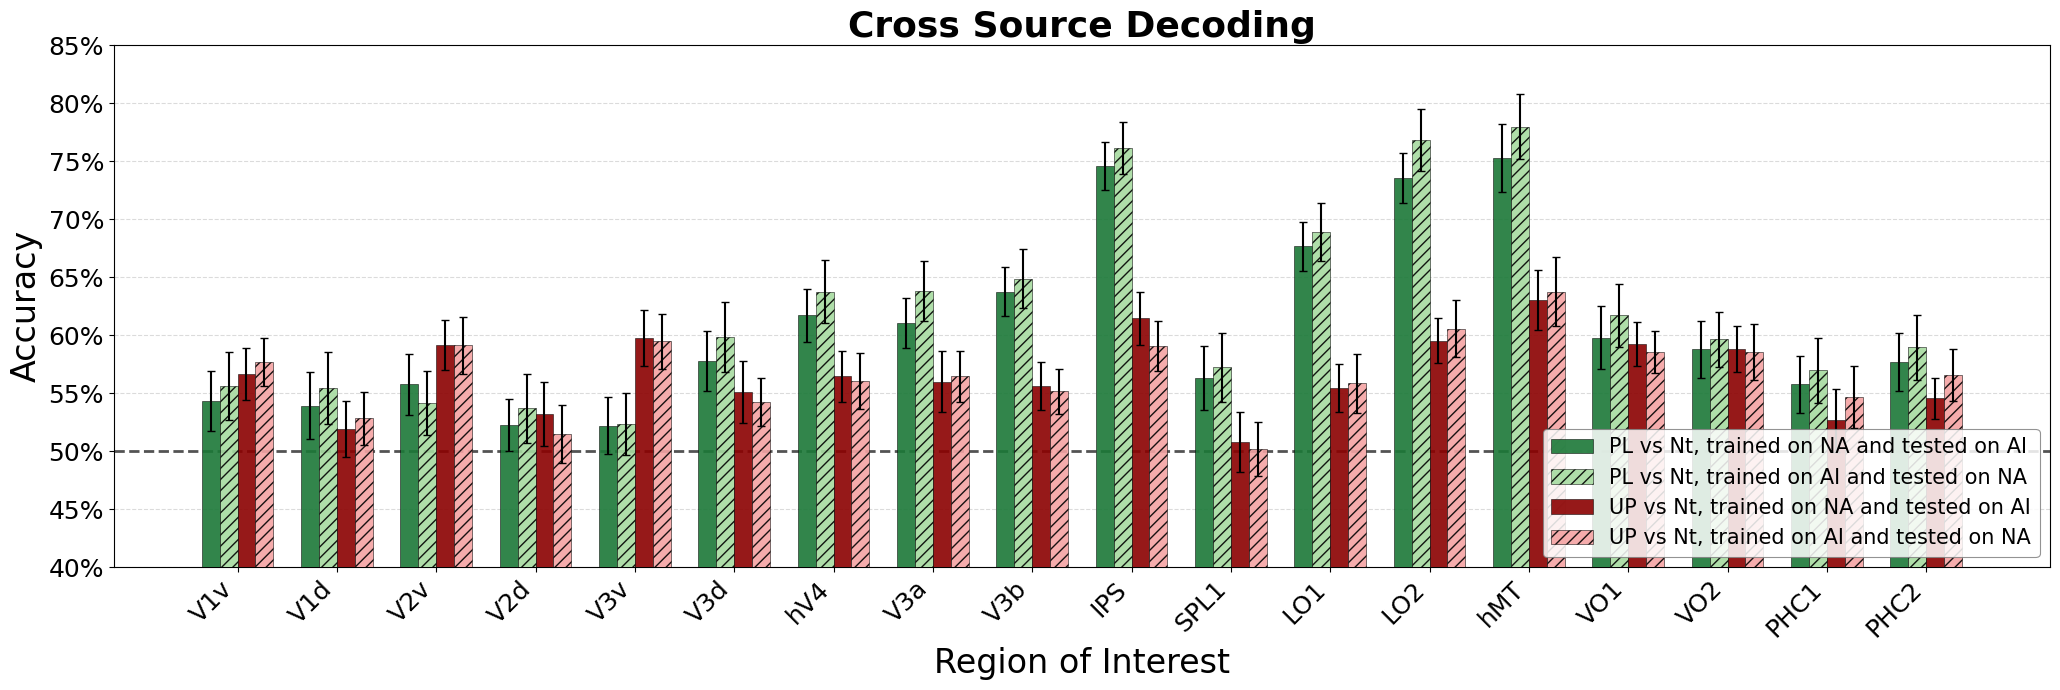

Saved: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\plots_avg_voxel_trial_source_zscore_aal3_all\cross_kastner_wang.png
Top 10 ranked ROIs for Within Source Decoding - AAL3 (voxel_trial_source_zscore): [('Fusiform_R', np.float64(0.746)), ('Occipital_Mid_L', np.float64(0.742)), ('Occipital_Inf_R', np.float64(0.719)), ('Temporal_Mid_R', np.float64(0.718)), ('Occipital_Mid_R', np.float64(0.717)), ('Temporal_Inf_R', np.float64(0.711)), ('Occipital_Inf_L', np.float64(0.709)), ('Fusiform_L', np.float64(0.707)), ('Temporal_Mid_L', np.float64(0.682)), ('Lingual_L', np.float64(0.656))]


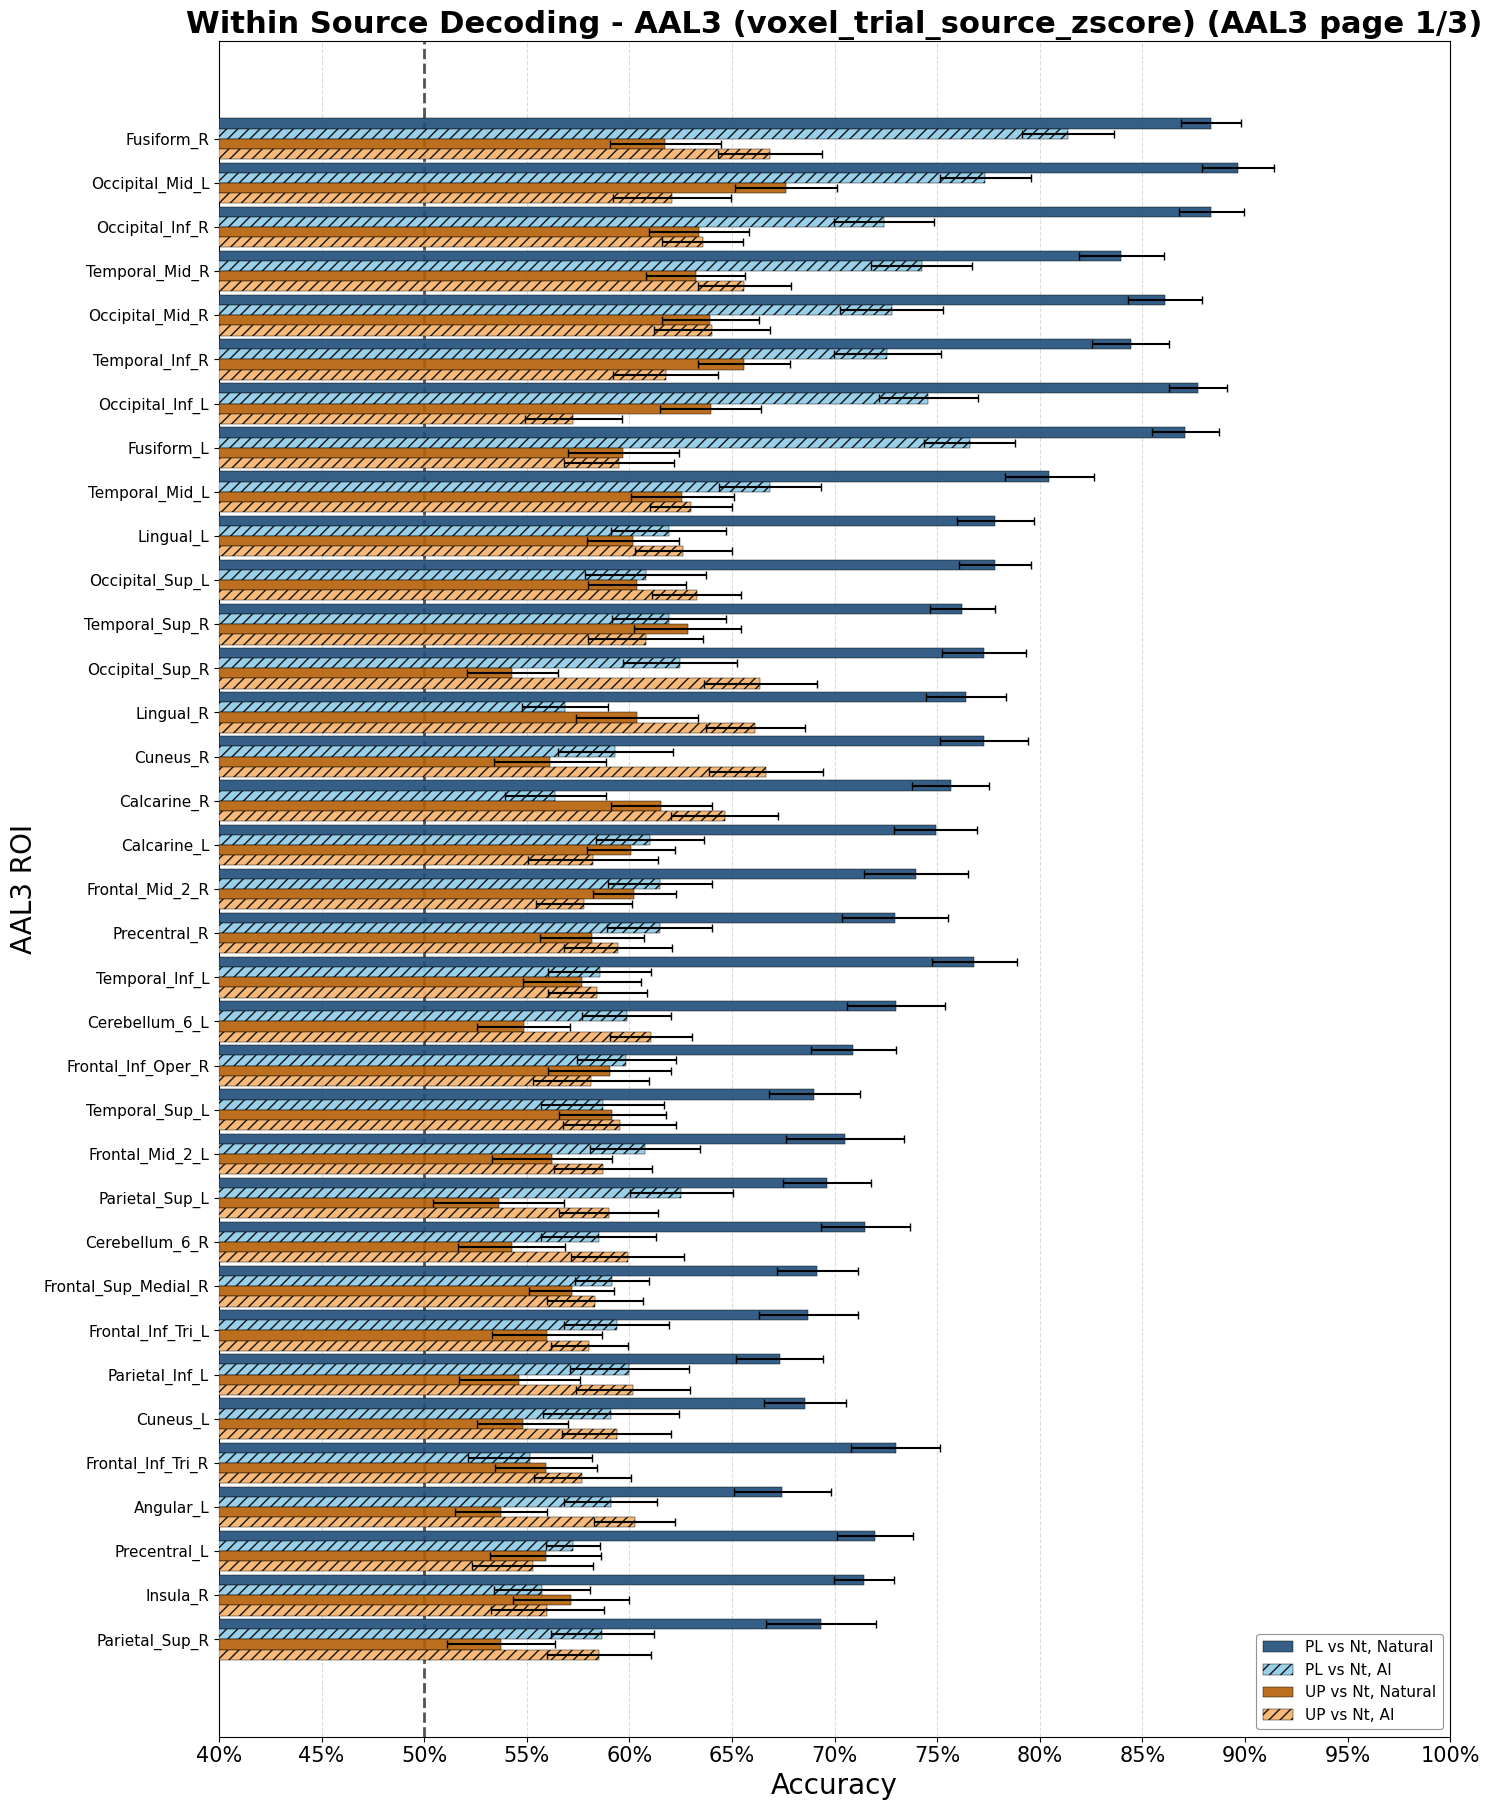

Saved: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\plots_avg_voxel_trial_source_zscore_aal3_all\within_aal3_page01.png


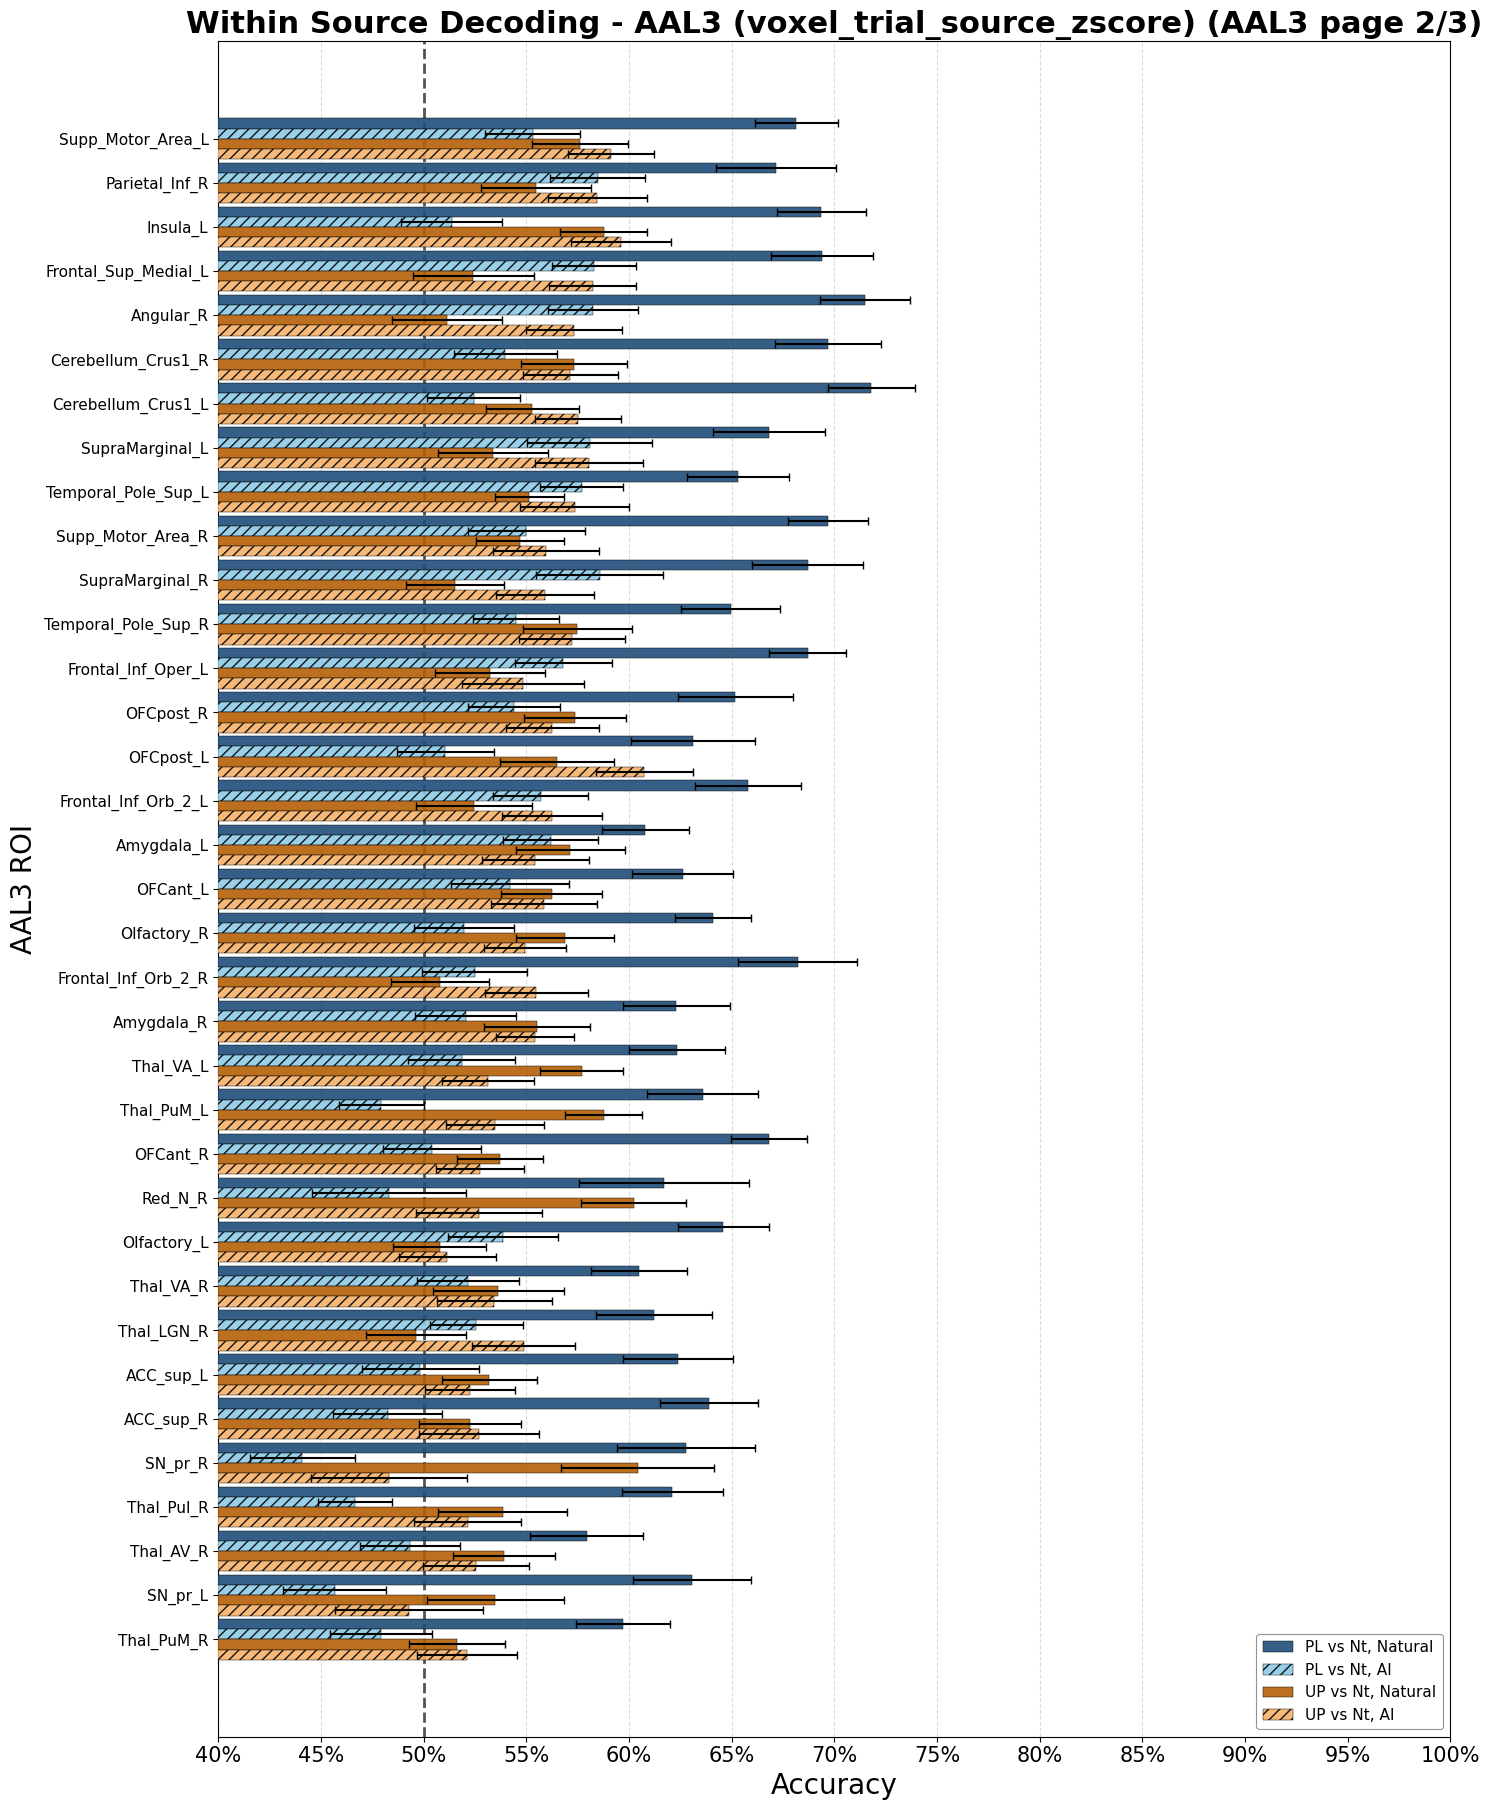

Saved: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\plots_avg_voxel_trial_source_zscore_aal3_all\within_aal3_page02.png


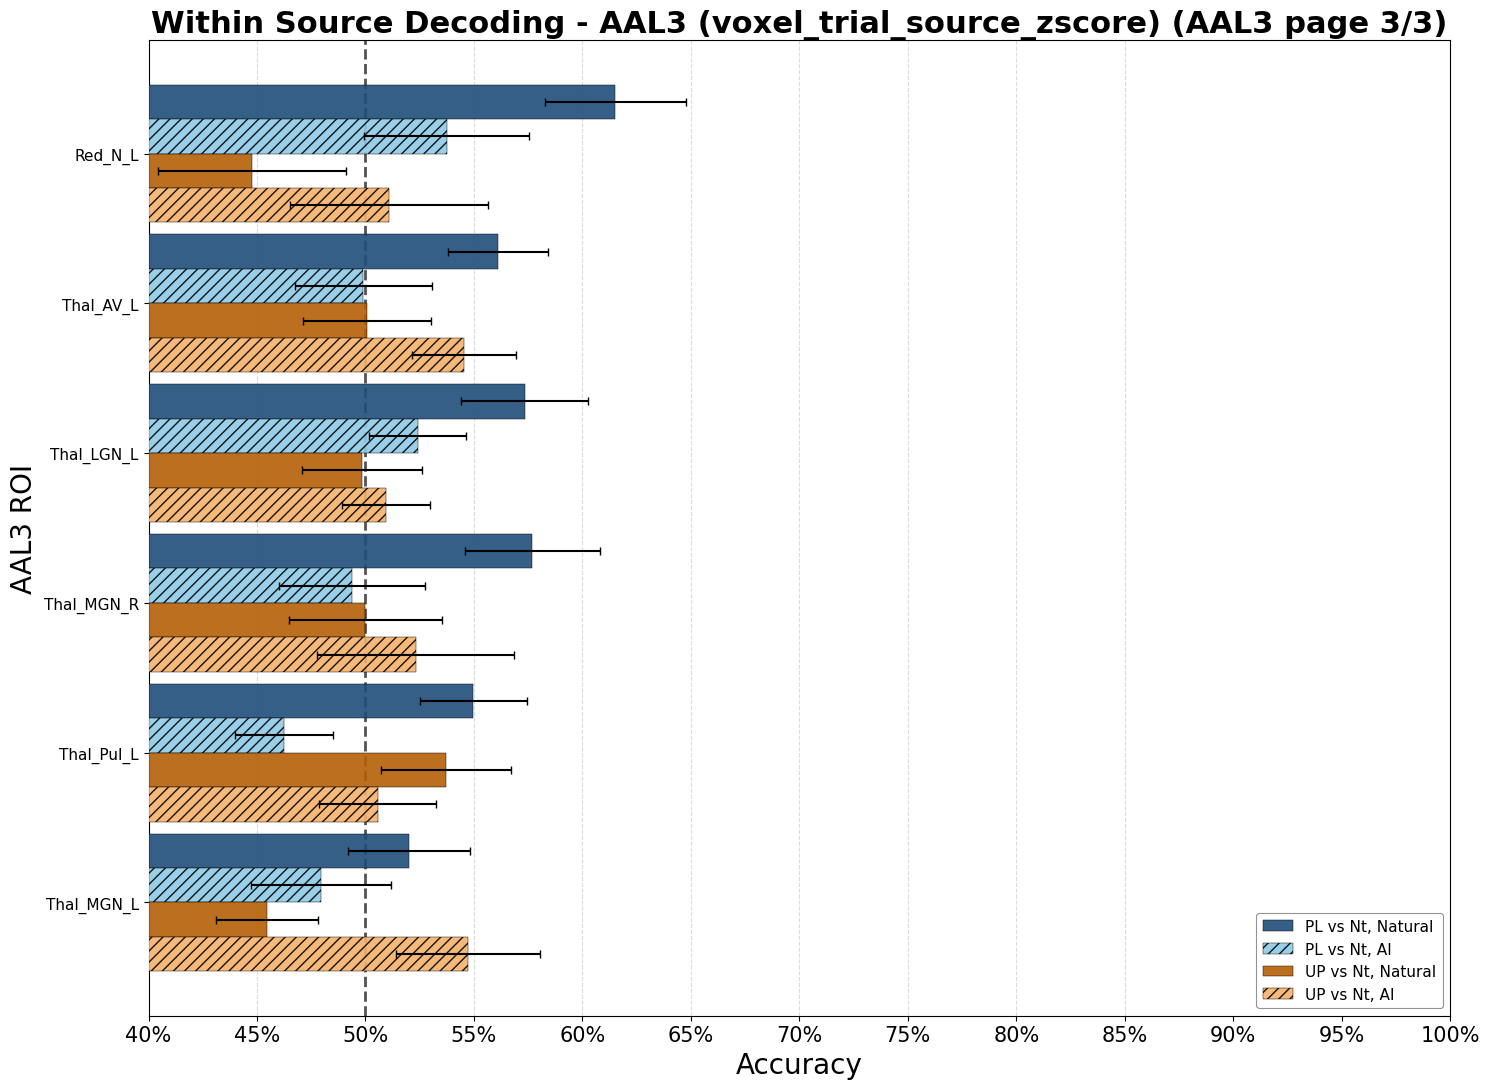

Saved: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\plots_avg_voxel_trial_source_zscore_aal3_all\within_aal3_page03.png
Top 10 ranked ROIs for Cross Source Decoding - AAL3 (voxel_trial_source_zscore): [('Fusiform_R', np.float64(0.757)), ('Temporal_Mid_R', np.float64(0.744)), ('Occipital_Inf_L', np.float64(0.733)), ('Temporal_Inf_R', np.float64(0.73)), ('Fusiform_L', np.float64(0.729)), ('Occipital_Mid_L', np.float64(0.717)), ('Occipital_Mid_R', np.float64(0.713)), ('Occipital_Inf_R', np.float64(0.71)), ('Temporal_Mid_L', np.float64(0.67)), ('Temporal_Inf_L', np.float64(0.653))]


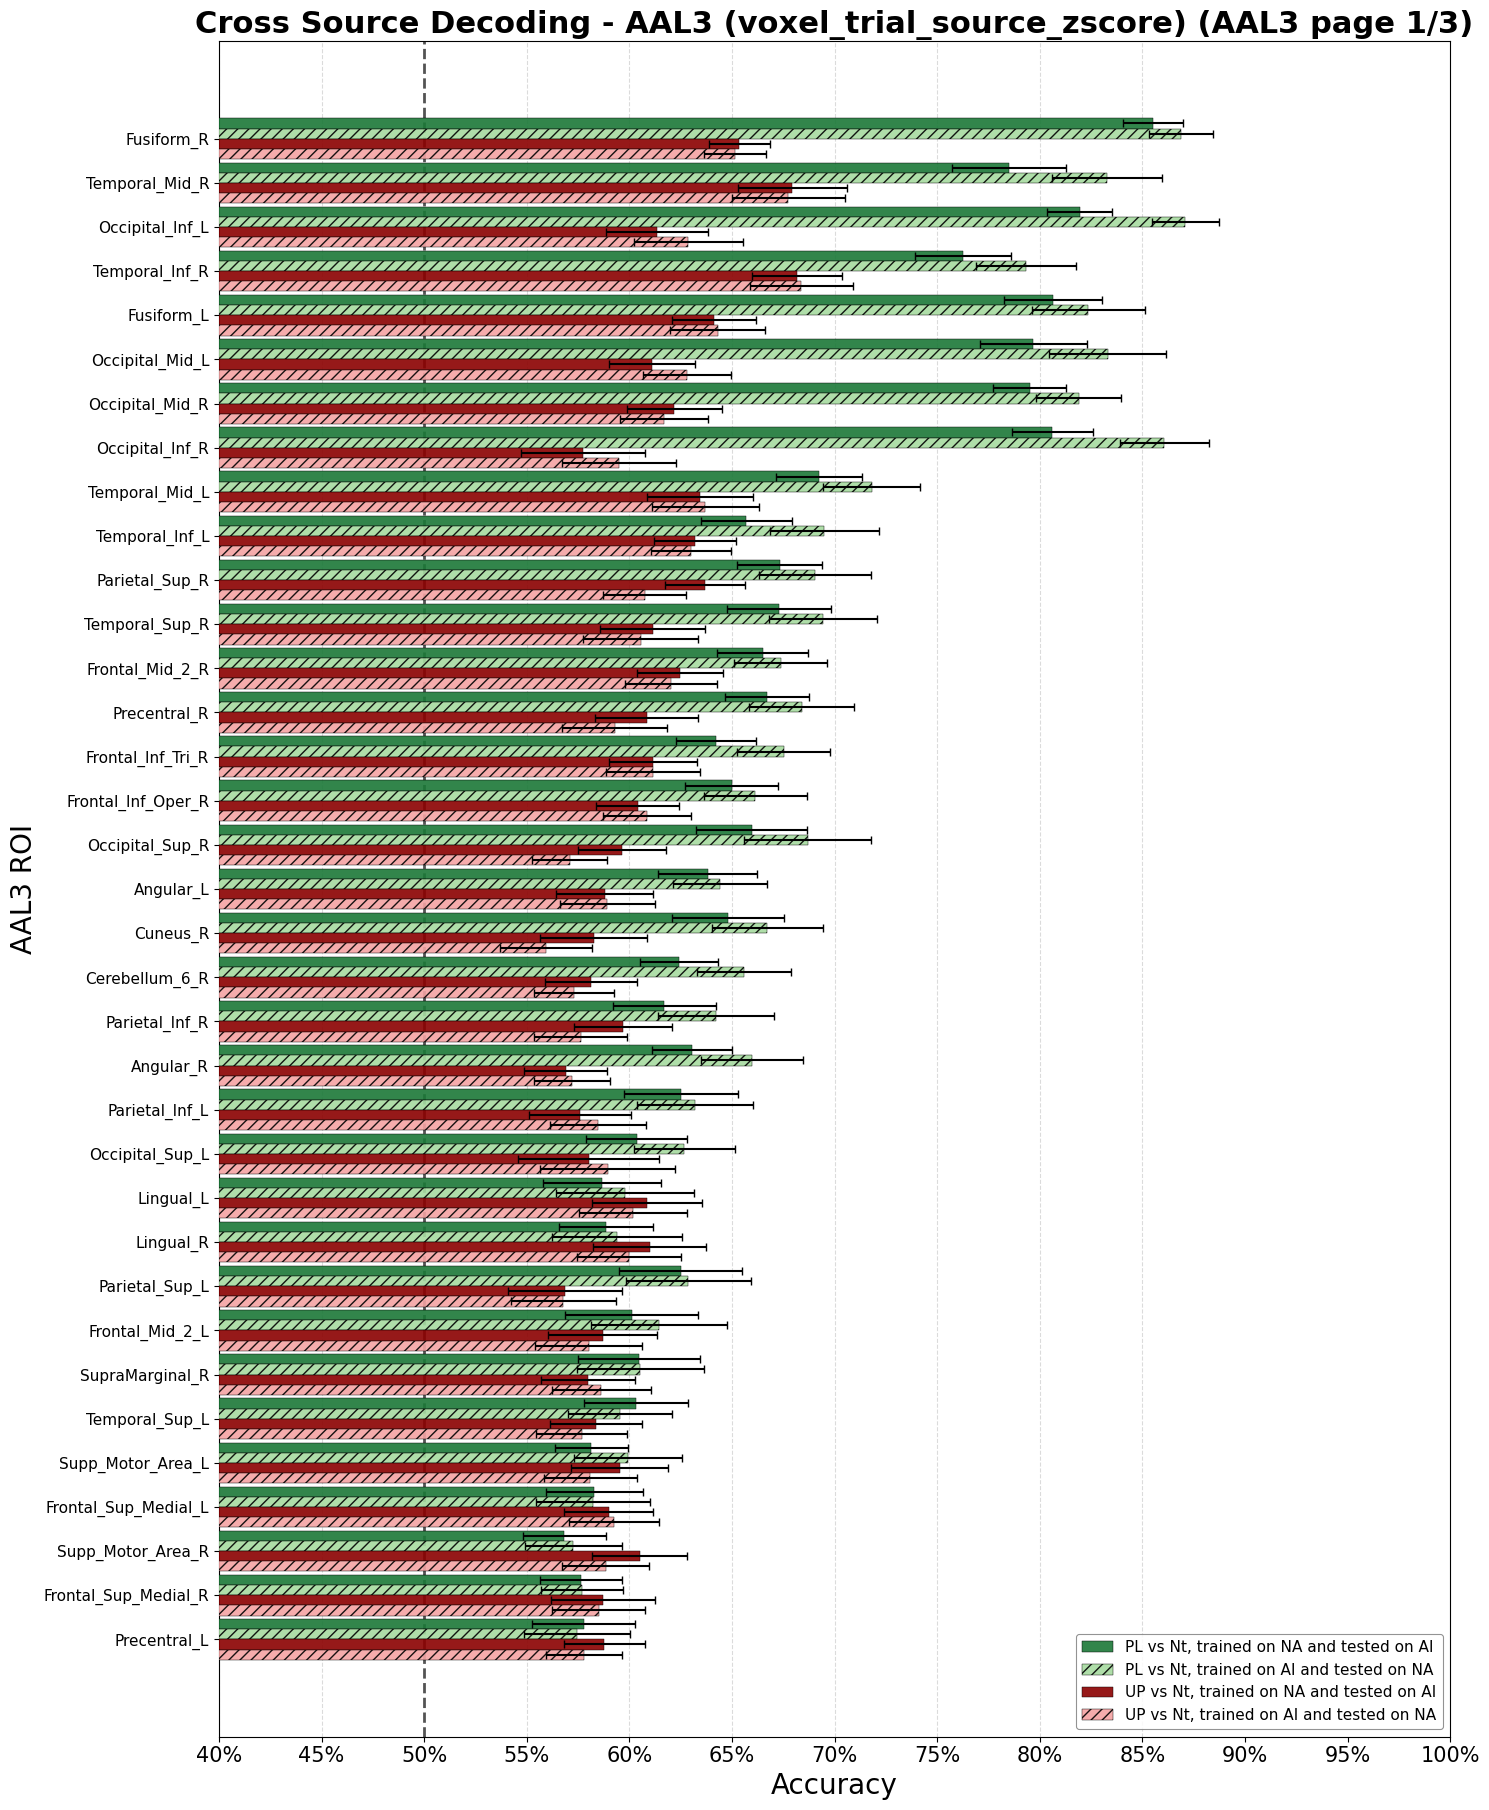

Saved: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\plots_avg_voxel_trial_source_zscore_aal3_all\cross_aal3_page01.png


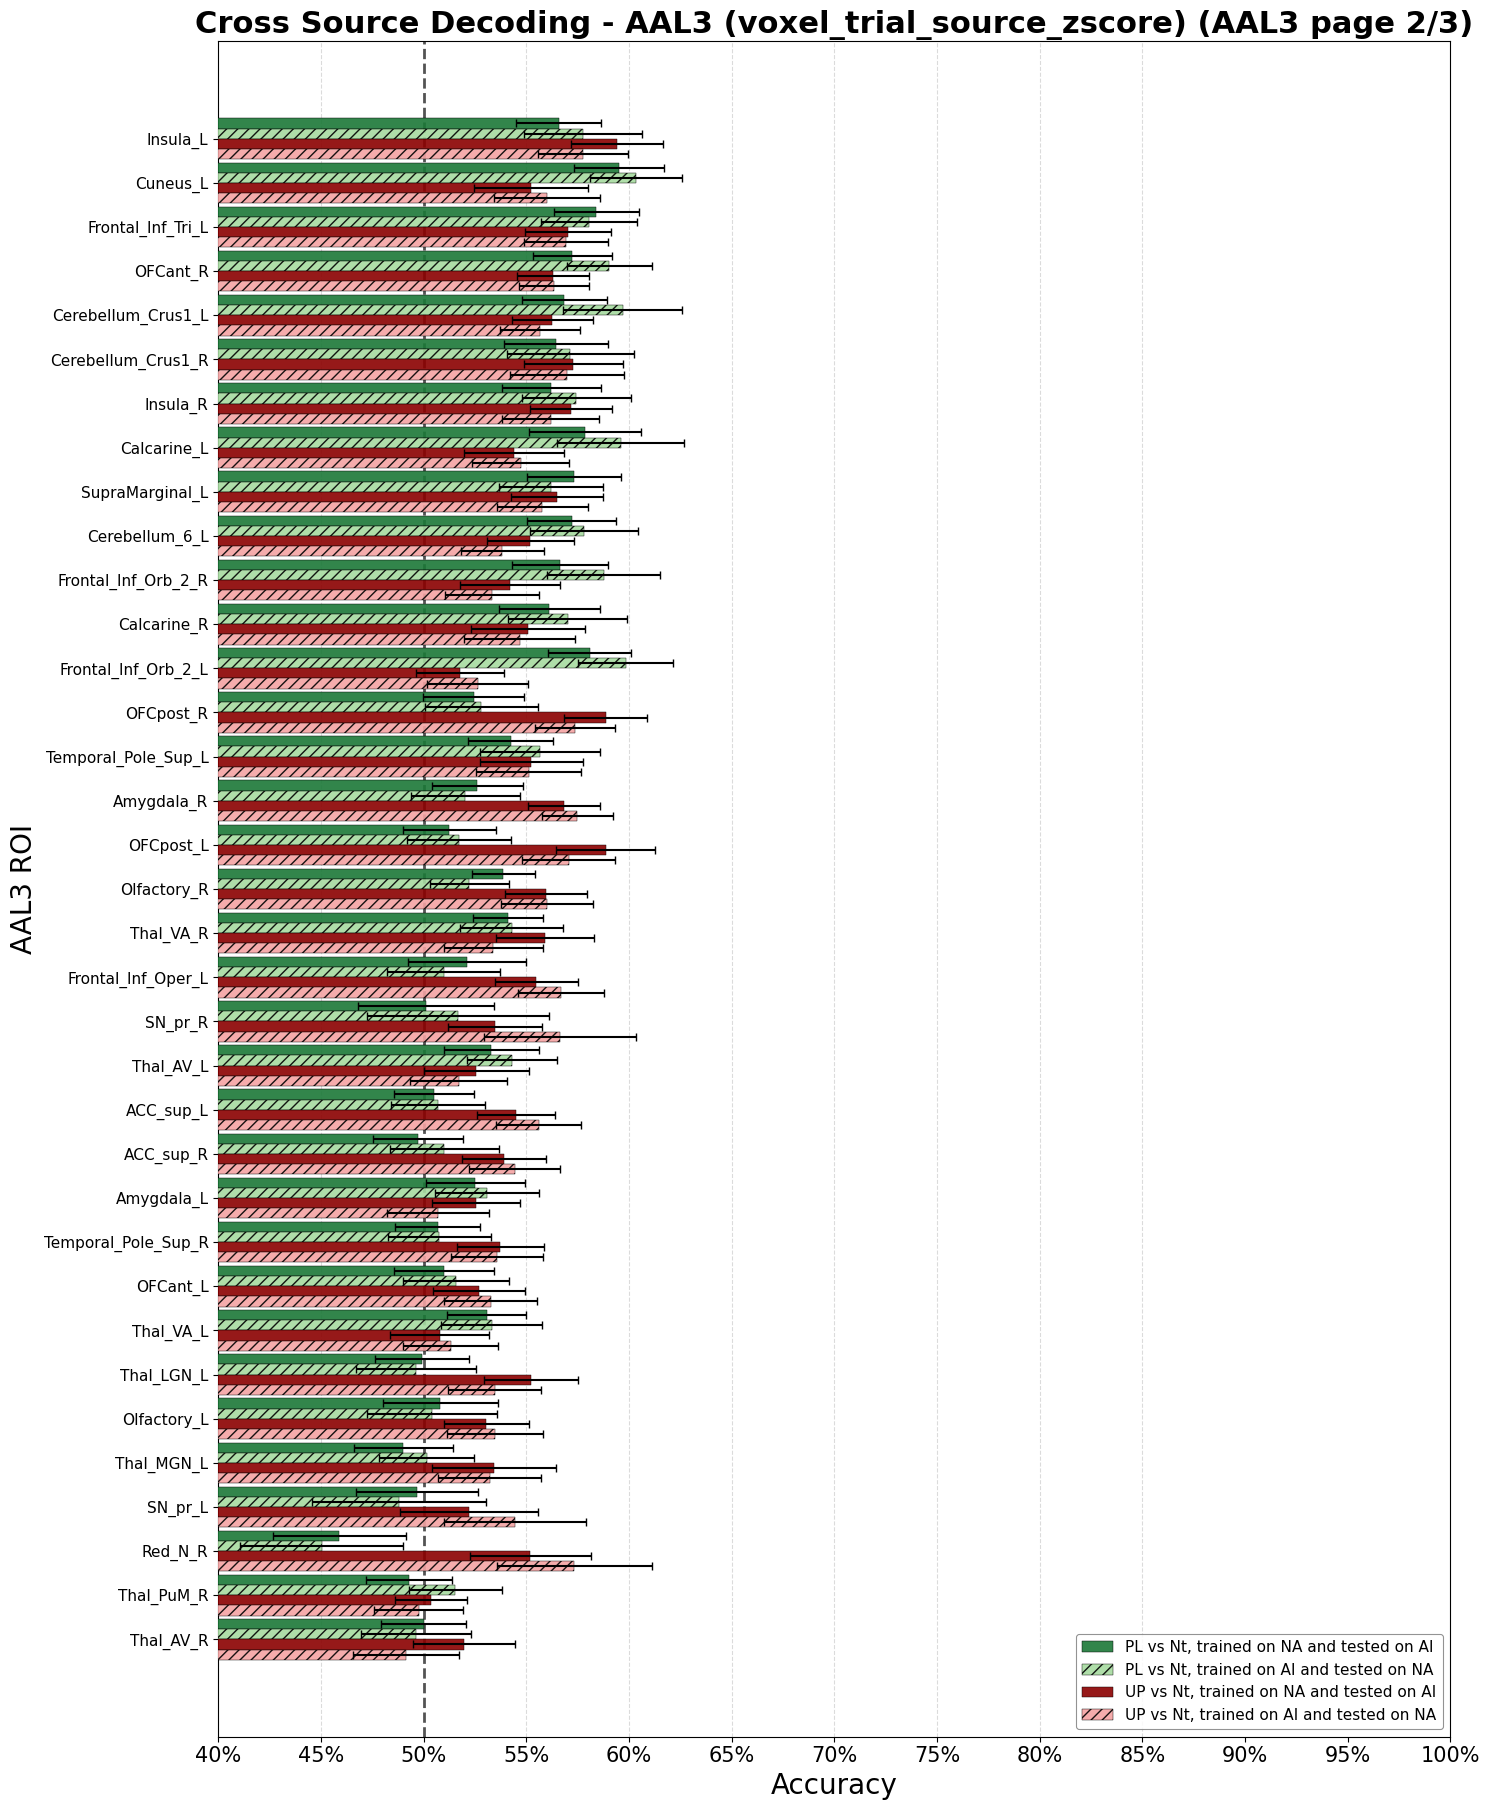

Saved: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\plots_avg_voxel_trial_source_zscore_aal3_all\cross_aal3_page02.png


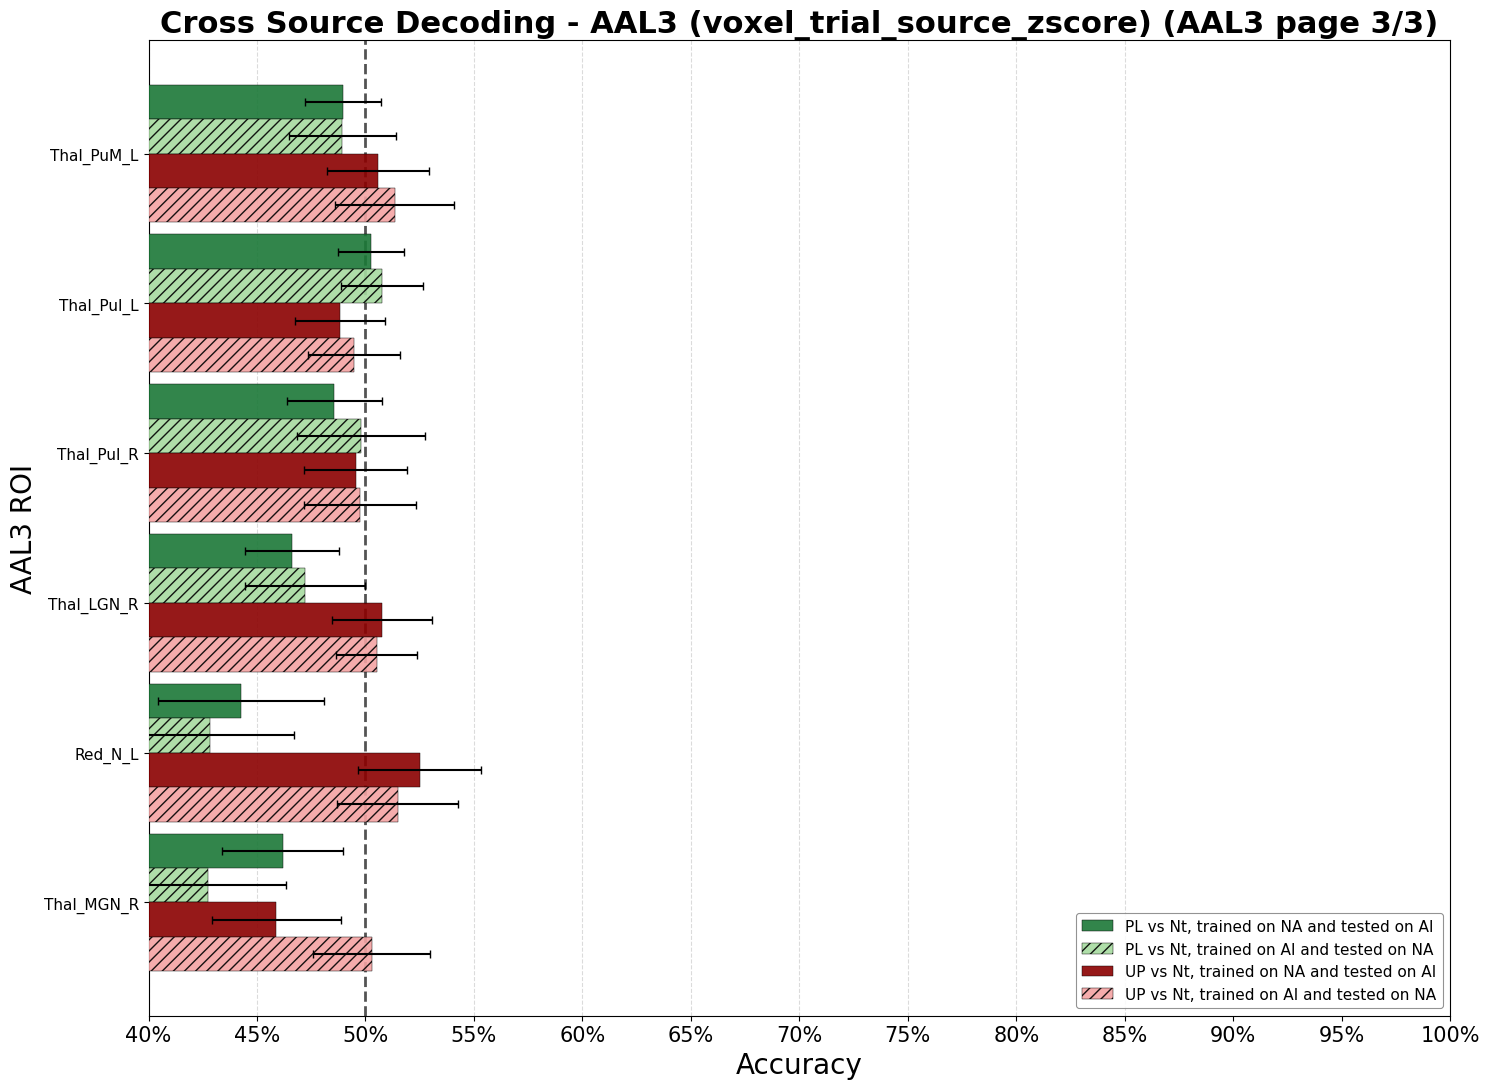

Saved: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\plots_avg_voxel_trial_source_zscore_aal3_all\cross_aal3_page03.png
All plots saved in: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\plots_avg_voxel_trial_source_zscore_aal3_all


In [21]:
import os
import re
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# This cell can run immediately after decoding, or later from the saved pickle.
default_results_path = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\decoding_multisub_avg_voxel_trial_source_zscore_aal3_all.pkl'
if 'all_results' not in globals():
    with open(default_results_path, 'rb') as f:
        all_results = pickle.load(f)
    print(f"Loaded saved results from: {default_results_path}")

results_within_avg = all_results['within_avg']
results_cross_avg = all_results['cross_avg']
subs = all_results['subs']
roi_names = all_results['roi_names']
AVG_MODE = all_results.get('avg_z_mode', 'voxel_trial_source_zscore')

# Match plot_decoding_results.ipynb: exclude Sub3 and Sub8 from group plots.
subs_plot = [s for s in subs if s not in ['Sub3', 'Sub8']]
print(f"Plotting {len(subs_plot)} subjects (excluded Sub3, Sub8 if present)")
print(f"Z-score mode: {AVG_MODE}")

kastner_plot_exclude = {'FEF', 'MST'}
kastner_plot_rois = [
    r for r in all_results.get('kastner_roi_names', [])
    if r in roi_names and r not in kastner_plot_exclude
]
AAL3_TABLE_ROI_NAMES = [
    # Union of AAL3 ROI names shown in the result tables.
    'ACC_sup_L',
    'Amygdala_L', 'Amygdala_R',
    'Angular_R',
    'Cerebellum_6_L', 'Cerebellum_6_R', 'Cerebellum_Crus1_R',
    'Frontal_Inf_Oper_R',
    'Frontal_Inf_Orb_2_L', 'Frontal_Inf_Orb_2_R',
    'Frontal_Inf_Tri_R',
    'Frontal_Mid_2_R',
    'Frontal_Sup_Medial_R',
    'Fusiform_L', 'Fusiform_R',
    'Insula_L', 'Insula_R',
    'OFCant_L', 'OFCpost_L', 'OFCpost_R',
    'Occipital_Inf_L', 'Occipital_Inf_R',
    'Occipital_Mid_L', 'Occipital_Mid_R',
    'Occipital_Sup_R',
    'Olfactory_L', 'Olfactory_R',
    'Parietal_Inf_L', 'Parietal_Inf_R',
    'Parietal_Sup_L', 'Parietal_Sup_R',
    'Precentral_R',
    'Red_N_L', 'Red_N_R',
    'SN_pr_R',
    'Supp_Motor_Area_L', 'Supp_Motor_Area_R',
    'SupraMarginal_R',
    'Temporal_Inf_L', 'Temporal_Inf_R',
    'Temporal_Mid_L', 'Temporal_Mid_R',
    'Temporal_Pole_Sup_L',
    'Temporal_Sup_R',
    'Thal_AV_L',
    'Thal_LGN_R', 'Thal_MGN_R',
    'Thal_PuI_R', 'Thal_PuM_R',
    'Thal_VA_L', 'Thal_VA_R',
    # AAL3 ROIs that appear only in the right-side table.
    'Calcarine_L', 'Calcarine_R',
    'Cuneus_R',
    'Lingual_L', 'Lingual_R',
    'Occipital_Sup_L',
]


def opposite_hemisphere_roi(roi):
    prefix = 'AAL3_' if roi.startswith('AAL3_') else ''
    base = roi[5:] if prefix else roi
    if base.endswith('_L'):
        return f'{prefix}{base[:-2]}_R'
    if base.endswith('_R'):
        return f'{prefix}{base[:-2]}_L'
    return None


def resolve_aal3_table_rois(available_rois):
    available = set(available_rois)
    selected = []
    missing = []
    missing_hemi_pairs = []

    def add_if_available(roi, required=False):
        candidates = [roi, f'AAL3_{roi}'] if not roi.startswith('AAL3_') else [roi, roi[5:]]
        for cand in candidates:
            if cand in available:
                if cand not in selected:
                    selected.append(cand)
                return cand
        if required:
            missing.append(roi)
        else:
            missing_hemi_pairs.append(roi)
        return None

    for roi in AAL3_TABLE_ROI_NAMES:
        resolved = add_if_available(roi, required=True)
        hemi_pair = opposite_hemisphere_roi(resolved or roi)
        if hemi_pair is not None:
            add_if_available(hemi_pair, required=False)
    return selected, missing, missing_hemi_pairs


aal3_plot_rois, missing_aal3_table_rois, missing_aal3_hemi_pairs = resolve_aal3_table_rois(all_results.get('aal3_roi_names', []))

print(f"Kastner/Wang ROIs: {len(kastner_plot_rois)}")
print(f"AAL3 table-union ROIs: {len(aal3_plot_rois)}")
if missing_aal3_table_rois:
    print(f"AAL3 table ROIs not found in results: {missing_aal3_table_rois}")
if missing_aal3_hemi_pairs:
    print(f"Requested opposite-hemisphere AAL3 pairs not found in results: {missing_aal3_hemi_pairs}")

within_colors = {
    'pleasant_vs_neutral': '#1f4e79',
    'pleasantAI_vs_neutralAI': '#8ecae6',
    'unpleasant_vs_neutral': '#b45f06',
    'unpleasantAI_vs_neutralAI': '#f6b26b',
}

cross_colors = {
    'train_pleasantvneutral_test_pleasantAIvneutralAI': '#1b7837',
    'train_pleasantAIvneutralAI_test_pleasantvneutral': '#a6dba0',
    'train_unpleasantvneutral_test_unpleasantAIvneutralAI': '#8b0000',
    'train_unpleasantAIvneutralAI_test_unpleasantvneutral': '#f4a3a3',
}

within_labels = {
    'pleasant_vs_neutral': 'PL vs Nt, Natural',
    'pleasantAI_vs_neutralAI': 'PL vs Nt, AI',
    'unpleasant_vs_neutral': 'UP vs Nt, Natural',
    'unpleasantAI_vs_neutralAI': 'UP vs Nt, AI',
}

cross_labels = {
    'train_pleasantvneutral_test_pleasantAIvneutralAI': 'PL vs Nt, trained on NA and tested on AI',
    'train_pleasantAIvneutralAI_test_pleasantvneutral': 'PL vs Nt, trained on AI and tested on NA',
    'train_unpleasantvneutral_test_unpleasantAIvneutralAI': 'UP vs Nt, trained on NA and tested on AI',
    'train_unpleasantAIvneutralAI_test_unpleasantvneutral': 'UP vs Nt, trained on AI and tested on NA',
}

within_order = [
    'pleasant_vs_neutral',
    'pleasantAI_vs_neutralAI',
    'unpleasant_vs_neutral',
    'unpleasantAI_vs_neutralAI',
]

cross_order = [
    'train_pleasantvneutral_test_pleasantAIvneutralAI',
    'train_pleasantAIvneutralAI_test_pleasantvneutral',
    'train_unpleasantvneutral_test_unpleasantAIvneutralAI',
    'train_unpleasantAIvneutralAI_test_unpleasantvneutral',
]

plots_dir = os.path.join(
    os.path.dirname(default_results_path),
    'plots_avg_voxel_trial_source_zscore_aal3_all'
)
os.makedirs(plots_dir, exist_ok=True)


def _sanitize_filename(text):
    text = re.sub(r'[^A-Za-z0-9_.-]+', '_', text)
    return text.strip('_')


def collect_avg_data(result_dict, comp, rois):
    """Collect n_subjects x n_rois accuracy values for one comparison."""
    return np.array([
        [result_dict.get(s, {}).get(comp, {}).get(AVG_MODE, {}).get(r, np.nan) for r in rois]
        for s in subs_plot
    ], dtype=float)


def mean_sem(data):
    means = np.nanmean(data, axis=0)
    n = np.sum(~np.isnan(data), axis=0)
    sems = np.full(data.shape[1], np.nan, dtype=float)
    valid = n > 1
    if np.any(valid):
        sems[valid] = np.nanstd(data[:, valid], axis=0, ddof=1) / np.sqrt(n[valid])
    sems[n == 1] = 0.0
    return means, sems


def is_ai_style_bar(comp):
    """Use hatch marks for AI-source bars."""
    return ('AI_vs' in comp) or comp.startswith('train_pleasantAI') or comp.startswith('train_unpleasantAI')


def hatch_for_comp(comp):
    return '///' if is_ai_style_bar(comp) else None


def rank_rois_by_decoding_accuracy(result_dict, comp_order, rois):
    """Rank ROIs by mean decoding accuracy across all bars in one plot."""
    if not rois:
        return [], {}
    score_sum = np.zeros(len(rois), dtype=float)
    score_n = np.zeros(len(rois), dtype=int)
    for comp in comp_order:
        data = collect_avg_data(result_dict, comp, rois)
        means, _ = mean_sem(data)
        valid = np.isfinite(means)
        score_sum[valid] += means[valid]
        score_n[valid] += 1
    scores = np.full(len(rois), np.nan, dtype=float)
    valid = score_n > 0
    scores[valid] = score_sum[valid] / score_n[valid]
    order = sorted(
        range(len(rois)),
        key=lambda i: (not np.isfinite(scores[i]), -scores[i] if np.isfinite(scores[i]) else 0, rois[i])
    )
    ranked_rois = [rois[i] for i in order]
    return ranked_rois, {rois[i]: scores[i] for i in range(len(rois))}


def add_percent_guide_lines(ax, axis='x', low=0.40, high=0.85):
    """Dashed guide lines every 5%; chance line at 50% is darker and thicker."""
    values = np.arange(low, high + 0.001, 0.05)
    for value in values:
        is_chance = np.isclose(value, 0.50)
        kwargs = dict(
            color='#4A4A4A' if is_chance else '#D0D0D0',
            linestyle='--',
            linewidth=2.0 if is_chance else 0.8,
            alpha=0.95 if is_chance else 0.75,
            zorder=0,
        )
        if axis == 'x':
            ax.axvline(x=value, **kwargs)
        else:
            ax.axhline(y=value, **kwargs)


def plot_roi_group_vertical(result_dict, comp_order, color_dict, label_dict, rois, title, outfile):
    """Grouped vertical bars for a compact ROI set, e.g. Kastner/Wang."""
    if not rois:
        print(f"Skipping {title}: no ROIs found.")
        return

    x = np.arange(len(rois))
    n_comps = len(comp_order)
    width = min(0.18, 0.80 / n_comps)

    fig, ax = plt.subplots(figsize=(max(18, len(rois) * 1.15), 7))
    for ci, comp in enumerate(comp_order):
        data = collect_avg_data(result_dict, comp, rois)
        means, sems = mean_sem(data)
        offset = (ci - (n_comps - 1) / 2) * width
        ax.bar(
            x + offset, means, width, yerr=sems,
            color=color_dict[comp], label=label_dict[comp],
            hatch=hatch_for_comp(comp),
            capsize=3, alpha=0.9, edgecolor='black', linewidth=0.4,
            zorder=3,
        )

    add_percent_guide_lines(ax, axis='y')
    ax.set_ylabel('Accuracy', fontsize=24)
    ax.set_xlabel('Region of Interest', fontsize=24)
    ax.set_title(title, fontsize=26, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.05))
    ax.tick_params(axis='y', labelsize=18)
    ax.set_xticks(x)
    ax.set_xticklabels(rois, rotation=45, ha='right', fontsize=18)
    ax.set_ylim([0.40, 0.85])
    legend = ax.legend(fontsize=15, loc='lower right', frameon=True,
                       facecolor='white', framealpha=0.85, edgecolor='gray')
    legend.get_frame().set_linewidth(0.8)
    plt.tight_layout()
    fig.savefig(outfile, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {outfile}")


def plot_roi_group_horizontal_pages(result_dict, comp_order, color_dict, label_dict,
                                    rois, title, outfile_prefix, chunk_size=35):
    """Paged horizontal grouped bars for large ROI sets, e.g. AAL3."""
    if not rois:
        print(f"Skipping {title}: no ROIs found.")
        return

    ranked_rois, roi_rank_scores = rank_rois_by_decoding_accuracy(result_dict, comp_order, rois)
    top_rois = [(r, round(roi_rank_scores.get(r, np.nan), 3)) for r in ranked_rois[:10]]
    print(f"Top 10 ranked ROIs for {title}: {top_rois}")

    n_comps = len(comp_order)
    height = min(0.24, 0.92 / n_comps)
    n_pages = int(np.ceil(len(ranked_rois) / chunk_size))

    for page_idx, start in enumerate(range(0, len(ranked_rois), chunk_size), start=1):
        chunk = ranked_rois[start:start + chunk_size]
        y = np.arange(len(chunk))
        fig_h = max(11, len(chunk) * 0.52)
        fig, ax = plt.subplots(figsize=(15, fig_h))

        for ci, comp in enumerate(comp_order):
            data = collect_avg_data(result_dict, comp, chunk)
            means, sems = mean_sem(data)
            offset = (ci - (n_comps - 1) / 2) * height
            ax.barh(
                y + offset, means, height, xerr=sems,
                color=color_dict[comp], label=label_dict[comp],
                hatch=hatch_for_comp(comp),
                capsize=3, alpha=0.9, edgecolor='black', linewidth=0.35,
                zorder=3,
            )

        add_percent_guide_lines(ax, axis='x')
        ax.set_xlabel('Accuracy', fontsize=20)
        ax.set_ylabel('AAL3 ROI', fontsize=20)
        ax.set_title(f'{title} (AAL3 page {page_idx}/{n_pages})', fontsize=22, fontweight='bold')
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
        ax.xaxis.set_major_locator(mticker.MultipleLocator(0.05))
        ax.tick_params(axis='x', labelsize=15)
        ax.set_yticks(y)
        ax.set_yticklabels(chunk, fontsize=11)
        ax.invert_yaxis()
        ax.set_xlim([0.40, 1.00])
        ax.set_axisbelow(True)
        legend = ax.legend(fontsize=11, loc='lower right', frameon=True,
                           facecolor='white', framealpha=0.85, edgecolor='gray')
        legend.get_frame().set_linewidth(0.8)
        plt.tight_layout()
        outfile = f"{outfile_prefix}_page{page_idx:02d}.png"
        fig.savefig(outfile, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Saved: {outfile}")


# Kastner/Wang: compact enough for the original horizontal x-axis ROI layout.
plot_roi_group_vertical(
    results_within_avg, within_order, within_colors, within_labels,
    kastner_plot_rois,
    'Within Source Decoding',
    os.path.join(plots_dir, 'within_kastner_wang.png'),
)

plot_roi_group_vertical(
    results_cross_avg, cross_order, cross_colors, cross_labels,
    kastner_plot_rois,
    'Cross Source Decoding',
    os.path.join(plots_dir, 'cross_kastner_wang.png'),
)

# AAL3: selected table-union ROIs are expanded bilaterally and ranked by plot-specific decoding accuracy.
AAL3_CHUNK_SIZE = 35
plot_roi_group_horizontal_pages(
    results_within_avg, within_order, within_colors, within_labels,
    aal3_plot_rois,
    f'Within Source Decoding - AAL3 ({AVG_MODE})',
    os.path.join(plots_dir, 'within_aal3'),
    chunk_size=AAL3_CHUNK_SIZE,
)

plot_roi_group_horizontal_pages(
    results_cross_avg, cross_order, cross_colors, cross_labels,
    aal3_plot_rois,
    f'Cross Source Decoding - AAL3 ({AVG_MODE})',
    os.path.join(plots_dir, 'cross_aal3'),
    chunk_size=AAL3_CHUNK_SIZE,
)

print(f"All plots saved in: {plots_dir}")


## AAL3 3D Brain Accuracy Maps - Hot Colormap

In [26]:
import os
import re
import pickle
import numpy as np
import pandas as pd
import nibabel as nib
from nilearn import plotting, datasets

default_results_path = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\decoding_multisub_avg_voxel_trial_source_zscore_aal3_all.pkl'

if 'all_results' not in globals():
    with open(default_results_path, 'rb') as f:
        all_results = pickle.load(f)

results_within_avg = all_results['within_avg']
results_cross_avg = all_results['cross_avg']
subs = all_results['subs']
roi_names = all_results['roi_names']
AVG_MODE = all_results.get('avg_z_mode', 'voxel_trial_source_zscore')
aal3_atlas_file = all_results['aal3_atlas_file']
aal3_label_file = all_results['aal3_label_file']

subs_plot = [s for s in subs if s not in ['Sub3', 'Sub8']]

within_order = [
    'pleasant_vs_neutral',
    'pleasantAI_vs_neutralAI',
    'unpleasant_vs_neutral',
    'unpleasantAI_vs_neutralAI',
]

cross_order = [
    'train_pleasantvneutral_test_pleasantAIvneutralAI',
    'train_pleasantAIvneutralAI_test_pleasantvneutral',
    'train_unpleasantvneutral_test_unpleasantAIvneutralAI',
    'train_unpleasantAIvneutralAI_test_unpleasantvneutral',
]

within_titles = {
    'pleasant_vs_neutral': 'PL vs Nt, Natural',
    'pleasantAI_vs_neutralAI': 'PL vs Nt, AI',
    'unpleasant_vs_neutral': 'UP vs Nt, Natural',
    'unpleasantAI_vs_neutralAI': 'UP vs Nt, AI',
}

cross_titles = {
    'train_pleasantvneutral_test_pleasantAIvneutralAI': 'PL vs Nt, trained on Natural and tested on AI',
    'train_pleasantAIvneutralAI_test_pleasantvneutral': 'PL vs Nt, trained on AI and tested on Natural',
    'train_unpleasantvneutral_test_unpleasantAIvneutralAI': 'UP vs Nt, trained on Natural and tested on AI',
    'train_unpleasantAIvneutralAI_test_unpleasantvneutral': 'UP vs Nt, trained on AI and tested on Natural',
}

out_dir = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\aal3_3d_brain_accuracy_maps_voxel_trial_source_zscore'
os.makedirs(out_dir, exist_ok=True)


def parse_mricrogl_label_file(label_file):
    labels = {}
    with open(label_file, 'r', encoding='utf-8-sig') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 2:
                continue
            try:
                roi_id = int(float(parts[0]))
            except ValueError:
                continue
            roi_name = parts[1]
            if roi_id > 0 and roi_name != '*.*.*.*.*':
                labels[roi_id] = roi_name
    return labels


def sanitize_filename(text):
    return re.sub(r'[^A-Za-z0-9_.-]+', '_', text).strip('_')


def roi_to_aal3_label_name(roi):
    return roi[5:] if roi.startswith('AAL3_') else roi


def get_aal3_rois():
    rois = [r for r in all_results.get('aal3_roi_names', []) if r in roi_names]
    for r in all_results.get('aal3_roi_names', []):
        prefixed = f'AAL3_{r}'
        if prefixed in roi_names and prefixed not in rois:
            rois.append(prefixed)
    return rois


def mean_accuracy_by_roi(result_dict, comp, rois):
    values = {}
    for roi in rois:
        vals = [
            result_dict.get(s, {}).get(comp, {}).get(AVG_MODE, {}).get(roi, np.nan)
            for s in subs_plot
        ]
        values[roi] = float(np.nanmean(vals)) if np.any(~np.isnan(vals)) else np.nan
    return values


def make_aal3_accuracy_img(roi_values, aal3_img, aal3_data, name_to_id):
    acc_data = np.zeros(aal3_data.shape, dtype=np.float32)
    missing = []

    for roi, acc in roi_values.items():
        if not np.isfinite(acc):
            continue

        label_name = roi_to_aal3_label_name(roi)
        roi_id = name_to_id.get(label_name)

        if roi_id is None:
            missing.append(roi)
            continue

        acc_data[aal3_data == roi_id] = np.float32(acc)

    img = nib.Nifti1Image(acc_data, aal3_img.affine)
    img.set_data_dtype(np.float32)
    img.header['cal_min'] = 0.5
    img.header['cal_max'] = 1.0
    img.header['descrip'] = b'AAL3 decoding accuracy map, raw 0-1 accuracy'

    return img, missing


def save_accuracy_map(result_dict, comp, title, prefix, aal3_img, aal3_data, name_to_id, aal3_rois, bg_img):
    roi_values = mean_accuracy_by_roi(result_dict, comp, aal3_rois)
    acc_img, missing = make_aal3_accuracy_img(roi_values, aal3_img, aal3_data, name_to_id)

    base = f'{prefix}_{sanitize_filename(comp)}'
    nii_path = os.path.join(out_dir, f'{base}_accuracy.nii.gz')
    html_path = os.path.join(out_dir, f'{base}_3d_view.html')
    png_path = os.path.join(out_dir, f'{base}_ortho_hot.png')
    csv_path = os.path.join(out_dir, f'{base}_roi_values.csv')

    nib.save(acc_img, nii_path)

    pd.DataFrame({
        'roi': list(roi_values.keys()),
        'mean_accuracy_raw_0_to_1': list(roi_values.values()),
        'mean_accuracy_percent': [
            v * 100 if np.isfinite(v) else np.nan
            for v in roi_values.values()
        ],
    }).to_csv(csv_path, index=False)

    view = plotting.view_img(
        acc_img,
        bg_img=bg_img,
        title=title,
        cmap='hot',
        symmetric_cmap=False,
        threshold=0.5,
        vmin=0.5,
        vmax=1.0,
        opacity=0.85,
    )
    view.save_as_html(html_path)

    display = plotting.plot_stat_map(
        acc_img,
        bg_img=bg_img,
        title=title,
        display_mode='ortho',
        cut_coords=(3, -24, 12),
        cmap='hot',
        symmetric_cbar=False,
        threshold=0.5,
        vmin=0.5,
        vmax=1.0,
        colorbar=True,
        black_bg=True,
    )
    display.savefig(png_path, dpi=300)
    display.close()

    if missing:
        print(f'Warning: {comp} missing {len(missing)} AAL3 labels: {missing[:10]}')

    print(f'Saved NIfTI: {nii_path}')
    print(f'Saved HTML:  {html_path}')
    print(f'Saved PNG:   {png_path}')
    print(f'Saved CSV:   {csv_path}')


aal3_labels = parse_mricrogl_label_file(aal3_label_file)
name_to_id = {name: roi_id for roi_id, name in aal3_labels.items()}

aal3_img = nib.load(aal3_atlas_file)
aal3_data = np.rint(aal3_img.get_fdata()).astype(np.int32)

aal3_rois = get_aal3_rois()
bg_img = datasets.load_mni152_template()

print(f'Creating AAL3 raw accuracy maps for {len(aal3_rois)} ROIs')
print(f'Output folder: {out_dir}')
print('Color map: hot')
print('Color max: 1.0')

for comp in within_order:
    save_accuracy_map(
        results_within_avg,
        comp,
        within_titles[comp],
        'within',
        aal3_img,
        aal3_data,
        name_to_id,
        aal3_rois,
        bg_img,
    )

for comp in cross_order:
    save_accuracy_map(
        results_cross_avg,
        comp,
        cross_titles[comp],
        'cross',
        aal3_img,
        aal3_data,
        name_to_id,
        aal3_rois,
        bg_img,
    )

print('Done.')

Creating AAL3 raw accuracy maps for 166 ROIs
Output folder: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\aal3_3d_brain_accuracy_maps_voxel_trial_source_zscore
Color map: hot
Color max: 1.0
Saved NIfTI: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\aal3_3d_brain_accuracy_maps_voxel_trial_source_zscore\within_pleasant_vs_neutral_accuracy.nii.gz
Saved HTML:  N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\aal3_3d_brain_accuracy_maps_voxel_trial_source_zscore\within_pleasant_vs_neutral_3d_view.html
Saved PNG:   N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\aal3_3d_brain_accuracy_maps_voxel_trial_source_zscore\within_pleasant_vs_neutral_ortho_hot.png
Saved CSV:   N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\aal3_3d_brain_accuracy_maps_voxel_trial_source_zscore\within_pleasant_vs_neutral_roi_values.csv
Saved NIfTI: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\aal3_3d_brain_accur

In [28]:
import os
import re
import pickle
import numpy as np
import pandas as pd
import nibabel as nib
from nilearn import plotting, datasets

default_results_path = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\decoding_multisub_avg_voxel_trial_source_zscore_aal3_all.pkl'

if 'all_results' not in globals():
    with open(default_results_path, 'rb') as f:
        all_results = pickle.load(f)

results_within_avg = all_results['within_avg']
results_cross_avg = all_results['cross_avg']
subs = all_results['subs']
roi_names = all_results['roi_names']
AVG_MODE = all_results.get('avg_z_mode', 'voxel_trial_source_zscore')
aal3_atlas_file = all_results['aal3_atlas_file']
aal3_label_file = all_results['aal3_label_file']

subs_plot = [s for s in subs if s not in ['Sub3', 'Sub8']]

within_order = [
    'pleasant_vs_neutral',
    'pleasantAI_vs_neutralAI',
    'unpleasant_vs_neutral',
    'unpleasantAI_vs_neutralAI',
]

cross_order = [
    'train_pleasantvneutral_test_pleasantAIvneutralAI',
    'train_pleasantAIvneutralAI_test_pleasantvneutral',
    'train_unpleasantvneutral_test_unpleasantAIvneutralAI',
    'train_unpleasantAIvneutralAI_test_unpleasantvneutral',
]

within_titles = {
    'pleasant_vs_neutral': 'PL vs Nt, Natural',
    'pleasantAI_vs_neutralAI': 'PL vs Nt, AI',
    'unpleasant_vs_neutral': 'UP vs Nt, Natural',
    'unpleasantAI_vs_neutralAI': 'UP vs Nt, AI',
}

cross_titles = {
    'train_pleasantvneutral_test_pleasantAIvneutralAI': 'PL vs Nt, trained on Natural and tested on AI',
    'train_pleasantAIvneutralAI_test_pleasantvneutral': 'PL vs Nt, trained on AI and tested on Natural',
    'train_unpleasantvneutral_test_unpleasantAIvneutralAI': 'UP vs Nt, trained on Natural and tested on AI',
    'train_unpleasantAIvneutralAI_test_unpleasantvneutral': 'UP vs Nt, trained on AI and tested on Natural',
}

out_dir = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\aal3_3d_brain_accuracy_maps_voxel_trial_source_zscore'
os.makedirs(out_dir, exist_ok=True)


def parse_mricrogl_label_file(label_file):
    labels = {}
    with open(label_file, 'r', encoding='utf-8-sig') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 2:
                continue
            try:
                roi_id = int(float(parts[0]))
            except ValueError:
                continue
            roi_name = parts[1]
            if roi_id > 0 and roi_name != '*.*.*.*.*':
                labels[roi_id] = roi_name
    return labels


def sanitize_filename(text):
    return re.sub(r'[^A-Za-z0-9_.-]+', '_', text).strip('_')


def roi_to_aal3_label_name(roi):
    return roi[5:] if roi.startswith('AAL3_') else roi


def get_aal3_rois():
    rois = [r for r in all_results.get('aal3_roi_names', []) if r in roi_names]
    for r in all_results.get('aal3_roi_names', []):
        prefixed = f'AAL3_{r}'
        if prefixed in roi_names and prefixed not in rois:
            rois.append(prefixed)
    return rois


def mean_accuracy_by_roi(result_dict, comp, rois):
    values = {}
    for roi in rois:
        vals = [
            result_dict.get(s, {}).get(comp, {}).get(AVG_MODE, {}).get(roi, np.nan)
            for s in subs_plot
        ]
        values[roi] = float(np.nanmean(vals)) if np.any(~np.isnan(vals)) else np.nan
    return values


def make_aal3_accuracy_img(roi_values, aal3_img, aal3_data, name_to_id):
    acc_data = np.zeros(aal3_data.shape, dtype=np.float32)
    missing = []

    finite_values = np.array(
        [v for v in roi_values.values() if np.isfinite(v)],
        dtype=float
    )

    if finite_values.size:
        case_min = float(np.nanmin(finite_values))
        case_max = float(np.nanmax(finite_values))
    else:
        case_min, case_max = 0.5, 1.0

    if np.isclose(case_min, case_max):
        case_min = max(case_min - 0.01, 0.0)
        case_max = min(case_max + 0.01, 1.0)

    for roi, acc in roi_values.items():
        if not np.isfinite(acc):
            continue

        label_name = roi_to_aal3_label_name(roi)
        roi_id = name_to_id.get(label_name)

        if roi_id is None:
            missing.append(roi)
            continue

        acc_data[aal3_data == roi_id] = np.float32(acc)

    img = nib.Nifti1Image(acc_data, aal3_img.affine)
    img.set_data_dtype(np.float32)
    img.header['cal_min'] = case_min
    img.header['cal_max'] = case_max
    img.header['descrip'] = b'AAL3 decoding accuracy map, case-specific min/max'

    return img, missing, case_min, case_max


def save_accuracy_map(result_dict, comp, title, prefix, aal3_img, aal3_data, name_to_id, aal3_rois, bg_img):
    roi_values = mean_accuracy_by_roi(result_dict, comp, aal3_rois)
    acc_img, missing, case_min, case_max = make_aal3_accuracy_img(
        roi_values, aal3_img, aal3_data, name_to_id
    )

    base = f'{prefix}_{sanitize_filename(comp)}'
    nii_path = os.path.join(out_dir, f'{base}_accuracy.nii.gz')
    html_path = os.path.join(out_dir, f'{base}_3d_view.html')
    png_path = os.path.join(out_dir, f'{base}_ortho_hot.png')
    csv_path = os.path.join(out_dir, f'{base}_roi_values.csv')

    nib.save(acc_img, nii_path)

    pd.DataFrame({
        'roi': list(roi_values.keys()),
        'mean_accuracy_raw_0_to_1': list(roi_values.values()),
        'mean_accuracy_percent': [
            v * 100 if np.isfinite(v) else np.nan
            for v in roi_values.values()
        ],
        'case_plot_min': case_min,
        'case_plot_max': case_max,
    }).to_csv(csv_path, index=False)

    view = plotting.view_img(
        acc_img,
        bg_img=bg_img,
        title=f'{title} | range {case_min:.3f}-{case_max:.3f}',
        cmap='hot',
        symmetric_cmap=False,
        threshold=0.001,
        vmin=case_min,
        vmax=case_max,
        opacity=0.85,
    )
    view.save_as_html(html_path)

    display = plotting.plot_stat_map(
        acc_img,
        bg_img=bg_img,
        title=f'{title} | range {case_min:.3f}-{case_max:.3f}',
        display_mode='ortho',
        cut_coords=(3, -24, 12),
        cmap='hot',
        symmetric_cbar=False,
        threshold=0.001,
        vmin=case_min,
        vmax=case_max,
        colorbar=True,
        black_bg=True,
    )
    display.savefig(png_path, dpi=300)
    display.close()

    if missing:
        print(f'Warning: {comp} missing {len(missing)} AAL3 labels: {missing[:10]}')

    print(f'Saved NIfTI: {nii_path}')
    print(f'Saved HTML:  {html_path}')
    print(f'Saved PNG:   {png_path}')
    print(f'Saved CSV:   {csv_path}')
    print(f'Case color range: {case_min:.4f} to {case_max:.4f}')


aal3_labels = parse_mricrogl_label_file(aal3_label_file)
name_to_id = {name: roi_id for roi_id, name in aal3_labels.items()}

aal3_img = nib.load(aal3_atlas_file)
aal3_data = np.rint(aal3_img.get_fdata()).astype(np.int32)

aal3_rois = get_aal3_rois()
bg_img = datasets.load_mni152_template()

print(f'Creating AAL3 raw accuracy maps for {len(aal3_rois)} ROIs')
print(f'Output folder: {out_dir}')
print('Color map: hot')
print('Color range: case-specific min/max')

for comp in within_order:
    save_accuracy_map(
        results_within_avg,
        comp,
        within_titles[comp],
        'within',
        aal3_img,
        aal3_data,
        name_to_id,
        aal3_rois,
        bg_img,
    )

for comp in cross_order:
    save_accuracy_map(
        results_cross_avg,
        comp,
        cross_titles[comp],
        'cross',
        aal3_img,
        aal3_data,
        name_to_id,
        aal3_rois,
        bg_img,
    )

print('Done.')

Creating AAL3 raw accuracy maps for 166 ROIs
Output folder: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\aal3_3d_brain_accuracy_maps_voxel_trial_source_zscore
Color map: hot
Color range: case-specific min/max
Saved NIfTI: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\aal3_3d_brain_accuracy_maps_voxel_trial_source_zscore\within_pleasant_vs_neutral_accuracy.nii.gz
Saved HTML:  N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\aal3_3d_brain_accuracy_maps_voxel_trial_source_zscore\within_pleasant_vs_neutral_3d_view.html
Saved PNG:   N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\aal3_3d_brain_accuracy_maps_voxel_trial_source_zscore\within_pleasant_vs_neutral_ortho_hot.png
Saved CSV:   N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\aal3_3d_brain_accuracy_maps_voxel_trial_source_zscore\within_pleasant_vs_neutral_roi_values.csv
Case color range: 0.5112 to 0.8967
Saved NIfTI: N:\Experimental_Data\yujunche

## AAL3 3D Brain Heatmaps

This section converts the AAL3 ROI decoding accuracies into continuous float32 NIfTI heatmaps and interactive 3D HTML brain views. Each voxel inside an AAL3 ROI is assigned that ROI's group mean decoding accuracy as a real percent value, e.g. 55.7 means 55.7% accuracy. The saved NIfTI files use fresh statistical-image headers, not the AAL3 atlas header, so MRIcroGL displays them as heatmaps rather than atlas label maps.


In [22]:
import os
import re
import pickle
import numpy as np
import pandas as pd
import nibabel as nib
from nilearn import plotting, datasets

# This cell can run after decoding, or from the saved pickle in a fresh kernel.
default_results_path = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\decoding_multisub_avg_voxel_trial_source_zscore_aal3_all.pkl'
if 'all_results' not in globals():
    with open(default_results_path, 'rb') as f:
        all_results = pickle.load(f)
    print(f"Loaded saved results from: {default_results_path}")

results_within_avg = all_results['within_avg']
results_cross_avg = all_results['cross_avg']
subs = all_results['subs']
roi_names = all_results['roi_names']
AVG_MODE = all_results.get('avg_z_mode', 'voxel_trial_source_zscore')
aal3_atlas_file = all_results['aal3_atlas_file']
aal3_label_file = all_results['aal3_label_file']

# Match plot_decoding_results.ipynb: exclude Sub3 and Sub8 from group plots/maps.
subs_plot = [s for s in subs if s not in ['Sub3', 'Sub8']]

within_order = [
    'pleasant_vs_neutral',
    'pleasantAI_vs_neutralAI',
    'unpleasant_vs_neutral',
    'unpleasantAI_vs_neutralAI',
]

cross_order = [
    'train_pleasantvneutral_test_pleasantAIvneutralAI',
    'train_pleasantAIvneutralAI_test_pleasantvneutral',
    'train_unpleasantvneutral_test_unpleasantAIvneutralAI',
    'train_unpleasantAIvneutralAI_test_unpleasantvneutral',
]

within_labels = {
    'pleasant_vs_neutral': 'PL vs Nt, Natural',
    'pleasantAI_vs_neutralAI': 'PL vs Nt, AI',
    'unpleasant_vs_neutral': 'UP vs Nt, Natural',
    'unpleasantAI_vs_neutralAI': 'UP vs Nt, AI',
}

cross_labels = {
    'train_pleasantvneutral_test_pleasantAIvneutralAI': 'PL vs Nt, trained on NA and tested on AI',
    'train_pleasantAIvneutralAI_test_pleasantvneutral': 'PL vs Nt, trained on AI and tested on NA',
    'train_unpleasantvneutral_test_unpleasantAIvneutralAI': 'UP vs Nt, trained on NA and tested on AI',
    'train_unpleasantAIvneutralAI_test_unpleasantvneutral': 'UP vs Nt, trained on AI and tested on NA',
}

brainmap_dir = os.path.join(
    os.path.dirname(default_results_path),
    'aal3_3d_brain_heatmaps_accuracy_percent_voxel_trial_source_zscore'
)
os.makedirs(brainmap_dir, exist_ok=True)


def parse_mricrogl_label_file_for_maps(label_file):
    """Parse MRIcroGL atlas label files: <id> <label> <id>."""
    labels = {}
    with open(label_file, 'r', encoding='utf-8-sig') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 2:
                continue
            try:
                roi_id = int(float(parts[0]))
            except ValueError:
                continue
            roi_name = parts[1]
            if roi_id > 0 and roi_name != '*.*.*.*.*':
                labels[roi_id] = roi_name
    return labels


def sanitize_filename(text):
    text = re.sub(r'[^A-Za-z0-9_.-]+', '_', text)
    return text.strip('_')


AAL3_TABLE_ROI_NAMES = [
    # Union of AAL3 ROI names shown in the result tables.
    'ACC_sup_L',
    'Amygdala_L', 'Amygdala_R',
    'Angular_R',
    'Cerebellum_6_L', 'Cerebellum_6_R', 'Cerebellum_Crus1_R',
    'Frontal_Inf_Oper_R',
    'Frontal_Inf_Orb_2_L', 'Frontal_Inf_Orb_2_R',
    'Frontal_Inf_Tri_R',
    'Frontal_Mid_2_R',
    'Frontal_Sup_Medial_R',
    'Fusiform_L', 'Fusiform_R',
    'Insula_L', 'Insula_R',
    'OFCant_L', 'OFCpost_L', 'OFCpost_R',
    'Occipital_Inf_L', 'Occipital_Inf_R',
    'Occipital_Mid_L', 'Occipital_Mid_R',
    'Occipital_Sup_R',
    'Olfactory_L', 'Olfactory_R',
    'Parietal_Inf_L', 'Parietal_Inf_R',
    'Parietal_Sup_L', 'Parietal_Sup_R',
    'Precentral_R',
    'Red_N_L', 'Red_N_R',
    'SN_pr_R',
    'Supp_Motor_Area_L', 'Supp_Motor_Area_R',
    'SupraMarginal_R',
    'Temporal_Inf_L', 'Temporal_Inf_R',
    'Temporal_Mid_L', 'Temporal_Mid_R',
    'Temporal_Pole_Sup_L',
    'Temporal_Sup_R',
    'Thal_AV_L',
    'Thal_LGN_R', 'Thal_MGN_R',
    'Thal_PuI_R', 'Thal_PuM_R',
    'Thal_VA_L', 'Thal_VA_R',
    # AAL3 ROIs that appear only in the right-side table.
    'Calcarine_L', 'Calcarine_R',
    'Cuneus_R',
    'Lingual_L', 'Lingual_R',
    'Occipital_Sup_L',
]


def resolve_aal3_table_rois(available_rois):
    available = set(available_rois)
    selected = []
    missing = []
    for roi in AAL3_TABLE_ROI_NAMES:
        if roi in available:
            selected.append(roi)
        elif f'AAL3_{roi}' in available:
            selected.append(f'AAL3_{roi}')
        else:
            missing.append(roi)
    return selected, missing


def get_aal3_plot_rois():
    rois, missing = resolve_aal3_table_rois(all_results.get('aal3_roi_names', []))
    if missing:
        print(f"AAL3 table ROIs not found in results: {missing}")
    return rois


def roi_to_aal3_label_name(roi):
    return roi[5:] if roi.startswith('AAL3_') else roi


def mean_accuracy_by_roi(result_dict, comp, rois):
    values = {}
    for roi in rois:
        vals = [
            result_dict.get(s, {}).get(comp, {}).get(AVG_MODE, {}).get(roi, np.nan)
            for s in subs_plot
        ]
        values[roi] = float(np.nanmean(vals)) if np.any(~np.isnan(vals)) else np.nan
    return values


def make_aal3_heatmap_img(roi_values, aal3_img, aal3_data, name_to_id, value_scale='accuracy_percent'):
    """Assign each AAL3 ROI's mean accuracy to its atlas voxels as a continuous heatmap.

    value_scale:
        'accuracy_percent' -> accuracy * 100, so 55.7 means 55.7%
        'accuracy'         -> raw 0-1 accuracy
    """
    heat_data = np.zeros(aal3_data.shape, dtype=np.float32)
    missing = []
    for roi, acc in roi_values.items():
        if np.isnan(acc):
            continue
        label_name = roi_to_aal3_label_name(roi)
        roi_id = name_to_id.get(label_name)
        if roi_id is None:
            missing.append(roi)
            continue
        if value_scale == 'accuracy_percent':
            value = acc * 100.0
        elif value_scale == 'accuracy':
            value = acc
        else:
            raise ValueError(f"Unknown value_scale: {value_scale}")
        heat_data[aal3_data == roi_id] = value

    # Important for MRIcroGL: do NOT copy the AAL3 atlas header.
    # A fresh float32 image prevents MRIcroGL from treating this as a label atlas.
    img = nib.Nifti1Image(heat_data, aal3_img.affine)
    img.set_data_dtype(np.float32)
    finite_positive = heat_data[np.isfinite(heat_data) & (heat_data > 0)]
    if finite_positive.size:
        img.header['cal_min'] = float(np.nanmin(finite_positive))
        img.header['cal_max'] = float(np.nanmax(finite_positive))
    else:
        img.header['cal_min'] = 0.0
        img.header['cal_max'] = 1.0
    img.header['descrip'] = f'AAL3 ROI decoding heatmap: {value_scale}'[:80].encode('ascii')
    return img, missing


def save_aal3_3d_heatmap(result_dict, comp, label, prefix, aal3_img, aal3_data, name_to_id, rois, bg_img):
    roi_values = mean_accuracy_by_roi(result_dict, comp, rois)
    base = f'{prefix}_{sanitize_filename(comp)}'
    csv_path = os.path.join(brainmap_dir, f'{base}_roi_values.csv')

    pd.DataFrame({
        'roi': list(roi_values.keys()),
        'mean_accuracy': list(roi_values.values()),
        'mean_accuracy_percent': [v * 100.0 if np.isfinite(v) else np.nan for v in roi_values.values()],
    }).to_csv(csv_path, index=False)

    value_scale = 'accuracy_percent'
    cbar_label = 'Accuracy (%)'
    heat_img, missing = make_aal3_heatmap_img(
        roi_values, aal3_img, aal3_data, name_to_id, value_scale=value_scale
    )
    nii_path = os.path.join(brainmap_dir, f'{base}_{value_scale}.nii.gz')
    html_path = os.path.join(brainmap_dir, f'{base}_{value_scale}_3d_view.html')
    nib.save(heat_img, nii_path)

    finite_values = np.array([v * 100.0 for v in roi_values.values() if np.isfinite(v)], dtype=float)
    vmax = float(np.nanmax(finite_values)) if finite_values.size else 85.0

    title = f'{label} | {cbar_label} | {AVG_MODE} | n={len(subs_plot)}'
    view = plotting.view_img(
        heat_img,
        bg_img=bg_img,
        title=title,
        cmap='hot',
        symmetric_cmap=False,
        threshold=0.001,
        vmax=vmax,
        opacity=0.85,
    )
    view.save_as_html(html_path)

    if missing:
        print(f"Warning: {comp} had {len(missing)} AAL3 ROI names not found in the atlas label file.")
    print(f"Saved heatmap NIfTI: {nii_path}")
    print(f"Saved 3D HTML: {html_path}")
    print(f"Saved ROI CSV: {csv_path}")
    return (nii_path, html_path), csv_path


aal3_labels = parse_mricrogl_label_file_for_maps(aal3_label_file)
name_to_id = {name: roi_id for roi_id, name in aal3_labels.items()}
aal3_img = nib.load(aal3_atlas_file)
aal3_data = np.rint(aal3_img.get_fdata()).astype(np.int32)
aal3_plot_rois = get_aal3_plot_rois()

# MNI background for the interactive 3D volume viewer.
bg_img = datasets.load_mni152_template()

print(f"Creating AAL3 3D heatmaps for {len(aal3_plot_rois)} table-union ROIs")
print(f"Output folder: {brainmap_dir}")
print("For MRIcroGL, load the *_accuracy_percent.nii.gz files as overlays; voxel values are real percent accuracies like 55.7.")

saved_maps = []
for comp in within_order:
    saved_maps.append(save_aal3_3d_heatmap(
        results_within_avg,
        comp,
        within_labels[comp],
        'within',
        aal3_img,
        aal3_data,
        name_to_id,
        aal3_plot_rois,
        bg_img,
    ))

for comp in cross_order:
    saved_maps.append(save_aal3_3d_heatmap(
        results_cross_avg,
        comp,
        cross_labels[comp],
        'cross',
        aal3_img,
        aal3_data,
        name_to_id,
        aal3_plot_rois,
        bg_img,
    ))

print(f"Done. Saved {len(saved_maps)} AAL3 3D heatmap sets.")


Creating AAL3 3D heatmaps for 57 table-union ROIs
Output folder: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\aal3_3d_brain_heatmaps_accuracy_percent_voxel_trial_source_zscore
For MRIcroGL, load the *_accuracy_percent.nii.gz files as overlays; voxel values are real percent accuracies like 55.7.
Saved heatmap NIfTI: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\aal3_3d_brain_heatmaps_accuracy_percent_voxel_trial_source_zscore\within_pleasant_vs_neutral_accuracy_percent.nii.gz
Saved 3D HTML: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\aal3_3d_brain_heatmaps_accuracy_percent_voxel_trial_source_zscore\within_pleasant_vs_neutral_accuracy_percent_3d_view.html
Saved ROI CSV: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\aal3_3d_brain_heatmaps_accuracy_percent_voxel_trial_source_zscore\within_pleasant_vs_neutral_roi_values.csv
Saved heatmap NIfTI: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\aal3

## ROI Linear SVM Weight Maps

Pick one or more ROIs and export group-average linear SVM weight maps for natural pleasant-vs-neutral, AI pleasant-vs-neutral, natural unpleasant-vs-neutral, and AI unpleasant-vs-neutral. Positive weights favor the emotional condition over neutral; negative weights favor neutral over the emotional condition. These are classifier weight maps, not Haufe-transformed activation patterns.


In [ ]:
import os
import re
import gc
import pickle
import warnings
import numpy as np
import pandas as pd
import nibabel as nib
import scipy.io
from scipy.stats import zscore
from nilearn import plotting, datasets
from nilearn.image import resample_img
from sklearn.svm import SVC
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# -----------------------------
# User settings
# -----------------------------
# Examples:
#   TARGET_ROIS = ['Amygdala']          -> resolves to Amygdala_L and Amygdala_R
#   TARGET_ROIS = ['Amygdala_L']        -> with EXPAND_BILATERAL=True, also includes Amygdala_R
#   TARGET_ROIS = ['LO1'] or ['loc1']   -> resolves to Kastner/Wang LO1
TARGET_ROIS = ['Amygdala']
EXPAND_BILATERAL = True

# zscore: z-score each subject's ROI weight vector before group averaging.
# raw: average raw SVM coefficients.
SUBJECT_WEIGHT_SCALING = 'zscore'  # 'zscore' or 'raw'
SAVE_SUBJECT_WEIGHT_MAPS = False

weight_out_dir = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\roi_weight_maps_voxel_trial_source_zscore'
os.makedirs(weight_out_dir, exist_ok=True)

# Load the saved decoding result for subject list, ROI atlas paths, and analysis settings.
# Note: the pickle stores accuracies, not SVM coefficients. Weight maps require reloading
# beta data and fitting a linear SVM for the selected ROI/contrast, but this does NOT
# rerun the full decoding accuracy analysis.
default_results_path = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\decoding_multisub_avg_voxel_trial_source_zscore_aal3_all.pkl'
with open(default_results_path, 'rb') as f:
    all_results = pickle.load(f)
print(f"Loaded saved decoding results from: {default_results_path}")

# -----------------------------
# Self-contained setup
# -----------------------------
beta_dir = globals().get('beta_dir', r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\GLM_singletrial\betas')
label_file = globals().get('label_file', r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\GLM_singletrial\beta_groups.csv')
onset_base_dir = globals().get('onset_base_dir', r'N:\Experimental_Data\yujunchen\projects\LAB_IAPS_AI\DataRecording')

runs = globals().get('runs', ['Run01','Run02','Run03','Run04','Run05','Run06','Run07','Run08','Run09','Run10'])
N_REPEATS = all_results.get('n_repeats', globals().get('N_REPEATS', 20))
N_AVG_GROUPS = all_results.get('n_avg_groups', globals().get('N_AVG_GROUPS', 3))
AVG_MODE = all_results.get('avg_z_mode', 'voxel_trial_source_zscore')

natural_cats = globals().get('natural_cats', ['pleasant', 'neutral', 'unpleasant'])
ai_cats = globals().get('ai_cats', ['pleasantAI', 'neutralAI', 'unpleasantAI'])
all_categories = globals().get('all_categories', natural_cats + ai_cats)
subs_weight = [s for s in all_results['subs'] if s not in ['Sub3', 'Sub8']]

if 'beta_file_list' not in globals() or 'stim_to_category' not in globals():
    _bl = pd.read_csv(label_file, header=None, names=['beta_file', 'category'])
    beta_file_list = _bl['beta_file'].tolist()

    _stim = []
    lookup_sub = 'Sub27'
    for run_name in runs:
        fpath = os.path.join(onset_base_dir, lookup_sub, 'LogFiles', f'{run_name}.mat')
        if not os.path.exists(fpath):
            alt_name = 'Run' + str(int(run_name.replace('Run', '')))
            fpath = os.path.join(onset_base_dir, lookup_sub, 'LogFiles', f'{alt_name}.mat')
        _mat = scipy.io.loadmat(fpath, squeeze_me=False)
        _raw = _mat['dataLog']
        for _row in range(1, _raw.shape[0]):
            _c = _raw[_row, 1]
            if _c.size == 0:
                continue
            if str(_c.flat[0]).strip() == 'Stim on':
                _stim.append(str(_raw[_row, 2].flat[0]).strip())

    stim_to_category = dict(zip(_stim, _bl['category']))
    print(f"Rebuilt lookup: {len(stim_to_category)} stimuli -> {len(set(stim_to_category.values()))} categories")


def parse_mricrogl_label_file(label_file):
    labels = {}
    with open(label_file, 'r', encoding='utf-8-sig') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 2:
                continue
            try:
                roi_id = int(float(parts[0]))
            except ValueError:
                continue
            roi_name = parts[1]
            if roi_id > 0 and roi_name != '*.*.*.*.*':
                labels[roi_id] = roi_name
    return labels


KASTNER_ROI_GROUPS = {
    'V1v': ['V1v'], 'V1d': ['V1d'],
    'V2v': ['V2v'], 'V2d': ['V2d'],
    'V3v': ['V3v'], 'V3d': ['V3d'],
    'hV4': ['hV4'],
    'V3a': ['V3a'], 'V3b': ['V3b'],
    'IPS': ['IPS0', 'IPS1', 'IPS2', 'IPS3', 'IPS4', 'IPS5'],
    'SPL1': ['SPL1'], 'FEF': ['FEF'],
    'LO1': ['LO1'], 'LO2': ['LO2'],
    'MST': ['MST'], 'hMT': ['hMT'],
    'VO1': ['VO1'], 'VO2': ['VO2'],
    'PHC1': ['PHC1'], 'PHC2': ['PHC2'],
}


def load_grouped_kastner_rois(kastner_atlas_file, kastner_label_file):
    kastner_img = nib.load(kastner_atlas_file)
    kastner_data = np.rint(kastner_img.get_fdata()).astype(np.int32)
    kastner_labels = parse_mricrogl_label_file(kastner_label_file)
    label_to_id = {name: roi_id for roi_id, name in kastner_labels.items()}

    kastner_masks = {}
    for group_name, member_names in KASTNER_ROI_GROUPS.items():
        missing = [name for name in member_names if name not in label_to_id]
        if missing:
            raise ValueError(f"Missing Kastner labels for {group_name}: {missing}")
        member_ids = [label_to_id[name] for name in member_names]
        roi_data = np.isin(kastner_data, member_ids).astype(np.uint8)
        if np.count_nonzero(roi_data) == 0:
            continue
        kastner_masks[group_name] = nib.Nifti1Image(roi_data, kastner_img.affine)
    return kastner_masks, kastner_labels


def load_all_aal3_rois(aal3_atlas_file, aal3_label_file):
    aal3_img = nib.load(aal3_atlas_file)
    aal3_data = np.rint(aal3_img.get_fdata()).astype(np.int32)
    aal3_labels = parse_mricrogl_label_file(aal3_label_file)

    aal3_masks = {}
    for roi_id in sorted(aal3_labels):
        roi_name = aal3_labels[roi_id]
        roi_data = (aal3_data == roi_id).astype(np.uint8)
        if np.count_nonzero(roi_data) == 0:
            continue
        aal3_masks[roi_name] = nib.Nifti1Image(roi_data, aal3_img.affine)
    return aal3_masks, aal3_labels


def get_roi_voxels(roi_mask, ref_img):
    resampled = resample_img(roi_mask, target_affine=ref_img.affine, target_shape=ref_img.shape)
    return np.where(resampled.get_fdata().flatten() > 0)[0]


def safe_pattern_zscore(X):
    Xz = zscore(X, axis=1)
    return np.nan_to_num(Xz, nan=0.0, posinf=0.0, neginf=0.0)


def fit_trial_zscore(X_train):
    mean = np.mean(X_train, axis=0)
    std = np.std(X_train, axis=0)
    std[std == 0] = 1
    return mean, std


def apply_trial_zscore(X, mean, std):
    return (X - mean) / std


def compute_source_zscore(cond_data_dict):
    result = {}
    for source_cats in [natural_cats, ai_cats]:
        present = [c for c in source_cats if c in cond_data_dict]
        if not present:
            continue
        all_data = np.vstack([cond_data_dict[c] for c in present])
        sizes = [len(cond_data_dict[c]) for c in present]
        all_z = safe_pattern_zscore(all_data)
        m = np.mean(all_z, axis=0)
        s = np.std(all_z, axis=0)
        s[s == 0] = 1
        all_z = (all_z - m) / s
        idx = 0
        for c, sz in zip(present, sizes):
            result[c] = all_z[idx:idx + sz]
            idx += sz
    return result


def compute_voxel_source_zscore(cond_data_dict):
    return compute_source_zscore(cond_data_dict)


def preprocess_voxel_trial_inside_fold(X_train, X_test):
    X_train = safe_pattern_zscore(X_train.copy())
    X_test = safe_pattern_zscore(X_test.copy())
    mean, std = fit_trial_zscore(X_train)
    return apply_trial_zscore(X_train, mean, std), apply_trial_zscore(X_test, mean, std)


def average_chunks(X, chunks):
    return np.array([np.mean(X[ch], axis=0) for ch in chunks])


# Rebuild ROI masks from the atlas paths stored in the saved result.
kastner_roi_masks, _ = load_grouped_kastner_rois(
    all_results['kastner_atlas_file'], all_results['kastner_label_file']
)
aal3_roi_masks, _ = load_all_aal3_rois(
    all_results['aal3_atlas_file'], all_results['aal3_label_file']
)
roi_masks = dict(kastner_roi_masks)
for roi_name, roi_mask in aal3_roi_masks.items():
    out_name = roi_name if roi_name not in roi_masks else f'AAL3_{roi_name}'
    roi_masks[out_name] = roi_mask
print(f"Loaded ROI masks for weight maps: {len(roi_masks)} total")


WEIGHT_CONTRASTS = [
    {'key': 'natural_pleasant_vs_neutral', 'title': 'Natural PL vs Nt', 'cond1': 'pleasant', 'cond2': 'neutral'},
    {'key': 'ai_pleasant_vs_neutral', 'title': 'AI PL vs Nt', 'cond1': 'pleasantAI', 'cond2': 'neutralAI'},
    {'key': 'natural_unpleasant_vs_neutral', 'title': 'Natural UP vs Nt', 'cond1': 'unpleasant', 'cond2': 'neutral'},
    {'key': 'ai_unpleasant_vs_neutral', 'title': 'AI UP vs Nt', 'cond1': 'unpleasantAI', 'cond2': 'neutralAI'},
]


def sanitize_filename(text):
    return re.sub(r'[^A-Za-z0-9_.-]+', '_', str(text)).strip('_')


def canonical_roi_query(name):
    aliases = {
        'loc1': 'LO1', 'loc2': 'LO2', 'lo1': 'LO1', 'lo2': 'LO2',
        'hmt': 'hMT', 'hmt+': 'hMT', 'mt': 'hMT', 'mst': 'MST',
        'amygdala': 'Amygdala',
    }
    key = str(name).strip()
    return aliases.get(key.lower(), key)


def opposite_hemi_name(name):
    prefix = 'AAL3_' if name.startswith('AAL3_') else ''
    base = name[5:] if prefix else name
    if base.endswith('_L'):
        return f'{prefix}{base[:-2]}_R'
    if base.endswith('_R'):
        return f'{prefix}{base[:-2]}_L'
    return None


def resolve_target_rois(target_queries, available_rois, expand_bilateral=True):
    available = set(available_rois)
    selected = []
    missing = []

    def add_roi(roi):
        if roi in available and roi not in selected:
            selected.append(roi)
            return True
        return False

    for query in target_queries:
        q = canonical_roi_query(query)
        resolved_any = False
        resolved_any |= add_roi(q)
        resolved_any |= add_roi(f'AAL3_{q}')
        for hemi_roi in [f'{q}_L', f'{q}_R', f'AAL3_{q}_L', f'AAL3_{q}_R']:
            resolved_any |= add_roi(hemi_roi)
        if expand_bilateral:
            for roi in list(selected):
                pair = opposite_hemi_name(roi)
                if pair is not None:
                    add_roi(pair)
        if not resolved_any:
            missing.append(query)
    return selected, missing


def load_subject_design_and_data(sub):
    sub_onset_dir = os.path.join(onset_base_dir, sub, 'LogFiles')
    stim_names = []
    for run_name in runs:
        fpath = os.path.join(sub_onset_dir, f'{run_name}.mat')
        if not os.path.exists(fpath):
            alt_name = 'Run' + str(int(run_name.replace('Run', '')))
            fpath = os.path.join(sub_onset_dir, f'{alt_name}.mat')
        mat = scipy.io.loadmat(fpath, squeeze_me=False)
        raw = mat['dataLog']
        for row in range(1, raw.shape[0]):
            c = raw[row, 1]
            if c.size == 0:
                continue
            if str(c.flat[0]).strip() == 'Stim on':
                stim_names.append(str(raw[row, 2].flat[0]).strip())

    categories = [stim_to_category[s] for s in stim_names]
    bl = pd.DataFrame({'beta_file': beta_file_list, 'category': categories, 'stimulus': stim_names})

    sub_dir = os.path.join(beta_dir, sub)
    first_img = nib.load(os.path.join(sub_dir, bl['beta_file'].iloc[0]))
    n_vox = int(np.prod(first_img.shape))
    data = np.zeros((len(bl), n_vox), dtype=np.float32)
    for idx in range(len(bl)):
        data[idx] = nib.load(os.path.join(sub_dir, bl.iloc[idx]['beta_file'])).get_fdata().flatten().astype(np.float32)
    return bl, data, first_img


def fit_avg_linear_svm_weight(d1, d2, n_repeats=N_REPEATS, n_avg_groups=N_AVG_GROUPS):
    """Fit full-data Avg(random) linear SVM and return mean coefficient vector.

    Label convention: cond1/emotional = 1, cond2/neutral = 0.
    Positive weights therefore favor cond1 over neutral.
    """
    weights = []
    n1 = len(d1)
    n2 = len(d2)
    for repeat in range(n_repeats):
        train_all = np.vstack([d1, d2])
        train_all, _ = preprocess_voxel_trial_inside_fold(train_all, train_all)
        d1_z = train_all[:n1]
        d2_z = train_all[n1:]

        rng = np.random.RandomState(42 + repeat)
        chunks1 = np.array_split(rng.permutation(n1), n_avg_groups)
        chunks2 = np.array_split(rng.permutation(n2), n_avg_groups)
        d1_avg = average_chunks(d1_z, chunks1)
        d2_avg = average_chunks(d2_z, chunks2)

        X_train = np.vstack([d1_avg, d2_avg])
        y_train = np.array([1] * len(d1_avg) + [0] * len(d2_avg))
        clf = SVC(kernel='linear', C=1.0)
        clf.fit(X_train, y_train)
        weights.append(clf.coef_[0].astype(np.float32))
    return np.mean(weights, axis=0).astype(np.float32)


def scale_subject_weight_vector(w, mode='zscore'):
    if mode == 'raw':
        return w.astype(np.float32)
    if mode == 'zscore':
        s = np.std(w)
        if s == 0 or not np.isfinite(s):
            return np.zeros_like(w, dtype=np.float32)
        return ((w - np.mean(w)) / s).astype(np.float32)
    raise ValueError(f"Unknown SUBJECT_WEIGHT_SCALING: {mode}")


def save_weight_img(weight_data, ref_img, out_path, description):
    img = nib.Nifti1Image(weight_data.astype(np.float32), ref_img.affine)
    img.set_data_dtype(np.float32)
    finite = weight_data[np.isfinite(weight_data) & (weight_data != 0)]
    if finite.size:
        vmax = float(np.nanpercentile(np.abs(finite), 98))
        vmax = vmax if vmax > 0 else float(np.nanmax(np.abs(finite)))
    else:
        vmax = 1.0
    img.header['cal_min'] = -vmax
    img.header['cal_max'] = vmax
    img.header['descrip'] = description[:80].encode('ascii', errors='ignore')
    nib.save(img, out_path)
    return img, vmax


def export_weight_views(img, vmax, title, html_path, png_path):
    bg_img = datasets.load_mni152_template()
    view = plotting.view_img(
        img, bg_img=bg_img, title=title, cmap='cold_hot', symmetric_cmap=True,
        threshold=1e-8, vmax=vmax, opacity=0.85,
    )
    view.save_as_html(html_path)

    display = plotting.plot_stat_map(
        img, bg_img=bg_img, title=title, display_mode='ortho', cmap='cold_hot',
        symmetric_cbar=True, threshold=1e-8, vmax=vmax, colorbar=True, black_bg=True,
    )
    display.savefig(png_path, dpi=300, bbox_inches='tight')
    display.close()


target_rois, missing_rois = resolve_target_rois(TARGET_ROIS, roi_masks.keys(), expand_bilateral=EXPAND_BILATERAL)
print(f"Requested TARGET_ROIS: {TARGET_ROIS}")
print(f"Resolved target ROIs: {target_rois}")
if missing_rois:
    print(f"Could not resolve these ROI names: {missing_rois}")
if not target_rois:
    raise ValueError('No target ROIs resolved. Edit TARGET_ROIS and rerun this cell.')

summary_rows = []

for roi_name in target_rois:
    roi_mask = roi_masks[roi_name]
    roi_dir = os.path.join(weight_out_dir, sanitize_filename(roi_name))
    os.makedirs(roi_dir, exist_ok=True)

    print(f"\n=== ROI: {roi_name} ===")
    group_sum = {spec['key']: None for spec in WEIGHT_CONTRASTS}
    group_count = {spec['key']: None for spec in WEIGHT_CONTRASTS}
    group_ref_img = None

    for sub in tqdm(subs_weight, desc=f'Weight maps {roi_name}', unit='sub'):
        try:
            bl, data, ref_img = load_subject_design_and_data(sub)
            group_ref_img = ref_img if group_ref_img is None else group_ref_img

            voxel_idx_all = get_roi_voxels(roi_mask, ref_img)
            if len(voxel_idx_all) < 10:
                continue

            cond_data = {}
            for cond in all_categories:
                idx_arr = bl[bl['category'] == cond].index.values
                cond_data[cond] = data[idx_arr][:, voxel_idx_all]

            valid = np.ones(len(voxel_idx_all), dtype=bool)
            for cond in all_categories:
                valid &= ~np.any(np.isnan(cond_data[cond]), axis=0)
            if np.sum(valid) < 10:
                continue

            voxel_idx_valid = voxel_idx_all[valid]
            for cond in all_categories:
                cond_data[cond] = cond_data[cond][:, valid]

            voxel_source_z = compute_voxel_source_zscore(cond_data)

            for spec in WEIGHT_CONTRASTS:
                w = fit_avg_linear_svm_weight(voxel_source_z[spec['cond1']], voxel_source_z[spec['cond2']])
                w = scale_subject_weight_vector(w, SUBJECT_WEIGHT_SCALING)

                full = np.zeros(ref_img.shape, dtype=np.float32).ravel()
                full[voxel_idx_valid] = w
                full = full.reshape(ref_img.shape)

                if group_sum[spec['key']] is None:
                    group_sum[spec['key']] = np.zeros(ref_img.shape, dtype=np.float32)
                    group_count[spec['key']] = np.zeros(ref_img.shape, dtype=np.float32)

                voxel_coords = np.unravel_index(voxel_idx_valid, ref_img.shape)
                group_sum[spec['key']][voxel_coords] += w
                group_count[spec['key']][voxel_coords] += 1

                if SAVE_SUBJECT_WEIGHT_MAPS:
                    sub_path = os.path.join(roi_dir, f"{sub}_{sanitize_filename(roi_name)}_{spec['key']}_weights.nii.gz")
                    save_weight_img(full, ref_img, sub_path, f"{sub} {roi_name} {spec['key']} weights")

                summary_rows.append({
                    'subject': sub,
                    'roi': roi_name,
                    'contrast': spec['key'],
                    'n_valid_voxels': int(np.sum(valid)),
                    'weight_scaling': SUBJECT_WEIGHT_SCALING,
                    'mean_weight': float(np.mean(w)),
                    'std_weight': float(np.std(w)),
                    'max_abs_weight': float(np.max(np.abs(w))),
                })

            del data
            gc.collect()
        except Exception as e:
            print(f"Skipping {sub}, {roi_name}: {type(e).__name__}: {e}")
            gc.collect()

    for spec in WEIGHT_CONTRASTS:
        if group_sum[spec['key']] is None:
            print(f"No valid weights for {roi_name} {spec['key']}")
            continue

        count = group_count[spec['key']]
        group_weight = np.zeros_like(group_sum[spec['key']], dtype=np.float32)
        valid_vox = count > 0
        group_weight[valid_vox] = group_sum[spec['key']][valid_vox] / count[valid_vox]

        base = f"group_{sanitize_filename(roi_name)}_{spec['key']}_{SUBJECT_WEIGHT_SCALING}_weights"
        nii_path = os.path.join(roi_dir, f'{base}.nii.gz')
        html_path = os.path.join(roi_dir, f'{base}_3d_view.html')
        png_path = os.path.join(roi_dir, f'{base}_ortho.png')

        img, vmax = save_weight_img(
            group_weight, group_ref_img, nii_path,
            f"group {roi_name} {spec['key']} linear SVM weights",
        )
        export_weight_views(
            img, vmax,
            f"{roi_name} | {spec['title']} | group SVM weights ({SUBJECT_WEIGHT_SCALING})",
            html_path, png_path,
        )
        print(f"Saved group NIfTI: {nii_path}")
        print(f"Saved group HTML:  {html_path}")
        print(f"Saved group PNG:   {png_path}")

summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(weight_out_dir, f"weight_map_subject_summary_{SUBJECT_WEIGHT_SCALING}.csv")
summary_df.to_csv(summary_csv, index=False)
print(f"\nSaved subject summary: {summary_csv}")
print(f"All weight-map outputs saved in: {weight_out_dir}")


## Amygdala Natural-vs-AI Weight-Map Analysis

This block uses the saved bilateral Amygdala weight maps to compare natural vs AI within-source decoding and to quantify whether natural and AI classifiers use similar voxel-weight patterns. It does not refit the decoding model.



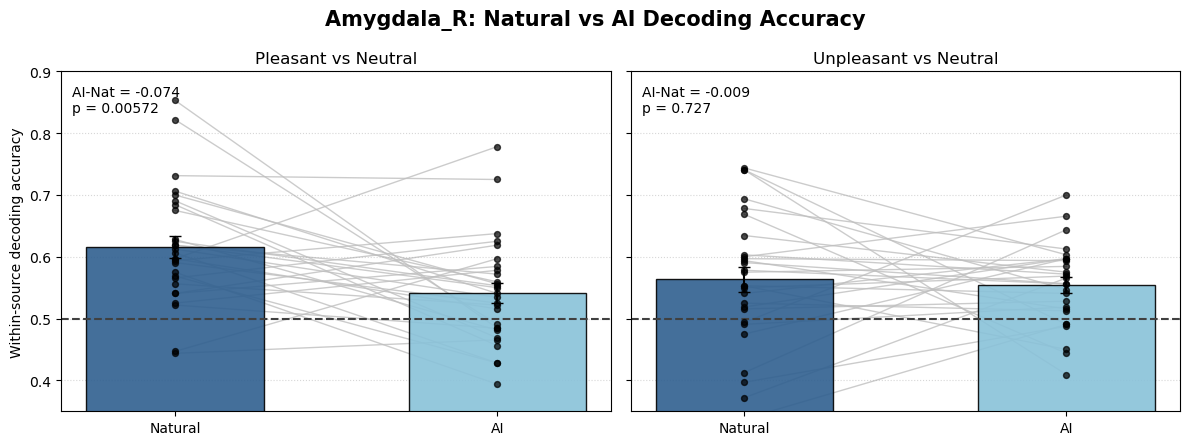

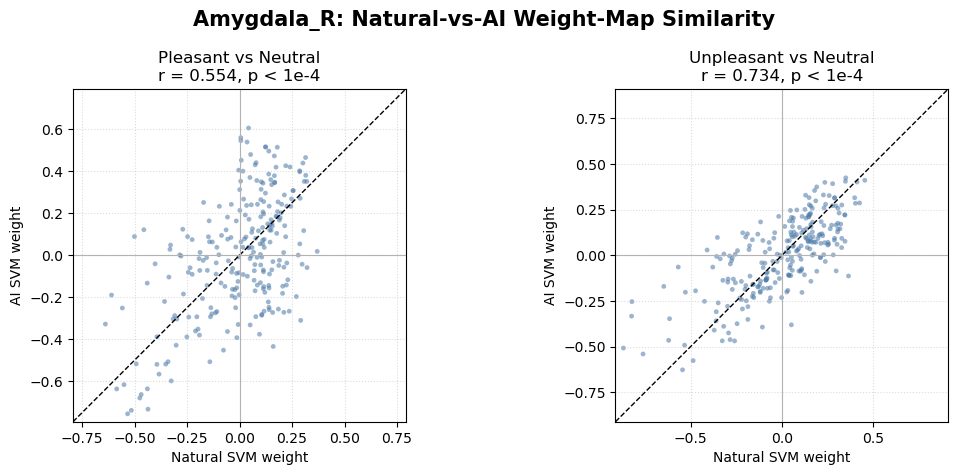

Saved Amygdala natural-vs-AI decoding and weight-map similarity analysis:
  Output folder: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\roi_weight_maps_voxel_trial_source_zscore\Amygdala_R\weight_map_similarity_analysis
  Decoding subject table: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\roi_weight_maps_voxel_trial_source_zscore\Amygdala_R\weight_map_similarity_analysis\Amygdala_R_natural_vs_ai_decoding_subject_level.csv
  Decoding summary table: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\roi_weight_maps_voxel_trial_source_zscore\Amygdala_R\weight_map_similarity_analysis\Amygdala_R_natural_vs_ai_decoding_summary.csv
  Weight similarity table: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\roi_weight_maps_voxel_trial_source_zscore\Amygdala_R\weight_map_similarity_analysis\Amygdala_R_weight_map_similarity.csv
  Excel workbook: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\roi_weight_maps_

,roi,decode_rois_averaged,contrast,n_subjects,natural_mean_accuracy,natural_sem,ai_mean_accuracy,ai_sem,ai_minus_natural_mean,ai_minus_natural_sem,paired_t_ai_vs_natural,paired_p_ai_vs_natural,subject_level_natural_ai_r,subject_level_natural_ai_r_p,ai_over_natural_signal_ratio_from_group_mean
0,Amygdala_R,"Amygdala_L,Amygdala_R",pleasant_vs_neutral,28,0.615513,0.017811,0.541183,0.016253,-0.074330,0.024761,-3.001932,0.005719,-0.054743,0.782031,0.356522
1,Amygdala_R,"Amygdala_L,Amygdala_R",unpleasant_vs_neutral,28,0.563281,0.020267,0.554353,0.012519,-0.008929,0.025316,-0.352683,0.727065,-0.144732,0.462451,0.858907


,roi,comparison,map_a,map_b,label,n_voxels,pearson_r,pearson_p,spearman_r,spearman_p,cosine_similarity,sign_agreement_fraction,mean_abs_difference,root_mean_square_difference
0,Amygdala_R,pleasant_vs_neutral,natural_pleasant_vs_neutral,ai_pleasant_vs_neutral,Natural PL-vs-Nt vs AI PL-vs-Nt,248,0.553765,2.486374e-21,0.465621,9.506807e-15,0.553771,0.697581,0.194801,0.241621
1,Amygdala_R,unpleasant_vs_neutral,natural_unpleasant_vs_neutral,ai_unpleasant_vs_neutral,Natural UP-vs-Nt vs AI UP-vs-Nt,248,0.734393,2.723598e-43,0.724317,1.314737e-41,0.734394,0.798387,0.133210,0.171218
2,Amygdala_R,within_natural_valence_control,natural_pleasant_vs_neutral,natural_unpleasant_vs_neutral,Natural PL-vs-Nt vs Natural UP-vs-Nt,248,0.677399,1.173163e-34,0.559952,7.199378e-22,0.677400,0.717742,0.149921,0.188931
3,Amygdala_R,within_ai_valence_control,ai_pleasant_vs_neutral,ai_unpleasant_vs_neutral,AI PL-vs-Nt vs AI UP-vs-Nt,248,0.591273,8.952781e-25,0.556570,1.422065e-21,0.591273,0.729839,0.185453,0.231010
4,Amygdala_R,cross_valence_control_pleasant_natural_unpleas...,natural_pleasant_vs_neutral,ai_unpleasant_vs_neutral,Natural PL-vs-Nt vs AI UP-vs-Nt,248,0.575942,2.588064e-23,0.418447,6.222966e-12,0.575939,0.693548,0.152554,0.193546
5,Amygdala_R,cross_valence_control_unpleasant_natural_pleas...,natural_unpleasant_vs_neutral,ai_pleasant_vs_neutral,Natural UP-vs-Nt vs AI PL-vs-Nt,248,0.521041,1.160392e-18,0.568159,1.335986e-22,0.521045,0.713710,0.200381,0.261791


In [40]:
import os
import pickle
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, ttest_rel
from numpy.linalg import norm

# -----------------------------
# User settings
# -----------------------------
WEIGHT_ROI_NAME = 'Amygdala_R'
WEIGHT_SCALING_LABEL = 'zscore'
EXCLUDE_SUBS_FROM_GROUP = ['Sub3', 'Sub8']

base_result_dir = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results'
decoding_result_pkl = os.path.join(
    base_result_dir,
    'decoding_multisub_avg_voxel_trial_source_zscore_aal3_all.pkl'
)
weight_base_dir = os.path.join(
    base_result_dir,
    'roi_weight_maps_voxel_trial_source_zscore'
)
roi_weight_dir = os.path.join(weight_base_dir, WEIGHT_ROI_NAME)
analysis_out_dir = os.path.join(roi_weight_dir, 'weight_map_similarity_analysis')
os.makedirs(analysis_out_dir, exist_ok=True)

# -----------------------------
# 1) Compare natural vs AI decoding accuracy in Amygdala
# -----------------------------
with open(decoding_result_pkl, 'rb') as f:
    decoding_results = pickle.load(f)

results_within_avg = decoding_results['within_avg']
subs_all = list(decoding_results['subs'])
subs_analysis = [s for s in subs_all if s not in EXCLUDE_SUBS_FROM_GROUP]
avg_mode = decoding_results.get('avg_z_mode', 'voxel_trial_source_zscore')

# The bilateral weight map is a combined Amygdala, but the saved decoding accuracies
# were computed for AAL3 Amygdala_L and Amygdala_R. For decoding accuracy, this block
# reports the bilateral mean of the L/R ROI accuracies, not a newly refit bilateral decoder.
amygdala_decode_rois = [r for r in ['Amygdala_L', 'Amygdala_R'] if r in decoding_results['roi_names']]
if not amygdala_decode_rois:
    raise ValueError('Could not find Amygdala_L or Amygdala_R in decoding_results["roi_names"].')

comparison_pairs = [
    {
        'contrast': 'pleasant_vs_neutral',
        'natural_comp': 'pleasant_vs_neutral',
        'ai_comp': 'pleasantAI_vs_neutralAI',
        'weight_natural': f'group_{WEIGHT_ROI_NAME}_natural_pleasant_vs_neutral_{WEIGHT_SCALING_LABEL}_weights.nii.gz',
        'weight_ai': f'group_{WEIGHT_ROI_NAME}_ai_pleasant_vs_neutral_{WEIGHT_SCALING_LABEL}_weights.nii.gz',
        'plot_label': 'Pleasant vs Neutral',
    },
    {
        'contrast': 'unpleasant_vs_neutral',
        'natural_comp': 'unpleasant_vs_neutral',
        'ai_comp': 'unpleasantAI_vs_neutralAI',
        'weight_natural': f'group_{WEIGHT_ROI_NAME}_natural_unpleasant_vs_neutral_{WEIGHT_SCALING_LABEL}_weights.nii.gz',
        'weight_ai': f'group_{WEIGHT_ROI_NAME}_ai_unpleasant_vs_neutral_{WEIGHT_SCALING_LABEL}_weights.nii.gz',
        'plot_label': 'Unpleasant vs Neutral',
    },
]

subject_rows = []
for sub in subs_analysis:
    for item in comparison_pairs:
        natural_vals = []
        ai_vals = []
        for roi in amygdala_decode_rois:
            natural_vals.append(results_within_avg[sub][item['natural_comp']][avg_mode].get(roi, np.nan))
            ai_vals.append(results_within_avg[sub][item['ai_comp']][avg_mode].get(roi, np.nan))
        natural_acc = float(np.nanmean(natural_vals))
        ai_acc = float(np.nanmean(ai_vals))
        subject_rows.append({
            'subject': sub,
            'roi': WEIGHT_ROI_NAME,
            'decode_rois_averaged': ','.join(amygdala_decode_rois),
            'contrast': item['contrast'],
            'natural_accuracy': natural_acc,
            'ai_accuracy': ai_acc,
            'ai_minus_natural': ai_acc - natural_acc,
            'natural_above_chance': natural_acc - 0.5,
            'ai_above_chance': ai_acc - 0.5,
            'ai_over_natural_signal_ratio': (ai_acc - 0.5) / (natural_acc - 0.5) if natural_acc > 0.5 else np.nan,
        })

decoding_subject_df = pd.DataFrame(subject_rows)

summary_rows = []
for contrast, dfc in decoding_subject_df.groupby('contrast', sort=False):
    natural = dfc['natural_accuracy'].to_numpy(dtype=float)
    ai = dfc['ai_accuracy'].to_numpy(dtype=float)
    valid = np.isfinite(natural) & np.isfinite(ai)
    natural = natural[valid]
    ai = ai[valid]
    diff = ai - natural
    t_stat, p_val = ttest_rel(ai, natural, nan_policy='omit') if len(diff) >= 2 else (np.nan, np.nan)
    r_val, r_p = pearsonr(natural, ai) if len(diff) >= 3 else (np.nan, np.nan)
    summary_rows.append({
        'roi': WEIGHT_ROI_NAME,
        'decode_rois_averaged': ','.join(amygdala_decode_rois),
        'contrast': contrast,
        'n_subjects': int(len(diff)),
        'natural_mean_accuracy': float(np.nanmean(natural)),
        'natural_sem': float(np.nanstd(natural, ddof=1) / np.sqrt(len(natural))) if len(natural) > 1 else np.nan,
        'ai_mean_accuracy': float(np.nanmean(ai)),
        'ai_sem': float(np.nanstd(ai, ddof=1) / np.sqrt(len(ai))) if len(ai) > 1 else np.nan,
        'ai_minus_natural_mean': float(np.nanmean(diff)),
        'ai_minus_natural_sem': float(np.nanstd(diff, ddof=1) / np.sqrt(len(diff))) if len(diff) > 1 else np.nan,
        'paired_t_ai_vs_natural': float(t_stat),
        'paired_p_ai_vs_natural': float(p_val),
        'subject_level_natural_ai_r': float(r_val),
        'subject_level_natural_ai_r_p': float(r_p),
        'ai_over_natural_signal_ratio_from_group_mean': float((np.nanmean(ai) - 0.5) / (np.nanmean(natural) - 0.5)) if np.nanmean(natural) > 0.5 else np.nan,
    })

decoding_summary_df = pd.DataFrame(summary_rows)

# Plot natural vs AI decoding accuracy with paired subject lines.
fig, axes = plt.subplots(1, len(comparison_pairs), figsize=(12, 4.5), sharey=True)
if len(comparison_pairs) == 1:
    axes = [axes]

for ax, item in zip(axes, comparison_pairs):
    dfc = decoding_subject_df[decoding_subject_df['contrast'] == item['contrast']].copy()
    natural = dfc['natural_accuracy'].to_numpy(dtype=float)
    ai = dfc['ai_accuracy'].to_numpy(dtype=float)
    x = np.array([0, 1])
    for n_val, ai_val in zip(natural, ai):
        ax.plot(x, [n_val, ai_val], color='0.75', linewidth=1, alpha=0.8, zorder=1)
    means = [np.nanmean(natural), np.nanmean(ai)]
    sems = [np.nanstd(natural, ddof=1) / np.sqrt(np.sum(np.isfinite(natural))),
            np.nanstd(ai, ddof=1) / np.sqrt(np.sum(np.isfinite(ai)))]
    ax.bar(x, means, yerr=sems, width=0.55,
           color=['#2f5f8f', '#89c2d9'], edgecolor='black', capsize=4, alpha=0.9, zorder=2)
    ax.scatter(np.repeat(0, len(natural)), natural, color='black', s=18, alpha=0.7, zorder=3)
    ax.scatter(np.repeat(1, len(ai)), ai, color='black', s=18, alpha=0.7, zorder=3)
    ax.axhline(0.5, color='0.25', linestyle='--', linewidth=1.5)
    ax.set_xticks(x)
    ax.set_xticklabels(['Natural', 'AI'])
    ax.set_title(item['plot_label'])
    ax.set_ylim(0.35, 0.9)
    ax.grid(axis='y', linestyle=':', linewidth=0.8, alpha=0.5)
    row = decoding_summary_df[decoding_summary_df['contrast'] == item['contrast']].iloc[0]
    ax.text(0.02, 0.96,
            f"AI-Nat = {row['ai_minus_natural_mean']:.3f}\np = {row['paired_p_ai_vs_natural']:.3g}",
            transform=ax.transAxes, va='top', ha='left', fontsize=10)
axes[0].set_ylabel('Within-source decoding accuracy')
fig.suptitle(f'{WEIGHT_ROI_NAME}: Natural vs AI Decoding Accuracy', fontsize=15, fontweight='bold')
fig.tight_layout()
decoding_plot_file = os.path.join(analysis_out_dir, f'{WEIGHT_ROI_NAME}_natural_vs_ai_decoding_accuracy.png')
fig.savefig(decoding_plot_file, dpi=300, bbox_inches='tight')
plt.show()

# -----------------------------
# 2) Compute group weight-map similarity
# -----------------------------
def load_weight_vector(filename):
    path = os.path.join(roi_weight_dir, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(f'Missing weight map: {path}')
    img = nib.load(path)
    data = np.asarray(img.get_fdata(), dtype=float)
    return path, data

def vector_similarity(a, b):
    mask = np.isfinite(a) & np.isfinite(b) & ((a != 0) | (b != 0))
    av = a[mask].ravel()
    bv = b[mask].ravel()
    if av.size < 3:
        return {
            'n_voxels': int(av.size),
            'pearson_r': np.nan,
            'pearson_p': np.nan,
            'spearman_r': np.nan,
            'spearman_p': np.nan,
            'cosine_similarity': np.nan,
            'sign_agreement_fraction': np.nan,
            'mean_abs_difference': np.nan,
            'root_mean_square_difference': np.nan,
        }
    pear_r, pear_p = pearsonr(av, bv)
    spear_r, spear_p = spearmanr(av, bv)
    denom = norm(av) * norm(bv)
    cosine = float(np.dot(av, bv) / denom) if denom > 0 else np.nan
    nonzero_sign = (av != 0) & (bv != 0)
    sign_agree = float(np.mean(np.sign(av[nonzero_sign]) == np.sign(bv[nonzero_sign]))) if np.any(nonzero_sign) else np.nan
    return {
        'n_voxels': int(av.size),
        'pearson_r': float(pear_r),
        'pearson_p': float(pear_p),
        'spearman_r': float(spear_r),
        'spearman_p': float(spear_p),
        'cosine_similarity': cosine,
        'sign_agreement_fraction': sign_agree,
        'mean_abs_difference': float(np.mean(np.abs(av - bv))),
        'root_mean_square_difference': float(np.sqrt(np.mean((av - bv) ** 2))),
    }

weight_maps = {}
for item in comparison_pairs:
    natural_path, natural_data = load_weight_vector(item['weight_natural'])
    ai_path, ai_data = load_weight_vector(item['weight_ai'])
    weight_maps[f"natural_{item['contrast']}"] = natural_data
    weight_maps[f"ai_{item['contrast']}"] = ai_data

similarity_specs = [
    ('pleasant_vs_neutral', 'natural_pleasant_vs_neutral', 'ai_pleasant_vs_neutral', 'Natural PL-vs-Nt vs AI PL-vs-Nt'),
    ('unpleasant_vs_neutral', 'natural_unpleasant_vs_neutral', 'ai_unpleasant_vs_neutral', 'Natural UP-vs-Nt vs AI UP-vs-Nt'),
    ('within_natural_valence_control', 'natural_pleasant_vs_neutral', 'natural_unpleasant_vs_neutral', 'Natural PL-vs-Nt vs Natural UP-vs-Nt'),
    ('within_ai_valence_control', 'ai_pleasant_vs_neutral', 'ai_unpleasant_vs_neutral', 'AI PL-vs-Nt vs AI UP-vs-Nt'),
    ('cross_valence_control_pleasant_natural_unpleasant_ai', 'natural_pleasant_vs_neutral', 'ai_unpleasant_vs_neutral', 'Natural PL-vs-Nt vs AI UP-vs-Nt'),
    ('cross_valence_control_unpleasant_natural_pleasant_ai', 'natural_unpleasant_vs_neutral', 'ai_pleasant_vs_neutral', 'Natural UP-vs-Nt vs AI PL-vs-Nt'),
]

similarity_rows = []
for comparison_name, map_a_name, map_b_name, label in similarity_specs:
    sim = vector_similarity(weight_maps[map_a_name], weight_maps[map_b_name])
    similarity_rows.append({
        'roi': WEIGHT_ROI_NAME,
        'comparison': comparison_name,
        'map_a': map_a_name,
        'map_b': map_b_name,
        'label': label,
        **sim,
    })

similarity_df = pd.DataFrame(similarity_rows)

def format_p_value(p):
    if not np.isfinite(p):
        return 'p = n/a'
    if p < 1e-4:
        return 'p < 1e-4'
    return f'p = {p:.3g}'

# Scatter plots for the two main natural-vs-AI weight-map comparisons.
fig, axes = plt.subplots(1, len(comparison_pairs), figsize=(11, 4.8), sharex=False, sharey=False)
if len(comparison_pairs) == 1:
    axes = [axes]

for ax, item in zip(axes, comparison_pairs):
    nat = weight_maps[f"natural_{item['contrast']}"]
    ai = weight_maps[f"ai_{item['contrast']}"]
    mask = np.isfinite(nat) & np.isfinite(ai) & ((nat != 0) | (ai != 0))
    x = nat[mask].ravel()
    y = ai[mask].ravel()
    ax.scatter(x, y, s=12, alpha=0.55, color='#4c78a8', edgecolor='none')
    lim = np.nanmax(np.abs(np.concatenate([x, y])))
    lim = 1.05 * lim if np.isfinite(lim) and lim > 0 else 1.0
    ax.plot([-lim, lim], [-lim, lim], color='black', linestyle='--', linewidth=1)
    ax.axhline(0, color='0.7', linewidth=0.8)
    ax.axvline(0, color='0.7', linewidth=0.8)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal', adjustable='box')
    row = similarity_df[similarity_df['comparison'] == item['contrast']].iloc[0]
    ax.set_title(f"{item['plot_label']}\nr = {row['pearson_r']:.3f}, {format_p_value(row['pearson_p'])}")
    ax.set_xlabel('Natural SVM weight')
    ax.set_ylabel('AI SVM weight')
    ax.grid(True, linestyle=':', linewidth=0.8, alpha=0.45)

fig.suptitle(f'{WEIGHT_ROI_NAME}: Natural-vs-AI Weight-Map Similarity', fontsize=15, fontweight='bold')
fig.tight_layout()
similarity_plot_file = os.path.join(analysis_out_dir, f'{WEIGHT_ROI_NAME}_natural_vs_ai_weight_similarity_scatter.png')
fig.savefig(similarity_plot_file, dpi=300, bbox_inches='tight')
plt.show()


# -----------------------------
# Export tables
# -----------------------------
decoding_subject_file = os.path.join(analysis_out_dir, f'{WEIGHT_ROI_NAME}_natural_vs_ai_decoding_subject_level.csv')
decoding_summary_file = os.path.join(analysis_out_dir, f'{WEIGHT_ROI_NAME}_natural_vs_ai_decoding_summary.csv')
similarity_file = os.path.join(analysis_out_dir, f'{WEIGHT_ROI_NAME}_weight_map_similarity.csv')
excel_file = os.path.join(analysis_out_dir, f'{WEIGHT_ROI_NAME}_natural_ai_decoding_and_weight_similarity.xlsx')

decoding_subject_df.to_csv(decoding_subject_file, index=False)
decoding_summary_df.to_csv(decoding_summary_file, index=False)
similarity_df.to_csv(similarity_file, index=False)

try:
    with pd.ExcelWriter(excel_file) as writer:
        decoding_summary_df.to_excel(writer, sheet_name='Decoding_Summary', index=False)
        decoding_subject_df.to_excel(writer, sheet_name='Decoding_Subject_Level', index=False)
        similarity_df.to_excel(writer, sheet_name='Weight_Map_Similarity', index=False)
except Exception as exc:
    print(f'Excel export skipped because pandas could not write xlsx: {exc}')
    excel_file = None

print('Saved Amygdala natural-vs-AI decoding and weight-map similarity analysis:')
print(f'  Output folder: {analysis_out_dir}')
print(f'  Decoding subject table: {decoding_subject_file}')
print(f'  Decoding summary table: {decoding_summary_file}')
print(f'  Weight similarity table: {similarity_file}')
if excel_file is not None:
    print(f'  Excel workbook: {excel_file}')
print(f'  Decoding plot: {decoding_plot_file}')
print(f'  Weight similarity plot: {similarity_plot_file}')

display(decoding_summary_df)
display(similarity_df)







## Amygdala Standard Voxel Weight-Map Comparison

This section uses the literature-style weight-map definition: one voxel has one classifier weight. It compares natural and AI Amygdala weights with voxel-wise scatter plots and an `n_voxels x 2` heatmap. It does not use the outer-product `n_voxels x n_voxels` matrix.



In [ ]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from numpy.linalg import norm

# -----------------------------
# Standard voxel-weight-map comparison settings
# -----------------------------
WEIGHT_ROI_NAME = 'Amygdala'
WEIGHT_SCALING_LABEL = 'zscore'

base_result_dir = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results'
weight_base_dir = os.path.join(base_result_dir, 'roi_weight_maps_voxel_trial_source_zscore')
roi_weight_dir = os.path.join(weight_base_dir, WEIGHT_ROI_NAME)
standard_out_dir = os.path.join(roi_weight_dir, 'standard_voxel_weight_map_comparison')
os.makedirs(standard_out_dir, exist_ok=True)

standard_weight_pairs = [
    {
        'contrast': 'pleasant_vs_neutral',
        'plot_label': 'Pleasant vs Neutral',
        'natural_file': f'group_{WEIGHT_ROI_NAME}_natural_pleasant_vs_neutral_{WEIGHT_SCALING_LABEL}_weights.nii.gz',
        'ai_file': f'group_{WEIGHT_ROI_NAME}_ai_pleasant_vs_neutral_{WEIGHT_SCALING_LABEL}_weights.nii.gz',
    },
    {
        'contrast': 'unpleasant_vs_neutral',
        'plot_label': 'Unpleasant vs Neutral',
        'natural_file': f'group_{WEIGHT_ROI_NAME}_natural_unpleasant_vs_neutral_{WEIGHT_SCALING_LABEL}_weights.nii.gz',
        'ai_file': f'group_{WEIGHT_ROI_NAME}_ai_unpleasant_vs_neutral_{WEIGHT_SCALING_LABEL}_weights.nii.gz',
    },
]


def format_p_value(p):
    if not np.isfinite(p):
        return 'p = n/a'
    if p < 1e-4:
        return 'p < 1e-4'
    return f'p = {p:.3g}'


def load_weight_pair(pair):
    natural_path = os.path.join(roi_weight_dir, pair['natural_file'])
    ai_path = os.path.join(roi_weight_dir, pair['ai_file'])
    if not os.path.exists(natural_path):
        raise FileNotFoundError(f'Missing natural weight map: {natural_path}')
    if not os.path.exists(ai_path):
        raise FileNotFoundError(f'Missing AI weight map: {ai_path}')

    natural_img = nib.load(natural_path)
    ai_img = nib.load(ai_path)
    natural_data = np.asarray(natural_img.get_fdata(), dtype=float)
    ai_data = np.asarray(ai_img.get_fdata(), dtype=float)
    if natural_data.shape != ai_data.shape:
        raise ValueError(f'Shape mismatch for {pair["contrast"]}: natural {natural_data.shape}, AI {ai_data.shape}')

    mask = np.isfinite(natural_data) & np.isfinite(ai_data) & ((natural_data != 0) | (ai_data != 0))
    ijk = np.argwhere(mask)
    natural_weights = natural_data[mask].ravel()
    ai_weights = ai_data[mask].ravel()
    mni_xyz = nib.affines.apply_affine(natural_img.affine, ijk)
    return natural_img, ijk, mni_xyz, natural_weights, ai_weights


voxel_rows = []
similarity_rows = []
heatmap_payload = {}
all_weight_values = []

for pair in standard_weight_pairs:
    img, ijk, mni_xyz, natural_weights, ai_weights = load_weight_pair(pair)
    order = np.argsort(natural_weights)
    ijk = ijk[order]
    mni_xyz = mni_xyz[order]
    natural_weights = natural_weights[order]
    ai_weights = ai_weights[order]

    heatmap_payload[pair['contrast']] = {
        'natural_weights': natural_weights,
        'ai_weights': ai_weights,
        'ijk': ijk,
        'mni_xyz': mni_xyz,
    }
    all_weight_values.extend(natural_weights.tolist())
    all_weight_values.extend(ai_weights.tolist())

    if len(natural_weights) >= 3:
        pear_r, pear_p = pearsonr(natural_weights, ai_weights)
        spear_r, spear_p = spearmanr(natural_weights, ai_weights)
    else:
        pear_r, pear_p, spear_r, spear_p = np.nan, np.nan, np.nan, np.nan

    denom = norm(natural_weights) * norm(ai_weights)
    cosine_similarity = float(np.dot(natural_weights, ai_weights) / denom) if denom > 0 else np.nan
    valid_sign = (natural_weights != 0) & (ai_weights != 0)
    sign_agreement = float(np.mean(np.sign(natural_weights[valid_sign]) == np.sign(ai_weights[valid_sign]))) if np.any(valid_sign) else np.nan

    similarity_rows.append({
        'roi': WEIGHT_ROI_NAME,
        'contrast': pair['contrast'],
        'n_voxels': int(len(natural_weights)),
        'pearson_r': float(pear_r),
        'pearson_p': float(pear_p),
        'spearman_r': float(spear_r),
        'spearman_p': float(spear_p),
        'cosine_similarity_saved_for_reference': cosine_similarity,
        'sign_agreement_fraction': sign_agreement,
        'mean_natural_weight': float(np.mean(natural_weights)),
        'mean_ai_weight': float(np.mean(ai_weights)),
        'mean_ai_minus_natural': float(np.mean(ai_weights - natural_weights)),
        'mean_abs_ai_minus_natural': float(np.mean(np.abs(ai_weights - natural_weights))),
        'rms_ai_minus_natural': float(np.sqrt(np.mean((ai_weights - natural_weights) ** 2))),
    })

    for rank, (coord, xyz, nw, aw) in enumerate(zip(ijk, mni_xyz, natural_weights, ai_weights), start=1):
        voxel_rows.append({
            'roi': WEIGHT_ROI_NAME,
            'contrast': pair['contrast'],
            'voxel_rank_sorted_by_natural_weight': rank,
            'i': int(coord[0]),
            'j': int(coord[1]),
            'k': int(coord[2]),
            'mni_x': float(xyz[0]),
            'mni_y': float(xyz[1]),
            'mni_z': float(xyz[2]),
            'natural_weight': float(nw),
            'ai_weight': float(aw),
            'ai_minus_natural_weight': float(aw - nw),
            'same_sign': bool(np.sign(nw) == np.sign(aw)) if (nw != 0 and aw != 0) else False,
        })

standard_similarity_df = pd.DataFrame(similarity_rows)
standard_voxel_df = pd.DataFrame(voxel_rows)

# -----------------------------
# Plot 1: voxel-wise scatter, the main reportable similarity view
# -----------------------------
fig, axes = plt.subplots(1, len(standard_weight_pairs), figsize=(11, 4.8), sharex=False, sharey=False)
if len(standard_weight_pairs) == 1:
    axes = [axes]

for ax, pair in zip(axes, standard_weight_pairs):
    payload = heatmap_payload[pair['contrast']]
    x = payload['natural_weights']
    y = payload['ai_weights']
    ax.scatter(x, y, s=12, alpha=0.55, color='#4c78a8', edgecolor='none')
    lim = np.nanmax(np.abs(np.concatenate([x, y])))
    lim = 1.05 * lim if np.isfinite(lim) and lim > 0 else 1.0
    ax.plot([-lim, lim], [-lim, lim], color='black', linestyle='--', linewidth=1)
    ax.axhline(0, color='0.7', linewidth=0.8)
    ax.axvline(0, color='0.7', linewidth=0.8)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal', adjustable='box')
    row = standard_similarity_df[standard_similarity_df['contrast'] == pair['contrast']].iloc[0]
    ax.set_title(f"{pair['plot_label']}\nr = {row['pearson_r']:.3f}, {format_p_value(row['pearson_p'])}")
    ax.set_xlabel('Natural voxel weight')
    ax.set_ylabel('AI voxel weight')
    ax.grid(True, linestyle=':', linewidth=0.8, alpha=0.45)

fig.suptitle(f'{WEIGHT_ROI_NAME}: Standard Voxel-Wise Natural-vs-AI Weight Similarity', fontsize=15, fontweight='bold')
fig.tight_layout()
standard_scatter_file = os.path.join(standard_out_dir, f'{WEIGHT_ROI_NAME}_standard_voxel_weight_scatter.png')
fig.savefig(standard_scatter_file, dpi=300, bbox_inches='tight')
plt.show()

# -----------------------------
# Plot 2: n_voxels x 2 heatmap, one row per voxel and one column per source
# -----------------------------
finite_values = np.asarray(all_weight_values, dtype=float)
finite_values = finite_values[np.isfinite(finite_values)]
heatmap_vlim = float(np.nanpercentile(np.abs(finite_values), 98)) if finite_values.size else 1.0
heatmap_vlim = heatmap_vlim if heatmap_vlim > 0 else 1.0

fig, axes = plt.subplots(1, len(standard_weight_pairs), figsize=(8.5, 7.0), sharey=False)
if len(standard_weight_pairs) == 1:
    axes = [axes]

for ax, pair in zip(axes, standard_weight_pairs):
    payload = heatmap_payload[pair['contrast']]
    matrix = np.column_stack([payload['natural_weights'], payload['ai_weights']])
    im = ax.imshow(matrix, aspect='auto', cmap='coolwarm', vmin=-heatmap_vlim, vmax=heatmap_vlim, interpolation='nearest')
    ax.set_title(f"{pair['plot_label']}\n{matrix.shape[0]} voxels x 2 sources")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Natural', 'AI'])
    ax.set_ylabel('Amygdala voxels\nsorted by Natural weight')
    ax.tick_params(axis='y', labelleft=False, length=0)
    ax.axvline(0.5, color='black', linewidth=1.0)

cbar = fig.colorbar(im, ax=axes, fraction=0.035, pad=0.04)
cbar.set_label('Linear SVM weight')
fig.suptitle(f'{WEIGHT_ROI_NAME}: Standard Voxel Weight Matrix', fontsize=15, fontweight='bold')
fig.tight_layout()
standard_heatmap_file = os.path.join(standard_out_dir, f'{WEIGHT_ROI_NAME}_standard_voxel_weight_nvoxels_by_2_heatmap.png')
fig.savefig(standard_heatmap_file, dpi=300, bbox_inches='tight')
plt.show()

# -----------------------------
# Export reusable tables
# -----------------------------
standard_similarity_file = os.path.join(standard_out_dir, f'{WEIGHT_ROI_NAME}_standard_voxel_weight_similarity.csv')
standard_voxel_file = os.path.join(standard_out_dir, f'{WEIGHT_ROI_NAME}_standard_voxel_weight_table.csv')
standard_excel_file = os.path.join(standard_out_dir, f'{WEIGHT_ROI_NAME}_standard_voxel_weight_comparison.xlsx')

standard_similarity_df.to_csv(standard_similarity_file, index=False)
standard_voxel_df.to_csv(standard_voxel_file, index=False)

try:
    with pd.ExcelWriter(standard_excel_file) as writer:
        standard_similarity_df.to_excel(writer, sheet_name='Similarity', index=False)
        standard_voxel_df.to_excel(writer, sheet_name='Voxel_Weights', index=False)
except Exception as exc:
    print(f'Excel export skipped: {type(exc).__name__}: {exc}')
    standard_excel_file = None

print('Saved standard Amygdala voxel weight-map comparison:')
print(f'  Output folder: {standard_out_dir}')
print(f'  Similarity table: {standard_similarity_file}')
print(f'  Voxel weight table: {standard_voxel_file}')
if standard_excel_file is not None:
    print(f'  Excel workbook: {standard_excel_file}')
print(f'  Scatter plot: {standard_scatter_file}')
print(f'  n_voxels x 2 heatmap: {standard_heatmap_file}')

display(standard_similarity_df)
display(standard_voxel_df.head())



## Amygdala Haufe Weight-Map Matrix

This section follows the Qiang-paper convention: train a linear SVM, transform the classifier weights with the Haufe method, then visualize the corrected voxel weights as a 2D matrix where each cell is one ROI voxel. The matrix is only a display reshaping of the voxel vector; it is not a voxel-by-voxel multiplication matrix.



Weight-map cache was missing on disk, so it was saved from memory to: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\weight_map_cache_avg_voxel_trial_source_zscore_superset_rois.pkl
Loaded one-pass weight-map cache: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\weight_map_cache_avg_voxel_trial_source_zscore_superset_rois.pkl
Cached subjects: 30
Cached ROIs: ['ACC_sup', 'Amygdala', 'Angular', 'Cerebellum_6', 'Cerebellum_Crus1', 'Frontal_Inf_Oper', 'Frontal_Inf_Orb_2', 'Frontal_Inf_Tri', 'Frontal_Mid_2', 'Frontal_Sup_Medial', 'Fusiform', 'Insula', 'OFCant', 'OFCpost', 'Occipital_Inf', 'Occipital_Mid', 'Occipital_Sup', 'Olfactory', 'Parietal_Inf', 'Parietal_Sup', 'Precentral', 'Red_N', 'SN_pr', 'Supp_Motor_Area', 'SupraMarginal', 'Temporal_Inf', 'Temporal_Mid', 'Temporal_Pole_Sup', 'Temporal_Sup', 'Thal_AV', 'Thal_LGN', 'Thal_MGN', 'Thal_PuI', 'Thal_PuM', 'Thal_VA', 'Calcarine', 'Cuneus', 'Lingual', 'IPS', 'LO1', 'LO2', 'MST', 'V1d', 'V1v', 'V2d', 'V2v

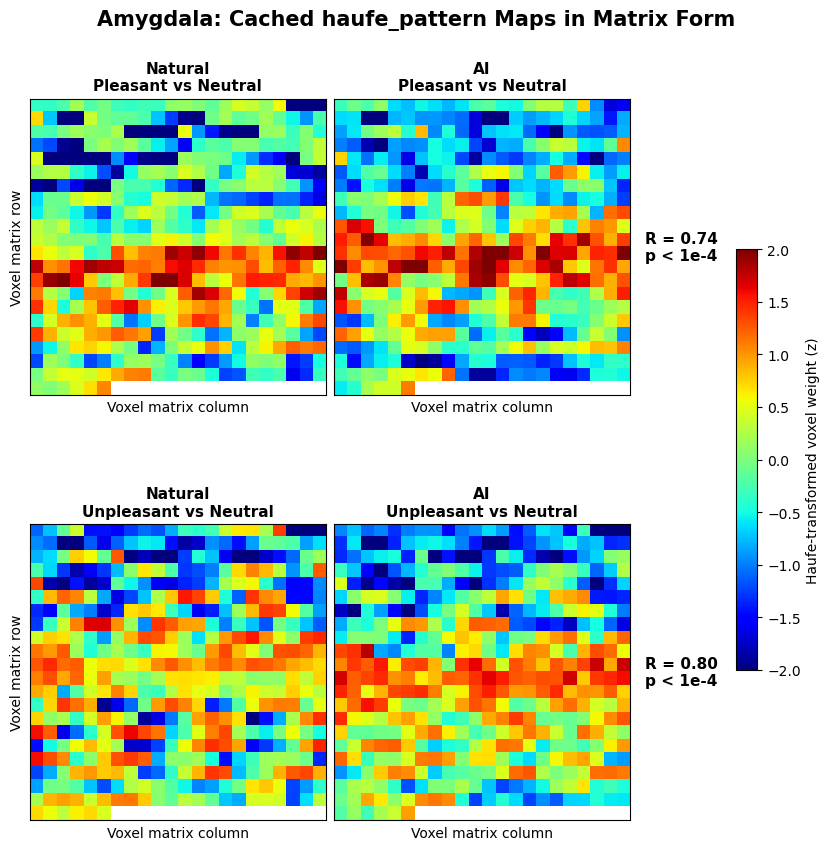

Saved cached Amygdala weight-map matrix analysis:
  Source cache: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\weight_map_cache_avg_voxel_trial_source_zscore_superset_rois.pkl
  Output folder: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\roi_weight_maps_voxel_trial_source_zscore\Amygdala\haufe_weight_map_matrix
  Matrix-form plot: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\roi_weight_maps_voxel_trial_source_zscore\Amygdala\haufe_weight_map_matrix\Amygdala_cached_haufe_pattern_maps_matrix_form.png
  Similarity table: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\roi_weight_maps_voxel_trial_source_zscore\Amygdala\haufe_weight_map_matrix\Amygdala_cached_haufe_pattern_natural_ai_similarity.csv
  Voxel long table: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\roi_weight_maps_voxel_trial_source_zscore\Amygdala\haufe_weight_map_matrix\Amygdala_cached_haufe_pattern_voxel_weights_long.csv
  Group

,roi,contrast_family,label,pattern_key,n_voxels,pearson_r_cross_correlation,pearson_p,spearman_r,spearman_p,mean_abs_ai_minus_natural,rms_ai_minus_natural
0,Amygdala,pleasant_vs_neutral,Pleasant vs Neutral,haufe_pattern,468,0.744902,6.165719e-84,0.747928,5.702980e-85,0.165344,0.207558
1,Amygdala,unpleasant_vs_neutral,Unpleasant vs Neutral,haufe_pattern,468,0.799845,2.249869e-105,0.778137,3.592859e-96,0.115939,0.147291


,roi,contrast,source,contrast_family,pattern_key,n_voxels,n_subjects_max_at_voxel,mean_group_pattern,std_group_pattern,max_abs_group_pattern,nii_path,html_path,png_path
0,Amygdala,natural_pleasant_vs_neutral,Natural,pleasant_vs_neutral,haufe_pattern,468,30.0,0.005349,0.257582,0.733568,N:\Experimental_Data\yujunchen\projects\AI_IAP...,N:\Experimental_Data\yujunchen\projects\AI_IAP...,N:\Experimental_Data\yujunchen\projects\AI_IAP...
1,Amygdala,ai_pleasant_vs_neutral,AI,pleasant_vs_neutral,haufe_pattern,468,30.0,0.005808,0.308265,0.725452,N:\Experimental_Data\yujunchen\projects\AI_IAP...,N:\Experimental_Data\yujunchen\projects\AI_IAP...,N:\Experimental_Data\yujunchen\projects\AI_IAP...
2,Amygdala,natural_unpleasant_vs_neutral,Natural,unpleasant_vs_neutral,haufe_pattern,468,30.0,0.001489,0.235421,0.685924,N:\Experimental_Data\yujunchen\projects\AI_IAP...,N:\Experimental_Data\yujunchen\projects\AI_IAP...,N:\Experimental_Data\yujunchen\projects\AI_IAP...
3,Amygdala,ai_unpleasant_vs_neutral,AI,unpleasant_vs_neutral,haufe_pattern,468,30.0,0.004010,0.229799,0.691528,N:\Experimental_Data\yujunchen\projects\AI_IAP...,N:\Experimental_Data\yujunchen\projects\AI_IAP...,N:\Experimental_Data\yujunchen\projects\AI_IAP...


In [52]:
import os
import pickle
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from nilearn import plotting, datasets

# -----------------------------
# Haufe matrix from the one-pass decoding cache
# -----------------------------
HAUFE_ROI_NAME = 'Amygdala'
HAUFE_PATTERN_KEY = 'haufe_pattern'  # 'haufe_pattern' for Haufe maps, or 'svm_weight' for raw SVM coefficients
HAUFE_SUBJECT_SCALING = 'zscore'     # zscore subject vectors before group average; use 'raw' to skip
HAUFE_MATRIX_STANDARDIZE_GROUP_WITHIN_ROI = True
HAUFE_MATRIX_VLIM = 2.0
EXPORT_SUBJECT_LEVEL_WEIGHT_MAPS = True
EXPORT_SUBJECT_LEVEL_MATRIX_PLOTS = True
SUBJECT_LEVEL_MAP_DIRNAME = 'subject_level_maps'
SUBJECT_LEVEL_MATRIX_DIRNAME = 'subject_level_matrix_plots'

base_result_dir = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results'
default_results_path = os.path.join(base_result_dir, 'decoding_multisub_avg_voxel_trial_source_zscore_aal3_all.pkl')
weight_cache_path = os.path.join(base_result_dir, 'weight_map_cache_avg_voxel_trial_source_zscore_superset_rois.pkl')
weight_base_dir = os.path.join(base_result_dir, 'roi_weight_maps_voxel_trial_source_zscore')
roi_weight_dir = os.path.join(weight_base_dir, HAUFE_ROI_NAME)
haufe_out_dir = os.path.join(roi_weight_dir, 'haufe_weight_map_matrix')
os.makedirs(haufe_out_dir, exist_ok=True)
subject_level_map_dir = os.path.join(haufe_out_dir, SUBJECT_LEVEL_MAP_DIRNAME)
subject_level_matrix_dir = os.path.join(haufe_out_dir, SUBJECT_LEVEL_MATRIX_DIRNAME)
if EXPORT_SUBJECT_LEVEL_WEIGHT_MAPS:
    os.makedirs(subject_level_map_dir, exist_ok=True)
if EXPORT_SUBJECT_LEVEL_MATRIX_PLOTS:
    os.makedirs(subject_level_matrix_dir, exist_ok=True)

if os.path.exists(default_results_path):
    with open(default_results_path, 'rb') as f:
        all_results = pickle.load(f)
    weight_cache_path = all_results.get('weight_map_cache_path') or weight_cache_path

if not os.path.exists(weight_cache_path):
    # If the decoding cell just finished in this same kernel, the cache may still
    # be in memory even if the Summaries/Save cell was not rerun yet. Save it now.
    in_memory_cache = globals().get('weight_map_cache_by_subject', None)
    if isinstance(in_memory_cache, dict) and len(in_memory_cache) > 0:
        weight_cache_payload = {
            'subject_cache': in_memory_cache,
            'roi_specs': [
                {
                    'roi': spec['roi'],
                    'member_masks': spec['member_masks'],
                    'bilateral_combined': spec['bilateral_combined'],
                }
                for spec in globals().get('weight_map_cache_roi_specs', [])
            ],
            'contrasts': globals().get('WEIGHT_MAP_CACHE_CONTRASTS', []),
            'subs': globals().get('subs', []),
            'avg_z_mode': globals().get('AVG_MODE', None),
            'n_repeats': globals().get('N_REPEATS', None),
            'n_folds': globals().get('N_FOLDS', None),
            'n_avg_groups': globals().get('N_AVG_GROUPS', None),
            'notes': {
                'source': 'Auto-saved from in-memory weight_map_cache_by_subject by Haufe section.',
                'svm_weight': 'Mean linear SVM coefficient vector from the same CV models used for within-source Avg(random) accuracy.',
                'haufe_pattern': 'Mean Haufe-style activation pattern cov(X, decision) / var(decision) from those same CV training folds.',
            },
        }
        with open(weight_cache_path, 'wb') as f:
            pickle.dump(weight_cache_payload, f)
        print(f"Weight-map cache was missing on disk, so it was saved from memory to: {weight_cache_path}")
    else:
        raise FileNotFoundError(
            f"Missing weight-map cache: {weight_cache_path}\n"
            "No in-memory weight_map_cache_by_subject was found either. This means the decoding run you completed did not produce the cache in this kernel, or the kernel was restarted. "
            "Rerun 'Run Decoding With Overall Progress Bar' with SAVE_WEIGHT_MAP_CACHE=True, then run 'Summaries And Save'."
        )

with open(weight_cache_path, 'rb') as f:
    weight_cache_payload = pickle.load(f)

subject_cache = weight_cache_payload['subject_cache']
cache_contrasts = weight_cache_payload.get('contrasts', [])
print(f"Loaded one-pass weight-map cache: {weight_cache_path}")
print(f"Cached subjects: {len(subject_cache)}")
print(f"Cached ROIs: {[s.get('roi') for s in weight_cache_payload.get('roi_specs', [])]}")

contrast_labels = {
    'natural_pleasant_vs_neutral': {'title': 'Natural Pleasant vs Neutral', 'source': 'Natural', 'contrast_family': 'pleasant_vs_neutral'},
    'ai_pleasant_vs_neutral': {'title': 'AI Pleasant vs Neutral', 'source': 'AI', 'contrast_family': 'pleasant_vs_neutral'},
    'natural_unpleasant_vs_neutral': {'title': 'Natural Unpleasant vs Neutral', 'source': 'Natural', 'contrast_family': 'unpleasant_vs_neutral'},
    'ai_unpleasant_vs_neutral': {'title': 'AI Unpleasant vs Neutral', 'source': 'AI', 'contrast_family': 'unpleasant_vs_neutral'},
}
contrast_order = [
    'natural_pleasant_vs_neutral',
    'ai_pleasant_vs_neutral',
    'natural_unpleasant_vs_neutral',
    'ai_unpleasant_vs_neutral',
]


def zscore_vector(v):
    v = np.asarray(v, dtype=np.float32)
    s = np.nanstd(v)
    if s == 0 or not np.isfinite(s):
        return np.zeros_like(v, dtype=np.float32)
    return ((v - np.nanmean(v)) / s).astype(np.float32)


def scale_subject_pattern(v, mode='zscore'):
    if mode == 'raw':
        return np.asarray(v, dtype=np.float32)
    if mode == 'zscore':
        return zscore_vector(v)
    raise ValueError(f'Unknown HAUFE_SUBJECT_SCALING: {mode}')


def save_haufe_img(weight_data, affine, out_path, description):
    img = nib.Nifti1Image(weight_data.astype(np.float32), affine)
    img.set_data_dtype(np.float32)
    finite = weight_data[np.isfinite(weight_data) & (weight_data != 0)]
    vmax = float(np.nanpercentile(np.abs(finite), 98)) if finite.size else 1.0
    vmax = vmax if vmax > 0 else 1.0
    img.header['cal_min'] = -vmax
    img.header['cal_max'] = vmax
    img.header['descrip'] = description[:80].encode('ascii', errors='ignore')
    nib.save(img, out_path)
    return img, vmax


def export_haufe_views(img, vmax, title, html_path, png_path):
    try:
        bg_img = datasets.load_mni152_template()
        view = plotting.view_img(
            img, bg_img=bg_img, title=title, cmap='cold_hot', symmetric_cmap=True,
            threshold=1e-8, vmax=vmax, opacity=0.85,
        )
        view.save_as_html(html_path)
        display = plotting.plot_stat_map(
            img, bg_img=bg_img, title=title, display_mode='ortho', cmap='cold_hot',
            symmetric_cbar=True, threshold=1e-8, vmax=vmax, colorbar=True, black_bg=True,
        )
        display.savefig(png_path, dpi=300, bbox_inches='tight')
        display.close()
    except Exception as exc:
        print(f'View export skipped for {title}: {type(exc).__name__}: {exc}')


def vector_to_panel_matrix(values):
    values = np.asarray(values, dtype=float)
    n = len(values)
    n_cols = int(np.ceil(np.sqrt(n)))
    n_rows = int(np.ceil(n / n_cols))
    mat = np.full((n_rows, n_cols), np.nan, dtype=float)
    mat.ravel()[:n] = values
    return mat


def format_p_value(p):
    if not np.isfinite(p):
        return 'p = n/a'
    if p < 1e-4:
        return 'p < 1e-4'
    return f'p = {p:.3g}'

def plot_matrix_form_from_vectors(vector_dict, title, out_file, show=False):
    """Save Qiang-style 2x2 matrix plot for group or one subject.

    vector_dict keys are contrast names; values are already ordered vectors to display.
    Each cell in each matrix is one voxel's pattern weight.
    """
    fig, axes = plt.subplots(2, 2, figsize=(8.2, 8.8), constrained_layout=True)
    families_local = [
        ('pleasant_vs_neutral', 'Pleasant vs Neutral'),
        ('unpleasant_vs_neutral', 'Unpleasant vs Neutral'),
    ]
    sources_local = [('Natural', 'natural'), ('AI', 'ai')]
    last_im = None
    sim_rows = []

    for row, (family, family_label) in enumerate(families_local):
        nat_key = f'natural_{family}'
        ai_key = f'ai_{family}'
        for col, (source_label, key_prefix) in enumerate(sources_local):
            key = f'{key_prefix}_{family}'
            ax = axes[row, col]
            if key not in vector_dict:
                ax.axis('off')
                continue
            mat = vector_to_panel_matrix(vector_dict[key])
            last_im = ax.imshow(
                mat,
                cmap='jet',
                vmin=-HAUFE_MATRIX_VLIM,
                vmax=HAUFE_MATRIX_VLIM,
                interpolation='nearest',
                aspect='equal',
            )
            ax.set_title(f'{source_label}\n{family_label}', fontsize=11, fontweight='bold')
            ax.set_xlabel('Voxel matrix column')
            if col == 0:
                ax.set_ylabel('Voxel matrix row')
            ax.set_xticks([])
            ax.set_yticks([])

        if nat_key in vector_dict and ai_key in vector_dict:
            natural = np.asarray(vector_dict[nat_key], dtype=float)
            ai = np.asarray(vector_dict[ai_key], dtype=float)
            valid = np.isfinite(natural) & np.isfinite(ai)
            r, p = pearsonr(natural[valid], ai[valid]) if np.sum(valid) >= 3 else (np.nan, np.nan)
            axes[row, 1].text(
                1.05, 0.5,
                f'R = {r:.2f}\n{format_p_value(p)}',
                transform=axes[row, 1].transAxes,
                ha='left', va='center', fontsize=11, fontweight='bold',
            )
            sim_rows.append({
                'contrast_family': family,
                'pearson_r': float(r),
                'pearson_p': float(p),
                'n_voxels': int(np.sum(valid)),
            })

    if last_im is not None:
        cbar = fig.colorbar(last_im, ax=axes, fraction=0.035, pad=0.03)
        cbar.set_label(('Haufe-transformed voxel weight' if HAUFE_PATTERN_KEY == 'haufe_pattern' else 'SVM voxel weight') + (' (z)' if HAUFE_MATRIX_STANDARDIZE_GROUP_WITHIN_ROI else ''))
    fig.suptitle(title, fontsize=15, fontweight='bold')
    fig.savefig(out_file, dpi=300, bbox_inches='tight')
    if show:
        plt.show()
    else:
        plt.close(fig)
    return sim_rows

# -----------------------------
# Group-average cached patterns and save NIfTI maps
# -----------------------------
group_sum = {}
group_count = {}
subject_rows = []
subject_map_rows = []
subject_matrix_rows = []
subject_plot_vectors = {}
failure_rows = []
ref_shape = None
affine = None

for sub, sub_cache in subject_cache.items():
    roi_cache = sub_cache.get(HAUFE_ROI_NAME, {}) if isinstance(sub_cache, dict) else {}
    if roi_cache.get('status') != 'ok':
        failure_rows.append({'subject': sub, 'roi': HAUFE_ROI_NAME, 'reason': roi_cache.get('reason', 'missing or not ok')})
        continue

    if ref_shape is None:
        ref_shape = tuple(roi_cache['ref_shape'])
        affine = np.asarray(roi_cache['affine'], dtype=float)

    voxel_idx_valid = np.asarray(roi_cache['voxel_idx_valid'], dtype=np.int64)
    for contrast_key in contrast_order:
        cdat = roi_cache.get('contrasts', {}).get(contrast_key)
        if cdat is None or HAUFE_PATTERN_KEY not in cdat:
            failure_rows.append({'subject': sub, 'roi': HAUFE_ROI_NAME, 'contrast': contrast_key, 'reason': 'contrast/pattern missing in cache'})
            continue
        vec = scale_subject_pattern(cdat[HAUFE_PATTERN_KEY], HAUFE_SUBJECT_SCALING)
        if len(vec) != len(voxel_idx_valid):
            failure_rows.append({'subject': sub, 'roi': HAUFE_ROI_NAME, 'contrast': contrast_key, 'reason': f'vector length {len(vec)} != voxel length {len(voxel_idx_valid)}'})
            continue

        if contrast_key not in group_sum:
            group_sum[contrast_key] = np.zeros(ref_shape, dtype=np.float32).ravel()
            group_count[contrast_key] = np.zeros(ref_shape, dtype=np.float32).ravel()
        group_sum[contrast_key][voxel_idx_valid] += vec
        group_count[contrast_key][voxel_idx_valid] += 1

        # Store subject-level vectors for matrix-form PNGs. Use a stable anatomical order.
        subj_order = np.argsort(voxel_idx_valid)
        subj_vec_ordered = vec[subj_order].astype(np.float32)
        if HAUFE_MATRIX_STANDARDIZE_GROUP_WITHIN_ROI:
            subj_plot_vec = zscore_vector(subj_vec_ordered)
        else:
            subj_plot_vec = subj_vec_ordered.copy()
        subject_plot_vectors.setdefault(sub, {})[contrast_key] = subj_plot_vec

        subject_map_path = ''
        if EXPORT_SUBJECT_LEVEL_WEIGHT_MAPS:
            sub_map_dir = os.path.join(subject_level_map_dir, sub)
            os.makedirs(sub_map_dir, exist_ok=True)
            full_flat = np.zeros(int(np.prod(ref_shape)), dtype=np.float32)
            full_flat[voxel_idx_valid] = vec.astype(np.float32)
            full_data = full_flat.reshape(ref_shape)
            subject_map_path = os.path.join(
                sub_map_dir,
                f'{sub}_{HAUFE_ROI_NAME}_{contrast_key}_{HAUFE_PATTERN_KEY}_{HAUFE_SUBJECT_SCALING}.nii.gz',
            )
            save_haufe_img(
                full_data,
                affine,
                subject_map_path,
                f'{sub} {HAUFE_ROI_NAME} {contrast_key} {HAUFE_PATTERN_KEY}',
            )
            subject_map_rows.append({
                'subject': sub,
                'roi': HAUFE_ROI_NAME,
                'contrast': contrast_key,
                'pattern_key': HAUFE_PATTERN_KEY,
                'subject_scaling': HAUFE_SUBJECT_SCALING,
                'n_valid_voxels': int(len(vec)),
                'map_path': subject_map_path,
                'matrix_plot_path': '',
            })

        subject_rows.append({
            'subject': sub,
            'roi': HAUFE_ROI_NAME,
            'contrast': contrast_key,
            'pattern_key': HAUFE_PATTERN_KEY,
            'subject_scaling': HAUFE_SUBJECT_SCALING,
            'n_valid_voxels': int(len(vec)),
            'n_models_averaged': int(cdat.get('n_models_averaged', 0)),
            'mean_pattern': float(np.nanmean(vec)),
            'std_pattern': float(np.nanstd(vec)),
            'max_abs_pattern': float(np.nanmax(np.abs(vec))),
            'subject_map_path': subject_map_path,
        })

if ref_shape is None or not group_sum:
    failure_file = os.path.join(haufe_out_dir, f'{HAUFE_ROI_NAME}_cached_haufe_failures.csv')
    pd.DataFrame(failure_rows).to_csv(failure_file, index=False)
    raise RuntimeError(f'No valid cached {HAUFE_PATTERN_KEY} patterns for {HAUFE_ROI_NAME}. Details saved to: {failure_file}')

group_vectors = {}
group_rows = []
voxel_rows = []

for contrast_key in contrast_order:
    if contrast_key not in group_sum:
        continue
    summed = group_sum[contrast_key]
    count = group_count[contrast_key]
    group_flat = np.zeros_like(summed, dtype=np.float32)
    valid = count > 0
    group_flat[valid] = summed[valid] / count[valid]
    group_img_data = group_flat.reshape(ref_shape)

    label = contrast_labels[contrast_key]
    base = f'group_{HAUFE_ROI_NAME}_{contrast_key}_{HAUFE_PATTERN_KEY}_{HAUFE_SUBJECT_SCALING}'
    nii_path = os.path.join(haufe_out_dir, f'{base}.nii.gz')
    html_path = os.path.join(haufe_out_dir, f'{base}_3d_view.html')
    png_path = os.path.join(haufe_out_dir, f'{base}_ortho.png')
    img, vmax = save_haufe_img(group_img_data, affine, nii_path, f'group {HAUFE_ROI_NAME} {contrast_key} {HAUFE_PATTERN_KEY}')
    export_haufe_views(img, vmax, f'{HAUFE_ROI_NAME} | {label["title"]} | {HAUFE_PATTERN_KEY}', html_path, png_path)

    flat_idx = np.where(valid)[0]
    coords = np.array(np.unravel_index(flat_idx, ref_shape)).T
    mni_xyz = nib.affines.apply_affine(affine, coords)
    weights = group_flat[flat_idx].astype(np.float32)
    plot_weights = zscore_vector(weights) if HAUFE_MATRIX_STANDARDIZE_GROUP_WITHIN_ROI else weights.copy()

    order = np.argsort(flat_idx)
    flat_idx = flat_idx[order]
    coords = coords[order]
    mni_xyz = mni_xyz[order]
    weights = weights[order]
    plot_weights = plot_weights[order]

    group_vectors[contrast_key] = {
        'weights': weights,
        'plot_weights': plot_weights,
        'flat_idx': flat_idx,
        'coords': coords,
        'mni_xyz': mni_xyz,
        'label': label,
    }

    group_rows.append({
        'roi': HAUFE_ROI_NAME,
        'contrast': contrast_key,
        'source': label['source'],
        'contrast_family': label['contrast_family'],
        'pattern_key': HAUFE_PATTERN_KEY,
        'n_voxels': int(len(weights)),
        'n_subjects_max_at_voxel': float(np.nanmax(count)) if np.any(np.isfinite(count)) else np.nan,
        'mean_group_pattern': float(np.nanmean(weights)),
        'std_group_pattern': float(np.nanstd(weights)),
        'max_abs_group_pattern': float(np.nanmax(np.abs(weights))),
        'nii_path': nii_path,
        'html_path': html_path,
        'png_path': png_path,
    })

    for rank, (flat, coord, xyz, raw_w, plot_w) in enumerate(zip(flat_idx, coords, mni_xyz, weights, plot_weights), start=1):
        voxel_rows.append({
            'roi': HAUFE_ROI_NAME,
            'contrast': contrast_key,
            'source': label['source'],
            'contrast_family': label['contrast_family'],
            'voxel_rank_in_anatomical_order': rank,
            'flat_index': int(flat),
            'i': int(coord[0]),
            'j': int(coord[1]),
            'k': int(coord[2]),
            'mni_x': float(xyz[0]),
            'mni_y': float(xyz[1]),
            'mni_z': float(xyz[2]),
            'group_pattern_weight': float(raw_w),
            'matrix_plot_weight': float(plot_w),
        })

# -----------------------------
# Similarity: cross-correlation between Natural and AI cached patterns
# -----------------------------
similarity_rows = []
for family, label_text in [('pleasant_vs_neutral', 'Pleasant vs Neutral'), ('unpleasant_vs_neutral', 'Unpleasant vs Neutral')]:
    nat_key = f'natural_{family}'
    ai_key = f'ai_{family}'
    if nat_key not in group_vectors or ai_key not in group_vectors:
        continue
    natural = group_vectors[nat_key]['weights']
    ai = group_vectors[ai_key]['weights']
    valid = np.isfinite(natural) & np.isfinite(ai)
    pear_r, pear_p = pearsonr(natural[valid], ai[valid]) if np.sum(valid) >= 3 else (np.nan, np.nan)
    spear_r, spear_p = spearmanr(natural[valid], ai[valid]) if np.sum(valid) >= 3 else (np.nan, np.nan)
    similarity_rows.append({
        'roi': HAUFE_ROI_NAME,
        'contrast_family': family,
        'label': label_text,
        'pattern_key': HAUFE_PATTERN_KEY,
        'n_voxels': int(np.sum(valid)),
        'pearson_r_cross_correlation': float(pear_r),
        'pearson_p': float(pear_p),
        'spearman_r': float(spear_r),
        'spearman_p': float(spear_p),
        'mean_abs_ai_minus_natural': float(np.mean(np.abs(ai[valid] - natural[valid]))),
        'rms_ai_minus_natural': float(np.sqrt(np.mean((ai[valid] - natural[valid]) ** 2))),
    })

similarity_df = pd.DataFrame(similarity_rows)

# -----------------------------
# Qiang-style group matrix plot: each cell = one voxel's cached pattern weight
# -----------------------------
group_plot_vectors = {key: payload['plot_weights'] for key, payload in group_vectors.items()}
haufe_matrix_plot_file = os.path.join(haufe_out_dir, f'{HAUFE_ROI_NAME}_cached_{HAUFE_PATTERN_KEY}_maps_matrix_form.png')
plot_matrix_form_from_vectors(
    group_plot_vectors,
    f'{HAUFE_ROI_NAME}: Cached {HAUFE_PATTERN_KEY} Maps in Matrix Form',
    haufe_matrix_plot_file,
    show=True,
)
print(f'Group matrix plot displayed and saved to: {haufe_matrix_plot_file}')

for key, payload in group_vectors.items():
    mat = vector_to_panel_matrix(payload['plot_weights'])
    pd.DataFrame(mat).to_csv(os.path.join(haufe_out_dir, f'{HAUFE_ROI_NAME}_{key}_cached_{HAUFE_PATTERN_KEY}_matrix_plot_values.csv'), index=False)

# -----------------------------
# Subject-level matrix-form PNGs
# -----------------------------
if EXPORT_SUBJECT_LEVEL_MATRIX_PLOTS:
    for sub, vector_dict in subject_plot_vectors.items():
        if not vector_dict:
            continue
        out_file = os.path.join(
            subject_level_matrix_dir,
            f'{sub}_{HAUFE_ROI_NAME}_cached_{HAUFE_PATTERN_KEY}_matrix_form.png',
        )
        sim_rows = plot_matrix_form_from_vectors(
            vector_dict,
            f'{sub} {HAUFE_ROI_NAME}: Cached {HAUFE_PATTERN_KEY} Maps in Matrix Form',
            out_file,
        )
        for sim in sim_rows:
            subject_matrix_rows.append({
                'subject': sub,
                'roi': HAUFE_ROI_NAME,
                'pattern_key': HAUFE_PATTERN_KEY,
                'subject_scaling': HAUFE_SUBJECT_SCALING,
                'matrix_plot_path': out_file,
                **sim,
            })
        for row in subject_map_rows:
            if row.get('subject') == sub:
                row['matrix_plot_path'] = out_file

# -----------------------------
# Export tables and archive
# -----------------------------
subject_summary_df = pd.DataFrame(subject_rows)
group_summary_df = pd.DataFrame(group_rows)
voxel_vector_df = pd.DataFrame(voxel_rows)
failure_df = pd.DataFrame(failure_rows)
subject_map_df = pd.DataFrame(subject_map_rows)
subject_matrix_df = pd.DataFrame(subject_matrix_rows)

subject_summary_file = os.path.join(haufe_out_dir, f'{HAUFE_ROI_NAME}_cached_{HAUFE_PATTERN_KEY}_subject_summary.csv')
group_summary_file = os.path.join(haufe_out_dir, f'{HAUFE_ROI_NAME}_cached_{HAUFE_PATTERN_KEY}_group_summary.csv')
voxel_vector_file = os.path.join(haufe_out_dir, f'{HAUFE_ROI_NAME}_cached_{HAUFE_PATTERN_KEY}_voxel_weights_long.csv')
similarity_file = os.path.join(haufe_out_dir, f'{HAUFE_ROI_NAME}_cached_{HAUFE_PATTERN_KEY}_natural_ai_similarity.csv')
failure_file = os.path.join(haufe_out_dir, f'{HAUFE_ROI_NAME}_cached_{HAUFE_PATTERN_KEY}_failures.csv')
subject_map_file = os.path.join(haufe_out_dir, f'{HAUFE_ROI_NAME}_cached_{HAUFE_PATTERN_KEY}_subject_level_map_index.csv')
subject_matrix_file = os.path.join(haufe_out_dir, f'{HAUFE_ROI_NAME}_cached_{HAUFE_PATTERN_KEY}_subject_level_matrix_plot_index.csv')
excel_file = os.path.join(haufe_out_dir, f'{HAUFE_ROI_NAME}_cached_{HAUFE_PATTERN_KEY}_weight_map_matrix_results.xlsx')
pkl_file = os.path.join(haufe_out_dir, f'{HAUFE_ROI_NAME}_cached_{HAUFE_PATTERN_KEY}_weight_map_matrix_results.pkl')

subject_summary_df.to_csv(subject_summary_file, index=False)
group_summary_df.to_csv(group_summary_file, index=False)
voxel_vector_df.to_csv(voxel_vector_file, index=False)
similarity_df.to_csv(similarity_file, index=False)
failure_df.to_csv(failure_file, index=False)
subject_map_df.to_csv(subject_map_file, index=False)
subject_matrix_df.to_csv(subject_matrix_file, index=False)

with open(pkl_file, 'wb') as f:
    pickle.dump({
        'settings': {
            'roi': HAUFE_ROI_NAME,
            'pattern_key': HAUFE_PATTERN_KEY,
            'source_cache': weight_cache_path,
            'subject_scaling': HAUFE_SUBJECT_SCALING,
            'matrix_standardize_group_within_roi': HAUFE_MATRIX_STANDARDIZE_GROUP_WITHIN_ROI,
            'matrix_vlim': HAUFE_MATRIX_VLIM,
        },
        'group_vectors': group_vectors,
        'subject_summary': subject_summary_df,
        'group_summary': group_summary_df,
        'voxel_weights_long': voxel_vector_df,
        'similarity': similarity_df,
        'failures': failure_df,
        'subject_level_map_index': subject_map_df,
        'subject_level_matrix_plot_index': subject_matrix_df,
    }, f)

try:
    with pd.ExcelWriter(excel_file) as writer:
        similarity_df.to_excel(writer, sheet_name='Similarity', index=False)
        group_summary_df.to_excel(writer, sheet_name='Group_Summary', index=False)
        subject_summary_df.to_excel(writer, sheet_name='Subject_Summary', index=False)
        voxel_vector_df.to_excel(writer, sheet_name='Voxel_Weights_Long', index=False)
        failure_df.to_excel(writer, sheet_name='Failures', index=False)
        subject_map_df.to_excel(writer, sheet_name='Subject_Map_Index', index=False)
        subject_matrix_df.to_excel(writer, sheet_name='Subject_Matrix_Plots', index=False)
except Exception as exc:
    print(f'Excel export skipped: {type(exc).__name__}: {exc}')
    excel_file = None

print(f'Saved cached {HAUFE_ROI_NAME} weight-map matrix analysis:')
print(f'  Source cache: {weight_cache_path}')
print(f'  Output folder: {haufe_out_dir}')
print(f'  Matrix-form plot: {haufe_matrix_plot_file}')
print(f'  Similarity table: {similarity_file}')
print(f'  Voxel long table: {voxel_vector_file}')
print(f'  Group summary: {group_summary_file}')
print(f'  Subject summary: {subject_summary_file}')
print(f'  Subject-level map folder: {subject_level_map_dir}')
print(f'  Subject-level map index: {subject_map_file}')
print(f'  Subject-level matrix plot folder: {subject_level_matrix_dir}')
print(f'  Subject-level matrix plot index: {subject_matrix_file}')
print(f'  Failures: {failure_file}')
print(f'  Pickle archive: {pkl_file}')
if excel_file is not None:
    print(f'  Excel workbook: {excel_file}')

display(similarity_df)
display(group_summary_df)








## Subject vs Group Haufe Correlation Check

Compare Natural-vs-AI Haufe weight-map correlations computed at the subject level with the correlation computed after group-averaging the voxel maps. Change `CHECK_ROI_NAME` to inspect another cached ROI.



In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

# -----------------------------
# User settings
# -----------------------------
CHECK_ROI_NAME = 'Amygdala'   # change to another cached superset ROI, e.g. 'Fusiform'
CHECK_PATTERN_KEY = 'haufe_pattern'  # or 'svm_weight'
CHECK_SUBJECT_SCALING = 'zscore'     # match the Haufe matrix section if you want exact comparison

base_result_dir = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results'
default_results_path = os.path.join(base_result_dir, 'decoding_multisub_avg_voxel_trial_source_zscore_aal3_all.pkl')
weight_cache_path = os.path.join(base_result_dir, 'weight_map_cache_avg_voxel_trial_source_zscore_superset_rois.pkl')

if os.path.exists(default_results_path):
    with open(default_results_path, 'rb') as f:
        all_results = pickle.load(f)
    weight_cache_path = all_results.get('weight_map_cache_path') or weight_cache_path

if not os.path.exists(weight_cache_path):
    raise FileNotFoundError(f'Missing weight-map cache: {weight_cache_path}')

with open(weight_cache_path, 'rb') as f:
    weight_cache_payload = pickle.load(f)

subject_cache = weight_cache_payload['subject_cache']

contrast_pairs = [
    ('pleasant_vs_neutral', 'natural_pleasant_vs_neutral', 'ai_pleasant_vs_neutral'),
    ('unpleasant_vs_neutral', 'natural_unpleasant_vs_neutral', 'ai_unpleasant_vs_neutral'),
]


def zscore_vector(v):
    v = np.asarray(v, dtype=np.float32)
    s = np.nanstd(v)
    if s == 0 or not np.isfinite(s):
        return np.zeros_like(v, dtype=np.float32)
    return ((v - np.nanmean(v)) / s).astype(np.float32)


def scale_vec(v, mode):
    v = np.asarray(v, dtype=np.float32)
    if mode == 'raw':
        return v
    if mode == 'zscore':
        return zscore_vector(v)
    raise ValueError(f'Unknown CHECK_SUBJECT_SCALING: {mode}')


def corr_pair(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    valid = np.isfinite(a) & np.isfinite(b)
    if np.sum(valid) < 3:
        return np.nan, np.nan, np.nan, np.nan, int(np.sum(valid))
    pear_r, pear_p = pearsonr(a[valid], b[valid])
    spear_r, spear_p = spearmanr(a[valid], b[valid])
    return float(pear_r), float(pear_p), float(spear_r), float(spear_p), int(np.sum(valid))

subject_rows = []
group_sum = {}
group_count = {}
ref_shape = None

for sub, sub_cache in subject_cache.items():
    roi_cache = sub_cache.get(CHECK_ROI_NAME, {}) if isinstance(sub_cache, dict) else {}
    if roi_cache.get('status') != 'ok':
        continue

    voxel_idx = np.asarray(roi_cache['voxel_idx_valid'], dtype=np.int64)
    if ref_shape is None:
        ref_shape = tuple(roi_cache['ref_shape'])

    # Store group sums for group-map correlation.
    for contrast_family, natural_key, ai_key in contrast_pairs:
        for key in [natural_key, ai_key]:
            cdat = roi_cache.get('contrasts', {}).get(key)
            if cdat is None or CHECK_PATTERN_KEY not in cdat:
                continue
            vec = scale_vec(cdat[CHECK_PATTERN_KEY], CHECK_SUBJECT_SCALING)
            if key not in group_sum:
                group_sum[key] = np.zeros(ref_shape, dtype=np.float32).ravel()
                group_count[key] = np.zeros(ref_shape, dtype=np.float32).ravel()
            group_sum[key][voxel_idx] += vec
            group_count[key][voxel_idx] += 1

        nat = roi_cache.get('contrasts', {}).get(natural_key, {})
        ai = roi_cache.get('contrasts', {}).get(ai_key, {})
        if CHECK_PATTERN_KEY not in nat or CHECK_PATTERN_KEY not in ai:
            continue
        nat_vec = scale_vec(nat[CHECK_PATTERN_KEY], CHECK_SUBJECT_SCALING)
        ai_vec = scale_vec(ai[CHECK_PATTERN_KEY], CHECK_SUBJECT_SCALING)
        pear_r, pear_p, spear_r, spear_p, n_vox = corr_pair(nat_vec, ai_vec)
        subject_rows.append({
            'subject': sub,
            'roi': CHECK_ROI_NAME,
            'contrast_family': contrast_family,
            'pattern_key': CHECK_PATTERN_KEY,
            'subject_scaling': CHECK_SUBJECT_SCALING,
            'n_voxels': n_vox,
            'subject_pearson_r': pear_r,
            'subject_pearson_p': pear_p,
            'subject_spearman_r': spear_r,
            'subject_spearman_p': spear_p,
        })

subject_corr_df = pd.DataFrame(subject_rows)

group_rows = []
for contrast_family, natural_key, ai_key in contrast_pairs:
    if natural_key not in group_sum or ai_key not in group_sum:
        continue
    nat_valid = group_count[natural_key] > 0
    ai_valid = group_count[ai_key] > 0
    valid_vox = nat_valid & ai_valid
    natural_group = np.zeros_like(group_sum[natural_key], dtype=np.float32)
    ai_group = np.zeros_like(group_sum[ai_key], dtype=np.float32)
    natural_group[nat_valid] = group_sum[natural_key][nat_valid] / group_count[natural_key][nat_valid]
    ai_group[ai_valid] = group_sum[ai_key][ai_valid] / group_count[ai_key][ai_valid]

    pear_r, pear_p, spear_r, spear_p, n_vox = corr_pair(natural_group[valid_vox], ai_group[valid_vox])

    subj_df = subject_corr_df[subject_corr_df['contrast_family'] == contrast_family].copy()
    subj_pearson = subj_df['subject_pearson_r'].dropna().to_numpy(dtype=float)
    subj_spearman = subj_df['subject_spearman_r'].dropna().to_numpy(dtype=float)

    pearson_z = np.arctanh(np.clip(subj_pearson, -0.999999, 0.999999)) if len(subj_pearson) else np.array([])
    spearman_z = np.arctanh(np.clip(subj_spearman, -0.999999, 0.999999)) if len(subj_spearman) else np.array([])

    mean_subject_pearson_r = float(np.nanmean(subj_pearson)) if len(subj_pearson) else np.nan
    fisher_mean_subject_pearson_r = float(np.tanh(np.nanmean(pearson_z))) if len(pearson_z) else np.nan
    mean_subject_spearman_r = float(np.nanmean(subj_spearman)) if len(subj_spearman) else np.nan
    fisher_mean_subject_spearman_r = float(np.tanh(np.nanmean(spearman_z))) if len(spearman_z) else np.nan

    group_rows.append({
        'roi': CHECK_ROI_NAME,
        'contrast_family': contrast_family,
        'pattern_key': CHECK_PATTERN_KEY,
        'subject_scaling': CHECK_SUBJECT_SCALING,
        'n_subjects_pearson': int(len(subj_pearson)),
        'n_subjects_spearman': int(len(subj_spearman)),
        'n_voxels_group': n_vox,

        # Definition 1: correlate after averaging maps across subjects.
        'corr_of_group_mean_maps_pearson_r': pear_r,
        'corr_of_group_mean_maps_pearson_p': pear_p,
        'corr_of_group_mean_maps_spearman_r': spear_r,
        'corr_of_group_mean_maps_spearman_p': spear_p,

        # Definition 2: compute subject-level correlations first, then average those correlations.
        'mean_subject_level_pearson_r_raw_mean': mean_subject_pearson_r,
        'mean_subject_level_pearson_r_fisher_z_mean': fisher_mean_subject_pearson_r,
        'mean_subject_level_spearman_r_raw_mean': mean_subject_spearman_r,
        'mean_subject_level_spearman_r_fisher_z_mean': fisher_mean_subject_spearman_r,

        # Backward-compatible aliases from the previous code.
        'group_map_pearson_r': pear_r,
        'group_map_pearson_p': pear_p,
        'group_map_spearman_r': spear_r,
        'group_map_spearman_p': spear_p,
        'mean_subject_pearson_r': mean_subject_pearson_r,
        'fisher_z_mean_subject_pearson_r': fisher_mean_subject_pearson_r,

        'difference_group_mean_maps_minus_raw_mean_subject_pearson_r': pear_r - mean_subject_pearson_r if np.isfinite(mean_subject_pearson_r) else np.nan,
        'difference_group_mean_maps_minus_fisher_mean_subject_pearson_r': pear_r - fisher_mean_subject_pearson_r if np.isfinite(fisher_mean_subject_pearson_r) else np.nan,
        'difference_group_mean_maps_minus_raw_mean_subject_spearman_r': spear_r - mean_subject_spearman_r if np.isfinite(mean_subject_spearman_r) else np.nan,
        'difference_group_mean_maps_minus_fisher_mean_subject_spearman_r': spear_r - fisher_mean_subject_spearman_r if np.isfinite(fisher_mean_subject_spearman_r) else np.nan,
    })

group_corr_df = pd.DataFrame(group_rows)

out_dir = os.path.join(
    base_result_dir,
    'roi_weight_maps_voxel_trial_source_zscore',
    CHECK_ROI_NAME,
    'haufe_weight_map_matrix',
)
os.makedirs(out_dir, exist_ok=True)
subject_file = os.path.join(out_dir, f'{CHECK_ROI_NAME}_{CHECK_PATTERN_KEY}_subject_level_natural_ai_correlations.csv')
group_file = os.path.join(out_dir, f'{CHECK_ROI_NAME}_{CHECK_PATTERN_KEY}_group_vs_subject_correlation_check.csv')
subject_corr_df.to_csv(subject_file, index=False)
group_corr_df.to_csv(group_file, index=False)

print(f'ROI: {CHECK_ROI_NAME}')
print(f'Pattern key: {CHECK_PATTERN_KEY}')
print(f'Subject scaling: {CHECK_SUBJECT_SCALING}')
print('\nImportant: the group-map correlation is NOT mathematically the same as the average of subject-level correlations.')
print('Definition 1: corr_of_group_mean_maps = corr(mean_subject_map_natural, mean_subject_map_AI).')
print('Definition 2: mean_subject_level_r = mean or Fisher-z mean of corr(subject_natural, subject_AI).')
print(f'\nSaved subject-level correlations: {subject_file}')
print(f'Saved group-vs-subject summary: {group_file}')

display(group_corr_df)
display(subject_corr_df)




## Superset ROI Mean Subject-Level Haufe Correlations

Compute the group-level ROI correlation as the mean of subject-level Natural-vs-AI Haufe map correlations for every ROI in the cached superset ROI list.



In [68]:
import os
import re
import pickle
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

# -----------------------------
# User settings
# -----------------------------
ALL_ROI_PATTERN_KEY = 'haufe_pattern'  # or 'svm_weight'
ALL_ROI_SUBJECT_SCALING = 'zscore'

# Explicitly exclude subjects 3 and 8 as usual before computing group-level correlations.
EXCLUDED_SUBJECT_NUMBERS = {3, 8}

base_result_dir = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results'
default_results_path = os.path.join(base_result_dir, 'decoding_multisub_avg_voxel_trial_source_zscore_aal3_all.pkl')
weight_cache_path = os.path.join(base_result_dir, 'weight_map_cache_avg_voxel_trial_source_zscore_superset_rois.pkl')

if os.path.exists(default_results_path):
    with open(default_results_path, 'rb') as f:
        all_results = pickle.load(f)
    weight_cache_path = all_results.get('weight_map_cache_path') or weight_cache_path

if not os.path.exists(weight_cache_path):
    raise FileNotFoundError(f'Missing weight-map cache: {weight_cache_path}')

with open(weight_cache_path, 'rb') as f:
    weight_cache_payload = pickle.load(f)

subject_cache = weight_cache_payload['subject_cache']


def get_subject_number(sub_label):
    """Extract numeric subject ID so Sub003, sub03, S3, and 3 all map to 3."""
    m = re.search(r'(\d+)', str(sub_label))
    return int(m.group(1)) if m else None


included_subject_cache = {
    sub: sub_cache
    for sub, sub_cache in subject_cache.items()
    if get_subject_number(sub) not in EXCLUDED_SUBJECT_NUMBERS
}
excluded_subjects_found = sorted([
    sub for sub in subject_cache.keys()
    if get_subject_number(sub) in EXCLUDED_SUBJECT_NUMBERS
], key=str)

print('Explicit subject exclusion: subjects 3 and 8 are removed before computing mean_subject_pearson_r.')
print(f'Excluded subjects found in cache: {excluded_subjects_found}')
print(f'Included subjects: {len(included_subject_cache)} / {len(subject_cache)}')

roi_specs = weight_cache_payload.get('roi_specs', [])
if roi_specs:
    superset_rois = [spec['roi'] for spec in roi_specs]
else:
    superset_rois = sorted({roi for sub_cache in included_subject_cache.values() for roi in sub_cache.keys()})

contrast_pairs = [
    ('pleasant_vs_neutral', 'natural_pleasant_vs_neutral', 'ai_pleasant_vs_neutral'),
    ('unpleasant_vs_neutral', 'natural_unpleasant_vs_neutral', 'ai_unpleasant_vs_neutral'),
]


def zscore_vector(v):
    v = np.asarray(v, dtype=np.float32)
    s = np.nanstd(v)
    if s == 0 or not np.isfinite(s):
        return np.zeros_like(v, dtype=np.float32)
    return ((v - np.nanmean(v)) / s).astype(np.float32)


def scale_vec(v, mode):
    v = np.asarray(v, dtype=np.float32)
    if mode == 'raw':
        return v
    if mode == 'zscore':
        return zscore_vector(v)
    raise ValueError(f'Unknown ALL_ROI_SUBJECT_SCALING: {mode}')

subject_rows = []
for roi in superset_rois:
    for contrast_family, natural_key, ai_key in contrast_pairs:
        for sub, sub_cache in included_subject_cache.items():
            roi_cache = sub_cache.get(roi, {}) if isinstance(sub_cache, dict) else {}
            if roi_cache.get('status') != 'ok':
                continue
            nat = roi_cache.get('contrasts', {}).get(natural_key, {})
            ai = roi_cache.get('contrasts', {}).get(ai_key, {})
            if ALL_ROI_PATTERN_KEY not in nat or ALL_ROI_PATTERN_KEY not in ai:
                continue
            nat_vec = scale_vec(nat[ALL_ROI_PATTERN_KEY], ALL_ROI_SUBJECT_SCALING)
            ai_vec = scale_vec(ai[ALL_ROI_PATTERN_KEY], ALL_ROI_SUBJECT_SCALING)
            valid = np.isfinite(nat_vec) & np.isfinite(ai_vec)
            if np.sum(valid) < 3:
                continue
            r, p = pearsonr(nat_vec[valid], ai_vec[valid])
            subject_rows.append({
                'roi': roi,
                'contrast_family': contrast_family,
                'subject': sub,
                'n_voxels': int(np.sum(valid)),
                'subject_pearson_r': float(r),
                'subject_pearson_p': float(p),
            })

subject_all_roi_corr_df = pd.DataFrame(subject_rows)
if subject_all_roi_corr_df.empty:
    raise RuntimeError('No subject-level ROI correlations were computed. Check cache content and ALL_ROI_PATTERN_KEY.')

summary_rows = []
for (roi, contrast_family), df in subject_all_roi_corr_df.groupby(['roi', 'contrast_family'], sort=False):
    vals = df['subject_pearson_r'].dropna().to_numpy(dtype=float)
    zvals = np.arctanh(np.clip(vals, -0.999999, 0.999999)) if len(vals) else np.array([])
    summary_rows.append({
        'roi': roi,
        'contrast_family': contrast_family,
        'n_subjects': int(len(vals)),
        'mean_subject_pearson_r': float(np.nanmean(vals)) if len(vals) else np.nan,
        'fisher_z_mean_subject_pearson_r': float(np.tanh(np.nanmean(zvals))) if len(zvals) else np.nan,
        'std_subject_pearson_r': float(np.nanstd(vals, ddof=1)) if len(vals) > 1 else np.nan,
        'sem_subject_pearson_r': float(np.nanstd(vals, ddof=1) / np.sqrt(len(vals))) if len(vals) > 1 else np.nan,
        'median_subject_pearson_r': float(np.nanmedian(vals)) if len(vals) else np.nan,
        'min_subject_pearson_r': float(np.nanmin(vals)) if len(vals) else np.nan,
        'max_subject_pearson_r': float(np.nanmax(vals)) if len(vals) else np.nan,
    })

all_roi_mean_subject_corr_df = pd.DataFrame(summary_rows)

print(f'Pattern key: {ALL_ROI_PATTERN_KEY}')
print(f'Subject scaling: {ALL_ROI_SUBJECT_SCALING}')
print(f'ROIs in cached superset: {len(superset_rois)}')
print(f'Subjects excluded from this summary: {sorted(EXCLUDED_SUBJECT_NUMBERS)}')
print(f'Subjects included in this summary: {len(included_subject_cache)}')
print('\nGroup-level correlations defined here as mean_subject_pearson_r = mean(corr(subject Natural map, subject AI map)).')
print('Fisher-z mean is also included, but mean_subject_pearson_r is the column you asked for.\n')

for contrast_family in ['pleasant_vs_neutral', 'unpleasant_vs_neutral']:
    print(f'=== {contrast_family} ===')
    table = all_roi_mean_subject_corr_df[
        all_roi_mean_subject_corr_df['contrast_family'] == contrast_family
    ][['roi', 'n_subjects', 'mean_subject_pearson_r', 'fisher_z_mean_subject_pearson_r']].copy()
    table = table.sort_values('mean_subject_pearson_r', ascending=False)
    print(table.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
    print()

display(all_roi_mean_subject_corr_df)



Explicit subject exclusion: subjects 3 and 8 are removed before computing mean_subject_pearson_r.
Excluded subjects found in cache: ['Sub3', 'Sub8']
Included subjects: 28 / 30
Pattern key: haufe_pattern
Subject scaling: zscore
ROIs in cached superset: 54
Subjects excluded from this summary: [3, 8]
Subjects included in this summary: 28

Group-level correlations defined here as mean_subject_pearson_r = mean(corr(subject Natural map, subject AI map)).
Fisher-z mean is also included, but mean_subject_pearson_r is the column you asked for.

=== pleasant_vs_neutral ===
               roi  n_subjects  mean_subject_pearson_r  fisher_z_mean_subject_pearson_r
     Occipital_Inf          28                  0.6005                           0.6195
               hMT          28                  0.5054                           0.5656
          Fusiform          28                  0.4957                           0.5081
               LO2          28                  0.4805                        

,roi,contrast_family,n_subjects,mean_subject_pearson_r,fisher_z_mean_subject_pearson_r,std_subject_pearson_r,sem_subject_pearson_r,median_subject_pearson_r,min_subject_pearson_r,max_subject_pearson_r
0,ACC_sup,pleasant_vs_neutral,28,0.026124,0.026837,0.241948,0.045724,0.044709,-0.597986,0.564899
1,ACC_sup,unpleasant_vs_neutral,28,0.084985,0.090420,0.208189,0.039344,0.125907,-0.331467,0.644989
2,Amygdala,pleasant_vs_neutral,28,0.090111,0.103128,0.318072,0.060110,0.052114,-0.637425,0.705907
3,Amygdala,unpleasant_vs_neutral,28,0.111298,0.115883,0.265383,0.050153,0.162553,-0.527101,0.520563
4,Angular,pleasant_vs_neutral,28,0.257264,0.269126,0.200216,0.037837,0.290027,-0.217342,0.678492
...,...,...,...,...,...,...,...,...,...,...
101,VO2,unpleasant_vs_neutral,28,0.192463,0.210416,0.272883,0.051570,0.219265,-0.308179,0.734461
102,hMT,pleasant_vs_neutral,28,0.505368,0.565584,0.316111,0.059739,0.563046,-0.340100,0.869279
103,hMT,unpleasant_vs_neutral,28,0.290754,0.328640,0.354410,0.066977,0.372822,-0.519526,0.828005
104,hV4,pleasant_vs_neutral,28,0.203147,0.222324,0.294489,0.055653,0.203068,-0.288732,0.673330


## Fusiform Haufe Seed And Cache Diagnostic

Recompute the Fusiform unpleasant-vs-neutral Haufe maps with controlled seeds and compare them with the saved cache. This checks whether the low Natural-vs-AI correlations are stable, deterministic, and not caused by how the maps were stored.


In [ ]:
import os
import re
import gc
import pickle
import numpy as np
import pandas as pd
import nibabel as nib
import scipy.io
from scipy.stats import pearsonr, spearmanr, ttest_1samp
from sklearn.model_selection import KFold
from sklearn.svm import SVC
from tqdm.auto import tqdm

# -----------------------------
# Diagnostic settings
# -----------------------------
DIAG_ROI_NAME = 'Fusiform'
DIAG_CONTRAST_FAMILY = 'unpleasant_vs_neutral'
DIAG_NATURAL_KEY = 'natural_unpleasant_vs_neutral'
DIAG_AI_KEY = 'ai_unpleasant_vs_neutral'
DIAG_NATURAL_CONDS = ('unpleasant', 'neutral')
DIAG_AI_CONDS = ('unpleasantAI', 'neutralAI')

# This is the seed scheme used by the main weight-map cache: random_state = 42 + repeat.
DIAG_PRIMARY_SEED_BASE = 42
DIAG_SECONDARY_SEED_BASE = 4242  # a different controlled seed to test seed sensitivity

# Explicitly exclude subjects 3 and 8 as usual.
DIAG_EXCLUDED_SUBJECT_NUMBERS = {3, 8}
DIAG_SUBJECTS = None  # None = all cached subjects after excluding 3 and 8; or set e.g. ['Sub1', 'Sub2'] for a quick test

DIAG_PATTERN_KEY = 'haufe_pattern'
DIAG_N_REPEATS = globals().get('N_REPEATS', 20)
DIAG_N_FOLDS = globals().get('N_FOLDS', 4)
DIAG_N_AVG_GROUPS = globals().get('N_AVG_GROUPS', 3)

base_result_dir = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results'
default_results_path = os.path.join(base_result_dir, 'decoding_multisub_avg_voxel_trial_source_zscore_aal3_all.pkl')
weight_cache_path = os.path.join(base_result_dir, 'weight_map_cache_avg_voxel_trial_source_zscore_superset_rois.pkl')

if os.path.exists(default_results_path):
    with open(default_results_path, 'rb') as f:
        all_results = pickle.load(f)
    weight_cache_path = all_results.get('weight_map_cache_path') or weight_cache_path

if not os.path.exists(weight_cache_path):
    raise FileNotFoundError(f'Missing weight-map cache: {weight_cache_path}')

with open(weight_cache_path, 'rb') as f:
    weight_cache_payload = pickle.load(f)

subject_cache = weight_cache_payload['subject_cache']
roi_specs = weight_cache_payload.get('roi_specs', [])

diag_out_dir = os.path.join(base_result_dir, 'haufe_seed_cache_diagnostic')
os.makedirs(diag_out_dir, exist_ok=True)


def get_subject_number(sub_label):
    m = re.search(r'(\d+)', str(sub_label))
    return int(m.group(1)) if m else None


def vector_corr(a, b):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    valid = np.isfinite(a) & np.isfinite(b)
    if np.sum(valid) < 3:
        return np.nan, np.nan, np.nan, np.nan, int(np.sum(valid))
    pr, pp = pearsonr(a[valid], b[valid])
    sr, sp = spearmanr(a[valid], b[valid])
    return float(pr), float(pp), float(sr), float(sp), int(np.sum(valid))


def zscore_vector_for_display(v):
    v = np.asarray(v, dtype=np.float32)
    s = np.nanstd(v)
    if s == 0 or not np.isfinite(s):
        return np.zeros_like(v, dtype=np.float32)
    return ((v - np.nanmean(v)) / s).astype(np.float32)


def combined_roi_mask_from_cache_spec(roi_name):
    """Resolve the ROI mask image used for this diagnostic.

    The saved cache metadata usually stores member mask names, not the NIfTI
    mask object itself, so reconstruct the mask from roi_masks when needed.
    """
    for spec in roi_specs:
        if spec.get('roi') == roi_name:
            mask_img = spec.get('mask_img')
            if mask_img is not None:
                return mask_img, spec
            members = [m for m in spec.get('member_masks', []) if m in roi_masks]
            if members:
                return _combined_roi_mask_from_members(members), {**spec, 'mask_reconstructed_from_member_masks': True}
            break

    # Fallback if roi_specs were not saved, or if member names were unavailable.
    if roi_name in roi_masks:
        return roi_masks[roi_name], {'roi': roi_name, 'member_masks': [roi_name], 'fallback': True}
    members = [r for r in [f'{roi_name}_L', f'{roi_name}_R', f'AAL3_{roi_name}_L', f'AAL3_{roi_name}_R'] if r in roi_masks]
    if not members:
        raise KeyError(f'Could not find {roi_name} in cached roi_specs or roi_masks.')
    return _combined_roi_mask_from_members(members), {'roi': roi_name, 'member_masks': members, 'fallback': True}


def haufe_pattern_from_training_data_seed_check(X_train, decision):
    """Same Haufe transform as the cache: cov(X, decision) / var(decision)."""
    Xc = X_train.astype(np.float64) - np.mean(X_train, axis=0, keepdims=True)
    dc = decision.astype(np.float64) - np.mean(decision)
    denom = float(np.dot(dc, dc))
    if denom <= 0 or not np.isfinite(denom):
        return np.zeros(X_train.shape[1], dtype=np.float32)
    return (Xc.T @ dc / denom).astype(np.float32)


def decode_within_avg_voxel_trial_source_with_patterns_seeded(
    d1, d2, seed_base, n_repeats=DIAG_N_REPEATS, n_folds=DIAG_N_FOLDS, n_avg_groups=DIAG_N_AVG_GROUPS
):
    """Same as the cache decoder, except seed_base is explicit for reproducibility testing."""
    accuracies = []
    weights = []
    haufe_patterns = []
    for repeat in range(n_repeats):
        kf = KFold(n_splits=n_folds, shuffle=True, random_state=seed_base + repeat)
        indices = np.arange(d1.shape[0])
        for train_idx, test_idx in kf.split(indices):
            train_all = np.vstack([d1[train_idx], d2[train_idx]])
            test_all = np.vstack([d1[test_idx], d2[test_idx]])
            train_all, test_all = preprocess_voxel_trial_inside_fold(train_all, test_all)

            n_train_1 = len(train_idx)
            n_test_1 = len(test_idx)
            d1_train_z, d2_train_z = train_all[:n_train_1], train_all[n_train_1:]
            d1_test_z, d2_test_z = test_all[:n_test_1], test_all[n_test_1:]

            train_chunks = np.array_split(np.arange(n_train_1), n_avg_groups)
            train_d1_avg = average_chunks(d1_train_z, train_chunks)
            train_d2_avg = average_chunks(d2_train_z, train_chunks)
            test_d1_avg = np.mean(d1_test_z, axis=0, keepdims=True)
            test_d2_avg = np.mean(d2_test_z, axis=0, keepdims=True)

            X_train = np.vstack([train_d1_avg, train_d2_avg])
            y_train = np.array([1] * len(train_d1_avg) + [0] * len(train_d2_avg))
            X_test = np.vstack([test_d1_avg, test_d2_avg])
            y_test = np.array([1, 0])

            clf = SVC(kernel='linear', C=1.0)
            clf.fit(X_train, y_train)
            accuracies.append(clf.score(X_test, y_test))
            weights.append(clf.coef_[0].astype(np.float32))
            haufe_patterns.append(haufe_pattern_from_training_data_seed_check(X_train, clf.decision_function(X_train)))

    return {
        'accuracy': float(np.mean(accuracies)),
        'svm_weight': np.mean(weights, axis=0).astype(np.float32),
        'haufe_pattern': np.mean(haufe_patterns, axis=0).astype(np.float32),
        'n_models_averaged': int(len(accuracies)),
    }


def load_subject_bl_and_beta_matrix(sub):
    sub_onset_dir = os.path.join(onset_base_dir, sub, 'LogFiles')
    stim_names = []
    for run_name in runs:
        fpath = os.path.join(sub_onset_dir, f'{run_name}.mat')
        if not os.path.exists(fpath):
            alt_name = 'Run' + str(int(run_name.replace('Run', '')))
            fpath = os.path.join(sub_onset_dir, f'{alt_name}.mat')
        mat = scipy.io.loadmat(fpath, squeeze_me=False)
        raw = mat['dataLog']
        for row in range(1, raw.shape[0]):
            c = raw[row, 1]
            if c.size == 0:
                continue
            if str(c.flat[0]).strip() == 'Stim on':
                stim_names.append(str(raw[row, 2].flat[0]).strip())

    categories = [stim_to_category[s] for s in stim_names]
    bl = pd.DataFrame({'beta_file': beta_file_list, 'category': categories, 'stimulus': stim_names})

    sub_dir = os.path.join(beta_dir, sub)
    first_img = nib.load(os.path.join(sub_dir, bl['beta_file'].iloc[0]))
    n_vox = int(np.prod(first_img.shape))
    data = np.zeros((len(bl), n_vox), dtype=np.float32)
    for idx in range(len(bl)):
        data[idx] = nib.load(os.path.join(sub_dir, bl.iloc[idx]['beta_file'])).get_fdata().flatten().astype(np.float32)
    return bl, data, first_img


def prepare_roi_source_z_for_subject(sub, roi_mask_img):
    bl, data, ref_img = load_subject_bl_and_beta_matrix(sub)
    voxel_idx = get_roi_voxels(roi_mask_img, ref_img)

    cond_data = {}
    for cond in all_categories:
        idx_arr = bl[bl['category'] == cond].index.values
        cond_data[cond] = data[idx_arr][:, voxel_idx]

    valid = np.ones(len(voxel_idx), dtype=bool)
    for cond in all_categories:
        valid &= ~np.any(np.isnan(cond_data[cond]), axis=0)
    if np.sum(valid) < 10:
        raise RuntimeError(f'{sub} {DIAG_ROI_NAME}: fewer than 10 valid voxels after NaN removal.')

    for cond in all_categories:
        cond_data[cond] = cond_data[cond][:, valid]

    voxel_source_z = compute_voxel_source_zscore(cond_data)
    return voxel_source_z, int(np.sum(valid)), voxel_idx, valid


def expand_valid_vector_to_full_roi(vec, valid_mask, n_roi_voxels):
    """Put a subject's valid-voxel vector back into full ROI voxel order.

    Subjects can have different valid voxel counts after NaN removal. The cache
    stores only valid voxels, so group averaging must happen after restoring each
    vector to the common ROI mask space with NaN for invalid voxels.
    """
    vec = zscore_vector_for_display(vec)
    full = np.full(n_roi_voxels, np.nan, dtype=np.float32)
    if len(vec) == int(np.sum(valid_mask)):
        full[valid_mask] = vec
    elif len(vec) == n_roi_voxels:
        full[:] = vec
    else:
        raise ValueError(
            f'Cannot align vector length {len(vec)} to ROI size {n_roi_voxels} '
            f'with {int(np.sum(valid_mask))} valid voxels.'
        )
    return full


roi_mask_img, diag_roi_spec = combined_roi_mask_from_cache_spec(DIAG_ROI_NAME)
cache_subjects = [
    sub for sub in subject_cache.keys()
    if get_subject_number(sub) not in DIAG_EXCLUDED_SUBJECT_NUMBERS
]
if DIAG_SUBJECTS is not None:
    requested = set(DIAG_SUBJECTS)
    cache_subjects = [sub for sub in cache_subjects if sub in requested]
cache_subjects = sorted(cache_subjects, key=lambda s: (get_subject_number(s) if get_subject_number(s) is not None else 10**9, str(s)))

print('Fusiform Haufe seed/cache diagnostic')
print(f'ROI: {DIAG_ROI_NAME}')
print(f'Contrast: {DIAG_CONTRAST_FAMILY}')
print(f'Natural map: {DIAG_NATURAL_CONDS[0]} vs {DIAG_NATURAL_CONDS[1]}')
print(f'AI map: {DIAG_AI_CONDS[0]} vs {DIAG_AI_CONDS[1]}')
print(f'Primary seed scheme: random_state = {DIAG_PRIMARY_SEED_BASE} + repeat, matching the saved cache')
print(f'Secondary seed scheme: random_state = {DIAG_SECONDARY_SEED_BASE} + repeat')
print(f'Explicitly excluded subjects: {sorted(DIAG_EXCLUDED_SUBJECT_NUMBERS)}')
print(f'Subjects to test: {len(cache_subjects)}')
print(f'ROI spec used: {diag_roi_spec}')

subject_rows = []
group_vectors = {
    'cache_nat': [], 'cache_ai': [],
    'rerun1_nat': [], 'rerun1_ai': [],
    'rerun2_nat': [], 'rerun2_ai': [],
    'altseed_nat': [], 'altseed_ai': [],
}

for sub in tqdm(cache_subjects, desc=f'{DIAG_ROI_NAME} {DIAG_CONTRAST_FAMILY} seed/cache check'):
    try:
        sub_roi_cache = subject_cache.get(sub, {}).get(DIAG_ROI_NAME, {})
        if sub_roi_cache.get('status') != 'ok':
            raise RuntimeError(f'Cache status is not ok: {sub_roi_cache.get("status")}')

        cached_nat = np.asarray(sub_roi_cache['contrasts'][DIAG_NATURAL_KEY][DIAG_PATTERN_KEY], dtype=np.float32)
        cached_ai = np.asarray(sub_roi_cache['contrasts'][DIAG_AI_KEY][DIAG_PATTERN_KEY], dtype=np.float32)

        voxel_source_z, n_valid_voxels, voxel_idx, valid_mask = prepare_roi_source_z_for_subject(sub, roi_mask_img)
        n_roi_voxels = len(voxel_idx)

        rerun1_nat = decode_within_avg_voxel_trial_source_with_patterns_seeded(
            voxel_source_z[DIAG_NATURAL_CONDS[0]], voxel_source_z[DIAG_NATURAL_CONDS[1]], DIAG_PRIMARY_SEED_BASE
        )
        rerun1_ai = decode_within_avg_voxel_trial_source_with_patterns_seeded(
            voxel_source_z[DIAG_AI_CONDS[0]], voxel_source_z[DIAG_AI_CONDS[1]], DIAG_PRIMARY_SEED_BASE
        )
        rerun2_nat = decode_within_avg_voxel_trial_source_with_patterns_seeded(
            voxel_source_z[DIAG_NATURAL_CONDS[0]], voxel_source_z[DIAG_NATURAL_CONDS[1]], DIAG_PRIMARY_SEED_BASE
        )
        rerun2_ai = decode_within_avg_voxel_trial_source_with_patterns_seeded(
            voxel_source_z[DIAG_AI_CONDS[0]], voxel_source_z[DIAG_AI_CONDS[1]], DIAG_PRIMARY_SEED_BASE
        )
        altseed_nat = decode_within_avg_voxel_trial_source_with_patterns_seeded(
            voxel_source_z[DIAG_NATURAL_CONDS[0]], voxel_source_z[DIAG_NATURAL_CONDS[1]], DIAG_SECONDARY_SEED_BASE
        )
        altseed_ai = decode_within_avg_voxel_trial_source_with_patterns_seeded(
            voxel_source_z[DIAG_AI_CONDS[0]], voxel_source_z[DIAG_AI_CONDS[1]], DIAG_SECONDARY_SEED_BASE
        )

        cn = cached_nat
        ca = cached_ai
        r1n = rerun1_nat[DIAG_PATTERN_KEY]
        r1a = rerun1_ai[DIAG_PATTERN_KEY]
        r2n = rerun2_nat[DIAG_PATTERN_KEY]
        r2a = rerun2_ai[DIAG_PATTERN_KEY]
        asn = altseed_nat[DIAG_PATTERN_KEY]
        asa = altseed_ai[DIAG_PATTERN_KEY]

        for key, vec in [
            ('cache_nat', cn), ('cache_ai', ca),
            ('rerun1_nat', r1n), ('rerun1_ai', r1a),
            ('rerun2_nat', r2n), ('rerun2_ai', r2a),
            ('altseed_nat', asn), ('altseed_ai', asa),
        ]:
            group_vectors[key].append(expand_valid_vector_to_full_roi(vec, valid_mask, n_roi_voxels))

        cache_nat_ai_r, cache_nat_ai_p, cache_nat_ai_s, cache_nat_ai_sp, n_corr = vector_corr(cn, ca)
        rerun_nat_ai_r, rerun_nat_ai_p, _, _, _ = vector_corr(r1n, r1a)
        altseed_nat_ai_r, altseed_nat_ai_p, _, _, _ = vector_corr(asn, asa)
        cache_rerun_nat_r, cache_rerun_nat_p, _, _, _ = vector_corr(cn, r1n)
        cache_rerun_ai_r, cache_rerun_ai_p, _, _, _ = vector_corr(ca, r1a)
        same_seed_nat_r, same_seed_nat_p, _, _, _ = vector_corr(r1n, r2n)
        same_seed_ai_r, same_seed_ai_p, _, _, _ = vector_corr(r1a, r2a)
        seed_sensitivity_nat_r, seed_sensitivity_nat_p, _, _, _ = vector_corr(r1n, asn)
        seed_sensitivity_ai_r, seed_sensitivity_ai_p, _, _, _ = vector_corr(r1a, asa)

        subject_rows.append({
            'subject': sub,
            'roi': DIAG_ROI_NAME,
            'contrast_family': DIAG_CONTRAST_FAMILY,
            'n_roi_voxels': n_roi_voxels,
            'n_valid_voxels': n_valid_voxels,
            'n_corr_voxels': n_corr,
            'cache_natural_accuracy': sub_roi_cache['contrasts'][DIAG_NATURAL_KEY].get('accuracy', np.nan),
            'cache_ai_accuracy': sub_roi_cache['contrasts'][DIAG_AI_KEY].get('accuracy', np.nan),
            'rerun_primary_natural_accuracy': rerun1_nat['accuracy'],
            'rerun_primary_ai_accuracy': rerun1_ai['accuracy'],
            'altseed_natural_accuracy': altseed_nat['accuracy'],
            'altseed_ai_accuracy': altseed_ai['accuracy'],
            'cache_natural_vs_ai_pearson_r': cache_nat_ai_r,
            'cache_natural_vs_ai_pearson_p': cache_nat_ai_p,
            'cache_natural_vs_ai_spearman_r': cache_nat_ai_s,
            'cache_natural_vs_ai_spearman_p': cache_nat_ai_sp,
            'rerun_primary_natural_vs_ai_pearson_r': rerun_nat_ai_r,
            'rerun_primary_natural_vs_ai_pearson_p': rerun_nat_ai_p,
            'altseed_natural_vs_ai_pearson_r': altseed_nat_ai_r,
            'altseed_natural_vs_ai_pearson_p': altseed_nat_ai_p,
            'cache_vs_rerun_primary_natural_pearson_r': cache_rerun_nat_r,
            'cache_vs_rerun_primary_natural_pearson_p': cache_rerun_nat_p,
            'cache_vs_rerun_primary_ai_pearson_r': cache_rerun_ai_r,
            'cache_vs_rerun_primary_ai_pearson_p': cache_rerun_ai_p,
            'same_seed_rerun_natural_pearson_r': same_seed_nat_r,
            'same_seed_rerun_natural_pearson_p': same_seed_nat_p,
            'same_seed_rerun_ai_pearson_r': same_seed_ai_r,
            'same_seed_rerun_ai_pearson_p': same_seed_ai_p,
            'primary_vs_secondary_seed_natural_pearson_r': seed_sensitivity_nat_r,
            'primary_vs_secondary_seed_natural_pearson_p': seed_sensitivity_nat_p,
            'primary_vs_secondary_seed_ai_pearson_r': seed_sensitivity_ai_r,
            'primary_vs_secondary_seed_ai_pearson_p': seed_sensitivity_ai_p,
            'same_seed_natural_max_abs_diff': float(np.nanmax(np.abs(r1n - r2n))),
            'same_seed_ai_max_abs_diff': float(np.nanmax(np.abs(r1a - r2a))),
            'cache_vs_rerun_natural_max_abs_diff': float(np.nanmax(np.abs(cn - r1n))) if cn.shape == r1n.shape else np.nan,
            'cache_vs_rerun_ai_max_abs_diff': float(np.nanmax(np.abs(ca - r1a))) if ca.shape == r1a.shape else np.nan,
            'n_models_averaged': rerun1_nat['n_models_averaged'],
        })

        del voxel_source_z
        gc.collect()
    except Exception as exc:
        subject_rows.append({
            'subject': sub,
            'roi': DIAG_ROI_NAME,
            'contrast_family': DIAG_CONTRAST_FAMILY,
            'error': repr(exc),
        })
        print(f'FAILED {sub}: {exc}')

subject_diag_df = pd.DataFrame(subject_rows)
subject_diag_file = os.path.join(diag_out_dir, f'{DIAG_ROI_NAME}_{DIAG_CONTRAST_FAMILY}_seed_cache_subject_diagnostic.csv')
subject_diag_df.to_csv(subject_diag_file, index=False)

ok_df = subject_diag_df[subject_diag_df.get('error', pd.Series(index=subject_diag_df.index, dtype=object)).isna()].copy()
if ok_df.empty:
    raise RuntimeError('No valid subjects completed the diagnostic.')

summary_cols = [
    'cache_natural_vs_ai_pearson_r',
    'rerun_primary_natural_vs_ai_pearson_r',
    'altseed_natural_vs_ai_pearson_r',
    'cache_vs_rerun_primary_natural_pearson_r',
    'cache_vs_rerun_primary_ai_pearson_r',
    'same_seed_rerun_natural_pearson_r',
    'same_seed_rerun_ai_pearson_r',
    'primary_vs_secondary_seed_natural_pearson_r',
    'primary_vs_secondary_seed_ai_pearson_r',
    'same_seed_natural_max_abs_diff',
    'same_seed_ai_max_abs_diff',
    'cache_vs_rerun_natural_max_abs_diff',
    'cache_vs_rerun_ai_max_abs_diff',
]
summary_rows = []
for col in summary_cols:
    vals = pd.to_numeric(ok_df[col], errors='coerce').dropna().to_numpy(dtype=float)
    summary_rows.append({
        'metric': col,
        'n_subjects': int(len(vals)),
        'mean': float(np.nanmean(vals)) if len(vals) else np.nan,
        'median': float(np.nanmedian(vals)) if len(vals) else np.nan,
        'min': float(np.nanmin(vals)) if len(vals) else np.nan,
        'max': float(np.nanmax(vals)) if len(vals) else np.nan,
    })
summary_df = pd.DataFrame(summary_rows)
summary_file = os.path.join(diag_out_dir, f'{DIAG_ROI_NAME}_{DIAG_CONTRAST_FAMILY}_seed_cache_summary.csv')
summary_df.to_csv(summary_file, index=False)

# Preferred result: correlate Natural-vs-AI within each subject first, then average correlations across subjects.
subject_first_vals = ok_df['cache_natural_vs_ai_pearson_r'].dropna().to_numpy(dtype=float)
subject_first_z = np.arctanh(np.clip(subject_first_vals, -0.999999, 0.999999))
if len(subject_first_vals) > 1:
    subject_first_t_raw, subject_first_p_raw = ttest_1samp(subject_first_vals, 0.0, alternative='greater')
    subject_first_t_z, subject_first_p_z = ttest_1samp(subject_first_z, 0.0, alternative='greater')
else:
    subject_first_t_raw, subject_first_p_raw = np.nan, np.nan
    subject_first_t_z, subject_first_p_z = np.nan, np.nan

preferred_subject_first_df = pd.DataFrame([{
    'roi': DIAG_ROI_NAME,
    'contrast_family': DIAG_CONTRAST_FAMILY,
    'definition': 'subject_first: mean(corr(subject Natural Haufe map, subject AI Haufe map))',
    'n_subjects': int(len(subject_first_vals)),
    'mean_subject_pearson_r': float(np.nanmean(subject_first_vals)) if len(subject_first_vals) else np.nan,
    'sem_subject_pearson_r': float(np.nanstd(subject_first_vals, ddof=1) / np.sqrt(len(subject_first_vals))) if len(subject_first_vals) > 1 else np.nan,
    'median_subject_pearson_r': float(np.nanmedian(subject_first_vals)) if len(subject_first_vals) else np.nan,
    'min_subject_pearson_r': float(np.nanmin(subject_first_vals)) if len(subject_first_vals) else np.nan,
    'max_subject_pearson_r': float(np.nanmax(subject_first_vals)) if len(subject_first_vals) else np.nan,
    'fisher_z_mean_subject_pearson_r': float(np.tanh(np.nanmean(subject_first_z))) if len(subject_first_z) else np.nan,
    'sem_fisher_z': float(np.nanstd(subject_first_z, ddof=1) / np.sqrt(len(subject_first_z))) if len(subject_first_z) > 1 else np.nan,
    'one_sided_p_raw_r_gt_0': float(subject_first_p_raw) if np.isfinite(subject_first_p_raw) else np.nan,
    'one_sided_p_fisher_z_gt_0': float(subject_first_p_z) if np.isfinite(subject_first_p_z) else np.nan,
}])
preferred_file = os.path.join(diag_out_dir, f'{DIAG_ROI_NAME}_{DIAG_CONTRAST_FAMILY}_preferred_subject_first_correlation.csv')
preferred_subject_first_df.to_csv(preferred_file, index=False)

# Group-map correlations from averaged z-scored subject vectors. These are QC/context only, not the preferred result.
group_rows = []
for label_a, label_b, description in [
    ('cache_nat', 'cache_ai', 'cached Natural vs cached AI'),
    ('rerun1_nat', 'rerun1_ai', 'same-seed rerun Natural vs same-seed rerun AI'),
    ('altseed_nat', 'altseed_ai', 'secondary-seed rerun Natural vs secondary-seed rerun AI'),
    ('cache_nat', 'rerun1_nat', 'cached Natural vs same-seed rerun Natural'),
    ('cache_ai', 'rerun1_ai', 'cached AI vs same-seed rerun AI'),
    ('rerun1_nat', 'rerun2_nat', 'same seed rerun Natural reproducibility'),
    ('rerun1_ai', 'rerun2_ai', 'same seed rerun AI reproducibility'),
    ('rerun1_nat', 'altseed_nat', 'primary vs secondary seed Natural stability'),
    ('rerun1_ai', 'altseed_ai', 'primary vs secondary seed AI stability'),
]:
    if len(group_vectors[label_a]) and len(group_vectors[label_b]):
        a = np.nanmean(np.vstack(group_vectors[label_a]), axis=0)
        b = np.nanmean(np.vstack(group_vectors[label_b]), axis=0)
        pr, pp, sr, sp, nvox = vector_corr(a, b)
        group_rows.append({
            'comparison': description,
            'pearson_r': pr,
            'pearson_p': pp,
            'spearman_r': sr,
            'spearman_p': sp,
            'n_voxels': nvox,
            'n_subjects': len(group_vectors[label_a]),
        })

group_diag_df = pd.DataFrame(group_rows)
group_file = os.path.join(diag_out_dir, f'{DIAG_ROI_NAME}_{DIAG_CONTRAST_FAMILY}_seed_cache_group_diagnostic.csv')
group_diag_df.to_csv(group_file, index=False)

print('\n=== Subject-level diagnostic summary ===')
print(summary_df.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

print('\n=== Preferred subject-first Natural-vs-AI Haufe correlation ===')
print(preferred_subject_first_df.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

print('\n=== Group-map diagnostic correlations, QC/context only ===')
print(group_diag_df.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

print('\nInterpretation checks:')
print('1. same_seed_rerun_*_pearson_r should be 1.0 and same_seed_*_max_abs_diff should be 0, proving deterministic reruns with the same seed.')
print('2. cache_vs_rerun_primary_*_pearson_r should be 1.0 if the saved cache exactly matches the current code and seed.')
print('3. primary_vs_secondary_seed_*_pearson_r shows whether the Haufe map is stable to a different controlled split seed.')
print('4. Use the preferred subject-first table for the main result: correlate within subject first, then average r across subjects.')
print('5. The group-map table averages subject maps first and then correlates; keep it only as QC/context because it can be higher after noise reduction.')
print(f'\nSaved subject diagnostic: {subject_diag_file}')
print(f'Saved summary diagnostic: {summary_file}')
print(f'Saved preferred subject-first result: {preferred_file}')
print(f'Saved group diagnostic: {group_file}')

display(subject_diag_df)
display(summary_df)
display(preferred_subject_first_df)
display(group_diag_df)


## Fusiform Original Decoding Performance

Show the main decoding performance from the original saved results, without using the seed/cache diagnostic reruns. This is the performance table/plot to report; the diagnostic section above is only quality control.


In [ ]:
import os
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp, ttest_rel

# -----------------------------
# Original performance settings
# -----------------------------
PERF_ROI_BASE = 'Fusiform'
PERF_EXCLUDED_SUBJECT_NUMBERS = {3, 8}  # explicitly exclude subjects 3 and 8 as usual
PERF_CHANCE = 0.50
PERF_AVG_MODE = globals().get('AVG_MODE', 'voxel_trial_source_zscore')

base_result_dir = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results'
default_results_path = os.path.join(base_result_dir, 'decoding_multisub_avg_voxel_trial_source_zscore_aal3_all.pkl')
performance_out_dir = os.path.join(base_result_dir, 'original_decoding_performance_no_diagnostic')
os.makedirs(performance_out_dir, exist_ok=True)

with open(default_results_path, 'rb') as f:
    original_results = pickle.load(f)

results_within_avg = original_results['within_avg']
results_cross_avg = original_results['cross_avg']
all_subs_original = original_results['subs']
roi_names_original = original_results['roi_names']
PERF_AVG_MODE = original_results.get('avg_z_mode', PERF_AVG_MODE)


def get_subject_number(sub_label):
    m = re.search(r'(\d+)', str(sub_label))
    return int(m.group(1)) if m else None


perf_subs = [
    sub for sub in all_subs_original
    if get_subject_number(sub) not in PERF_EXCLUDED_SUBJECT_NUMBERS
]


def resolve_bilateral_roi_members(base_name, roi_names):
    """Use bilateral AAL3 members when available; otherwise use the exact ROI name."""
    candidates = [
        f'{base_name}_L', f'{base_name}_R',
        f'AAL3_{base_name}_L', f'AAL3_{base_name}_R',
        base_name,
    ]
    members = [r for r in candidates if r in roi_names]
    if not members:
        raise KeyError(f'Could not find ROI members for {base_name}. Checked: {candidates}')
    return members


perf_roi_members = resolve_bilateral_roi_members(PERF_ROI_BASE, roi_names_original)
print('Original decoding performance, no diagnostic rerun used')
print(f'Results file: {default_results_path}')
print(f'ROI base: {PERF_ROI_BASE}')
print(f'ROI members averaged as bilateral ROI: {perf_roi_members}')
print(f'Z-scoring/decoding mode: {PERF_AVG_MODE}')
print(f'Explicitly excluded subjects: {sorted(PERF_EXCLUDED_SUBJECT_NUMBERS)}')
print(f'Included subjects: {len(perf_subs)} / {len(all_subs_original)}')

perf_specs = [
    {
        'measure': 'Within Natural',
        'source': 'Natural',
        'direction': 'within',
        'comp': 'unpleasant_vs_neutral',
        'result_kind': 'within',
        'color': '#c7771f',
        'hatch': '',
    },
    {
        'measure': 'Within AI',
        'source': 'AI',
        'direction': 'within',
        'comp': 'unpleasantAI_vs_neutralAI',
        'result_kind': 'within',
        'color': '#f2bb79',
        'hatch': '//',
    },
    {
        'measure': 'Cross Natural->AI',
        'source': 'Natural->AI',
        'direction': 'cross',
        'comp': 'train_unpleasantvneutral_test_unpleasantAIvneutralAI',
        'result_kind': 'cross',
        'color': '#9c1c1c',
        'hatch': '',
    },
    {
        'measure': 'Cross AI->Natural',
        'source': 'AI->Natural',
        'direction': 'cross',
        'comp': 'train_unpleasantAIvneutralAI_test_unpleasantvneutral',
        'result_kind': 'cross',
        'color': '#efaaa7',
        'hatch': '//',
    },
]


def get_original_score(sub, spec, roi):
    result_dict = results_within_avg if spec['result_kind'] == 'within' else results_cross_avg
    return result_dict.get(sub, {}).get(spec['comp'], {}).get(PERF_AVG_MODE, {}).get(roi, np.nan)


rows = []
for sub in perf_subs:
    for spec in perf_specs:
        roi_vals = [get_original_score(sub, spec, roi) for roi in perf_roi_members]
        roi_vals = np.asarray(roi_vals, dtype=float)
        rows.append({
            'subject': sub,
            'roi_base': PERF_ROI_BASE,
            'roi_members': ','.join(perf_roi_members),
            'measure': spec['measure'],
            'source': spec['source'],
            'direction': spec['direction'],
            'comparison_key': spec['comp'],
            'accuracy': float(np.nanmean(roi_vals)) if np.any(np.isfinite(roi_vals)) else np.nan,
            'n_roi_members_available': int(np.sum(np.isfinite(roi_vals))),
        })

perf_subject_df = pd.DataFrame(rows)

summary_rows = []
for spec in perf_specs:
    vals = perf_subject_df.loc[perf_subject_df['measure'] == spec['measure'], 'accuracy'].dropna().to_numpy(dtype=float)
    tval, pval = ttest_1samp(vals, PERF_CHANCE, alternative='greater') if len(vals) > 1 else (np.nan, np.nan)
    summary_rows.append({
        'roi_base': PERF_ROI_BASE,
        'roi_members': ','.join(perf_roi_members),
        'measure': spec['measure'],
        'comparison_key': spec['comp'],
        'n_subjects': int(len(vals)),
        'mean_accuracy': float(np.nanmean(vals)) if len(vals) else np.nan,
        'sem_accuracy': float(np.nanstd(vals, ddof=1) / np.sqrt(len(vals))) if len(vals) > 1 else np.nan,
        'median_accuracy': float(np.nanmedian(vals)) if len(vals) else np.nan,
        'min_accuracy': float(np.nanmin(vals)) if len(vals) else np.nan,
        'max_accuracy': float(np.nanmax(vals)) if len(vals) else np.nan,
        't_vs_50pct': float(tval) if np.isfinite(tval) else np.nan,
        'p_one_sided_vs_50pct': float(pval) if np.isfinite(pval) else np.nan,
    })

perf_summary_df = pd.DataFrame(summary_rows)

# Useful paired contrasts: these compare performance from the original decoding output only.
pair_specs = [
    ('Within Natural - Within AI', 'Within Natural', 'Within AI'),
    ('Cross Natural->AI - Cross AI->Natural', 'Cross Natural->AI', 'Cross AI->Natural'),
    ('Within Natural - Cross Natural->AI', 'Within Natural', 'Cross Natural->AI'),
    ('Within AI - Cross AI->Natural', 'Within AI', 'Cross AI->Natural'),
]
pair_rows = []
wide = perf_subject_df.pivot_table(index='subject', columns='measure', values='accuracy', aggfunc='mean')
for label, a_name, b_name in pair_specs:
    paired = wide[[a_name, b_name]].dropna()
    if len(paired) > 1:
        tval, pval = ttest_rel(paired[a_name], paired[b_name])
    else:
        tval, pval = np.nan, np.nan
    diff = paired[a_name] - paired[b_name] if len(paired) else pd.Series(dtype=float)
    pair_rows.append({
        'comparison': label,
        'n_subjects': int(len(paired)),
        'mean_difference': float(np.nanmean(diff)) if len(diff) else np.nan,
        'sem_difference': float(np.nanstd(diff, ddof=1) / np.sqrt(len(diff))) if len(diff) > 1 else np.nan,
        'paired_t': float(tval) if np.isfinite(tval) else np.nan,
        'paired_p_two_sided': float(pval) if np.isfinite(pval) else np.nan,
    })
paired_comparison_df = pd.DataFrame(pair_rows)

subject_file = os.path.join(performance_out_dir, f'{PERF_ROI_BASE}_unpleasant_original_performance_subject_level.csv')
summary_file = os.path.join(performance_out_dir, f'{PERF_ROI_BASE}_unpleasant_original_performance_summary.csv')
paired_file = os.path.join(performance_out_dir, f'{PERF_ROI_BASE}_unpleasant_original_performance_paired_tests.csv')
plot_file = os.path.join(performance_out_dir, f'{PERF_ROI_BASE}_unpleasant_original_performance.png')
perf_subject_df.to_csv(subject_file, index=False)
perf_summary_df.to_csv(summary_file, index=False)
paired_comparison_df.to_csv(paired_file, index=False)

print('\n=== Original decoding performance summary ===')
print(perf_summary_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print('\n=== Original decoding paired comparisons ===')
print(paired_comparison_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

fig, ax = plt.subplots(figsize=(7.5, 4.8))
x = np.arange(len(perf_specs))
means = [perf_summary_df.loc[perf_summary_df['measure'] == s['measure'], 'mean_accuracy'].iloc[0] for s in perf_specs]
sems = [perf_summary_df.loc[perf_summary_df['measure'] == s['measure'], 'sem_accuracy'].iloc[0] for s in perf_specs]
for i, spec in enumerate(perf_specs):
    ax.bar(
        x[i], means[i], yerr=sems[i], capsize=4,
        color=spec['color'], edgecolor='black', linewidth=0.8,
        hatch=spec['hatch'], alpha=0.9,
    )
    vals = perf_subject_df.loc[perf_subject_df['measure'] == spec['measure'], 'accuracy'].dropna().to_numpy(dtype=float)
    jitter = np.linspace(-0.09, 0.09, len(vals)) if len(vals) > 1 else np.array([0.0])
    ax.scatter(np.full(len(vals), x[i]) + jitter, vals, s=20, color='black', alpha=0.45, zorder=3)

ax.axhline(PERF_CHANCE, color='black', linestyle='--', linewidth=1.4, alpha=0.8)
for y in np.arange(0.40, 0.91, 0.05):
    ax.axhline(y, color='gray', linestyle=':', linewidth=0.6, alpha=0.35, zorder=0)
ax.set_xticks(x)
ax.set_xticklabels([s['measure'] for s in perf_specs], rotation=20, ha='right')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.40, 0.90)
ax.set_title(f'{PERF_ROI_BASE}: Original Decoding Performance\nUnpleasant vs Neutral, no diagnostic rerun')
ax.yaxis.set_major_formatter(lambda y, _: f'{100*y:.0f}%')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(plot_file, dpi=300, bbox_inches='tight')
plt.show()

print('\nSaved original-performance outputs:')
print(f'  Subject table: {subject_file}')
print(f'  Summary table: {summary_file}')
print(f'  Paired tests: {paired_file}')
print(f'  Plot: {plot_file}')

display(perf_subject_df)
display(perf_summary_df)
display(paired_comparison_df)


In [ ]:
# Save ROI-level summary and subject-level correlations to CSV
from datetime import datetime

csv_output_dir = os.path.join(base_result_dir, 'roi_mean_subject_correlations')
os.makedirs(csv_output_dir, exist_ok=True)

summary_csv_path = os.path.join(
    csv_output_dir,
    f'all_roi_mean_subject_corr_{ALL_ROI_PATTERN_KEY}_{ALL_ROI_SUBJECT_SCALING}_exclude_sub03_sub08.csv'
)
subject_csv_path = os.path.join(
    csv_output_dir,
    f'subject_all_roi_corr_{ALL_ROI_PATTERN_KEY}_{ALL_ROI_SUBJECT_SCALING}_exclude_sub03_sub08.csv'
)

def save_csv_with_locked_file_fallback(df, path):
    try:
        df.to_csv(path, index=False)
        return path
    except PermissionError:
        root, ext = os.path.splitext(path)
        fallback_path = f'{root}_{datetime.now():%Y%m%d_%H%M%S}{ext}'
        df.to_csv(fallback_path, index=False)
        return fallback_path

summary_csv_path = save_csv_with_locked_file_fallback(all_roi_mean_subject_corr_df, summary_csv_path)
subject_csv_path = save_csv_with_locked_file_fallback(subject_all_roi_corr_df, subject_csv_path)

print(f'Saved summary CSV: {summary_csv_path}')
print(f'Saved subject-level CSV: {subject_csv_path}')


## Superset ROI Bilateral Weight Maps

Run the same linear SVM weight-map analysis for the superset ROI list from the result tables. AAL3 left/right regions are collapsed into one bilateral ROI, and table-listed Kastner/Wang ROIs are saved using the available grouped decoding masks. Jobs are parallelized across ROIs by default.



In [ ]:
import os
import re
import gc
import pickle
import warnings
import numpy as np
import pandas as pd
import nibabel as nib
import scipy.io
from scipy.stats import zscore
from nilearn import plotting, datasets
from nilearn.image import resample_img
from sklearn.svm import SVC
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# -----------------------------
# Shared weight-map settings for the superset run
# -----------------------------
# This cell does NOT use TARGET_ROIS. It builds the all-ROI superset list below
# from AAL3_SUPERSET_ROI_NAMES_FROM_TABLE and KASTNER_SUPERSET_ROI_NAMES_FROM_TABLE.

# zscore: z-score each subject's ROI weight vector before group averaging.
# raw: average raw SVM coefficients.
SUBJECT_WEIGHT_SCALING = 'zscore'  # 'zscore' or 'raw'
SAVE_SUBJECT_WEIGHT_MAPS = False

weight_out_dir = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\roi_weight_maps_voxel_trial_source_zscore'
os.makedirs(weight_out_dir, exist_ok=True)

# Load the saved decoding result for subject list, ROI atlas paths, and analysis settings.
# Note: the pickle stores accuracies, not SVM coefficients. Weight maps require reloading
# beta data and fitting a linear SVM for the selected ROI/contrast, but this does NOT
# rerun the full decoding accuracy analysis.
default_results_path = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\decoding_multisub_avg_voxel_trial_source_zscore_aal3_all.pkl'
with open(default_results_path, 'rb') as f:
    all_results = pickle.load(f)
print(f"Loaded saved decoding results from: {default_results_path}")

# -----------------------------
# Self-contained setup
# -----------------------------
beta_dir = globals().get('beta_dir', r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\GLM_singletrial\betas')
label_file = globals().get('label_file', r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\GLM_singletrial\beta_groups.csv')
onset_base_dir = globals().get('onset_base_dir', r'N:\Experimental_Data\yujunchen\projects\LAB_IAPS_AI\DataRecording')

runs = globals().get('runs', ['Run01','Run02','Run03','Run04','Run05','Run06','Run07','Run08','Run09','Run10'])
N_REPEATS = all_results.get('n_repeats', globals().get('N_REPEATS', 20))
N_AVG_GROUPS = all_results.get('n_avg_groups', globals().get('N_AVG_GROUPS', 3))
AVG_MODE = all_results.get('avg_z_mode', 'voxel_trial_source_zscore')

natural_cats = globals().get('natural_cats', ['pleasant', 'neutral', 'unpleasant'])
ai_cats = globals().get('ai_cats', ['pleasantAI', 'neutralAI', 'unpleasantAI'])
all_categories = globals().get('all_categories', natural_cats + ai_cats)
subs_weight = [s for s in all_results['subs'] if s not in ['Sub3', 'Sub8']]

if 'beta_file_list' not in globals() or 'stim_to_category' not in globals():
    _bl = pd.read_csv(label_file, header=None, names=['beta_file', 'category'])
    beta_file_list = _bl['beta_file'].tolist()

    _stim = []
    lookup_sub = 'Sub27'
    for run_name in runs:
        fpath = os.path.join(onset_base_dir, lookup_sub, 'LogFiles', f'{run_name}.mat')
        if not os.path.exists(fpath):
            alt_name = 'Run' + str(int(run_name.replace('Run', '')))
            fpath = os.path.join(onset_base_dir, lookup_sub, 'LogFiles', f'{alt_name}.mat')
        _mat = scipy.io.loadmat(fpath, squeeze_me=False)
        _raw = _mat['dataLog']
        for _row in range(1, _raw.shape[0]):
            _c = _raw[_row, 1]
            if _c.size == 0:
                continue
            if str(_c.flat[0]).strip() == 'Stim on':
                _stim.append(str(_raw[_row, 2].flat[0]).strip())

    stim_to_category = dict(zip(_stim, _bl['category']))
    print(f"Rebuilt lookup: {len(stim_to_category)} stimuli -> {len(set(stim_to_category.values()))} categories")


def parse_mricrogl_label_file(label_file):
    labels = {}
    with open(label_file, 'r', encoding='utf-8-sig') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 2:
                continue
            try:
                roi_id = int(float(parts[0]))
            except ValueError:
                continue
            roi_name = parts[1]
            if roi_id > 0 and roi_name != '*.*.*.*.*':
                labels[roi_id] = roi_name
    return labels


KASTNER_ROI_GROUPS = {
    'V1v': ['V1v'], 'V1d': ['V1d'],
    'V2v': ['V2v'], 'V2d': ['V2d'],
    'V3v': ['V3v'], 'V3d': ['V3d'],
    'hV4': ['hV4'],
    'V3a': ['V3a'], 'V3b': ['V3b'],
    'IPS': ['IPS0', 'IPS1', 'IPS2', 'IPS3', 'IPS4', 'IPS5'],
    'SPL1': ['SPL1'], 'FEF': ['FEF'],
    'LO1': ['LO1'], 'LO2': ['LO2'],
    'MST': ['MST'], 'hMT': ['hMT'],
    'VO1': ['VO1'], 'VO2': ['VO2'],
    'PHC1': ['PHC1'], 'PHC2': ['PHC2'],
}


def load_grouped_kastner_rois(kastner_atlas_file, kastner_label_file):
    kastner_img = nib.load(kastner_atlas_file)
    kastner_data = np.rint(kastner_img.get_fdata()).astype(np.int32)
    kastner_labels = parse_mricrogl_label_file(kastner_label_file)
    label_to_id = {name: roi_id for roi_id, name in kastner_labels.items()}

    kastner_masks = {}
    for group_name, member_names in KASTNER_ROI_GROUPS.items():
        missing = [name for name in member_names if name not in label_to_id]
        if missing:
            raise ValueError(f"Missing Kastner labels for {group_name}: {missing}")
        member_ids = [label_to_id[name] for name in member_names]
        roi_data = np.isin(kastner_data, member_ids).astype(np.uint8)
        if np.count_nonzero(roi_data) == 0:
            continue
        kastner_masks[group_name] = nib.Nifti1Image(roi_data, kastner_img.affine)
    return kastner_masks, kastner_labels


def load_all_aal3_rois(aal3_atlas_file, aal3_label_file):
    aal3_img = nib.load(aal3_atlas_file)
    aal3_data = np.rint(aal3_img.get_fdata()).astype(np.int32)
    aal3_labels = parse_mricrogl_label_file(aal3_label_file)

    aal3_masks = {}
    for roi_id in sorted(aal3_labels):
        roi_name = aal3_labels[roi_id]
        roi_data = (aal3_data == roi_id).astype(np.uint8)
        if np.count_nonzero(roi_data) == 0:
            continue
        aal3_masks[roi_name] = nib.Nifti1Image(roi_data, aal3_img.affine)
    return aal3_masks, aal3_labels


def get_roi_voxels(roi_mask, ref_img):
    resampled = resample_img(roi_mask, target_affine=ref_img.affine, target_shape=ref_img.shape)
    return np.where(resampled.get_fdata().flatten() > 0)[0]


def safe_pattern_zscore(X):
    Xz = zscore(X, axis=1)
    return np.nan_to_num(Xz, nan=0.0, posinf=0.0, neginf=0.0)


def fit_trial_zscore(X_train):
    mean = np.mean(X_train, axis=0)
    std = np.std(X_train, axis=0)
    std[std == 0] = 1
    return mean, std


def apply_trial_zscore(X, mean, std):
    return (X - mean) / std


def compute_source_zscore(cond_data_dict):
    result = {}
    for source_cats in [natural_cats, ai_cats]:
        present = [c for c in source_cats if c in cond_data_dict]
        if not present:
            continue
        all_data = np.vstack([cond_data_dict[c] for c in present])
        sizes = [len(cond_data_dict[c]) for c in present]
        all_z = safe_pattern_zscore(all_data)
        m = np.mean(all_z, axis=0)
        s = np.std(all_z, axis=0)
        s[s == 0] = 1
        all_z = (all_z - m) / s
        idx = 0
        for c, sz in zip(present, sizes):
            result[c] = all_z[idx:idx + sz]
            idx += sz
    return result


def compute_voxel_source_zscore(cond_data_dict):
    return compute_source_zscore(cond_data_dict)


def preprocess_voxel_trial_inside_fold(X_train, X_test):
    X_train = safe_pattern_zscore(X_train.copy())
    X_test = safe_pattern_zscore(X_test.copy())
    mean, std = fit_trial_zscore(X_train)
    return apply_trial_zscore(X_train, mean, std), apply_trial_zscore(X_test, mean, std)


def average_chunks(X, chunks):
    return np.array([np.mean(X[ch], axis=0) for ch in chunks])


# Rebuild ROI masks from the atlas paths stored in the saved result.
kastner_roi_masks, _ = load_grouped_kastner_rois(
    all_results['kastner_atlas_file'], all_results['kastner_label_file']
)
aal3_roi_masks, _ = load_all_aal3_rois(
    all_results['aal3_atlas_file'], all_results['aal3_label_file']
)
roi_masks = dict(kastner_roi_masks)
for roi_name, roi_mask in aal3_roi_masks.items():
    out_name = roi_name if roi_name not in roi_masks else f'AAL3_{roi_name}'
    roi_masks[out_name] = roi_mask
print(f"Loaded ROI masks for weight maps: {len(roi_masks)} total")


WEIGHT_CONTRASTS = [
    {'key': 'natural_pleasant_vs_neutral', 'title': 'Natural PL vs Nt', 'cond1': 'pleasant', 'cond2': 'neutral'},
    {'key': 'ai_pleasant_vs_neutral', 'title': 'AI PL vs Nt', 'cond1': 'pleasantAI', 'cond2': 'neutralAI'},
    {'key': 'natural_unpleasant_vs_neutral', 'title': 'Natural UP vs Nt', 'cond1': 'unpleasant', 'cond2': 'neutral'},
    {'key': 'ai_unpleasant_vs_neutral', 'title': 'AI UP vs Nt', 'cond1': 'unpleasantAI', 'cond2': 'neutralAI'},
]


def sanitize_filename(text):
    return re.sub(r'[^A-Za-z0-9_.-]+', '_', str(text)).strip('_')


def canonical_roi_query(name):
    aliases = {
        'loc1': 'LO1', 'loc2': 'LO2', 'lo1': 'LO1', 'lo2': 'LO2',
        'hmt': 'hMT', 'hmt+': 'hMT', 'mt': 'hMT', 'mst': 'MST',
        'amygdala': 'Amygdala',
    }
    key = str(name).strip()
    return aliases.get(key.lower(), key)


def opposite_hemi_name(name):
    prefix = 'AAL3_' if name.startswith('AAL3_') else ''
    base = name[5:] if prefix else name
    if base.endswith('_L'):
        return f'{prefix}{base[:-2]}_R'
    if base.endswith('_R'):
        return f'{prefix}{base[:-2]}_L'
    return None


def resolve_target_rois(target_queries, available_rois, expand_bilateral=True):
    available = set(available_rois)
    selected = []
    missing = []

    def add_roi(roi):
        if roi in available and roi not in selected:
            selected.append(roi)
            return True
        return False

    for query in target_queries:
        q = canonical_roi_query(query)
        resolved_any = False
        resolved_any |= add_roi(q)
        resolved_any |= add_roi(f'AAL3_{q}')
        for hemi_roi in [f'{q}_L', f'{q}_R', f'AAL3_{q}_L', f'AAL3_{q}_R']:
            resolved_any |= add_roi(hemi_roi)
        if expand_bilateral:
            for roi in list(selected):
                pair = opposite_hemi_name(roi)
                if pair is not None:
                    add_roi(pair)
        if not resolved_any:
            missing.append(query)
    return selected, missing


def load_subject_design_and_data(sub):
    sub_onset_dir = os.path.join(onset_base_dir, sub, 'LogFiles')
    stim_names = []
    for run_name in runs:
        fpath = os.path.join(sub_onset_dir, f'{run_name}.mat')
        if not os.path.exists(fpath):
            alt_name = 'Run' + str(int(run_name.replace('Run', '')))
            fpath = os.path.join(sub_onset_dir, f'{alt_name}.mat')
        mat = scipy.io.loadmat(fpath, squeeze_me=False)
        raw = mat['dataLog']
        for row in range(1, raw.shape[0]):
            c = raw[row, 1]
            if c.size == 0:
                continue
            if str(c.flat[0]).strip() == 'Stim on':
                stim_names.append(str(raw[row, 2].flat[0]).strip())

    categories = [stim_to_category[s] for s in stim_names]
    bl = pd.DataFrame({'beta_file': beta_file_list, 'category': categories, 'stimulus': stim_names})

    sub_dir = os.path.join(beta_dir, sub)
    first_img = nib.load(os.path.join(sub_dir, bl['beta_file'].iloc[0]))
    n_vox = int(np.prod(first_img.shape))
    data = np.zeros((len(bl), n_vox), dtype=np.float32)
    for idx in range(len(bl)):
        data[idx] = nib.load(os.path.join(sub_dir, bl.iloc[idx]['beta_file'])).get_fdata().flatten().astype(np.float32)
    return bl, data, first_img


def fit_avg_linear_svm_weight(d1, d2, n_repeats=N_REPEATS, n_avg_groups=N_AVG_GROUPS):
    """Fit full-data Avg(random) linear SVM and return mean coefficient vector.

    Label convention: cond1/emotional = 1, cond2/neutral = 0.
    Positive weights therefore favor cond1 over neutral.
    """
    weights = []
    n1 = len(d1)
    n2 = len(d2)
    for repeat in range(n_repeats):
        train_all = np.vstack([d1, d2])
        train_all, _ = preprocess_voxel_trial_inside_fold(train_all, train_all)
        d1_z = train_all[:n1]
        d2_z = train_all[n1:]

        rng = np.random.RandomState(42 + repeat)
        chunks1 = np.array_split(rng.permutation(n1), n_avg_groups)
        chunks2 = np.array_split(rng.permutation(n2), n_avg_groups)
        d1_avg = average_chunks(d1_z, chunks1)
        d2_avg = average_chunks(d2_z, chunks2)

        X_train = np.vstack([d1_avg, d2_avg])
        y_train = np.array([1] * len(d1_avg) + [0] * len(d2_avg))
        clf = SVC(kernel='linear', C=1.0)
        clf.fit(X_train, y_train)
        weights.append(clf.coef_[0].astype(np.float32))
    return np.mean(weights, axis=0).astype(np.float32)


def scale_subject_weight_vector(w, mode='zscore'):
    if mode == 'raw':
        return w.astype(np.float32)
    if mode == 'zscore':
        s = np.std(w)
        if s == 0 or not np.isfinite(s):
            return np.zeros_like(w, dtype=np.float32)
        return ((w - np.mean(w)) / s).astype(np.float32)
    raise ValueError(f"Unknown SUBJECT_WEIGHT_SCALING: {mode}")


def save_weight_img(weight_data, ref_img, out_path, description):
    img = nib.Nifti1Image(weight_data.astype(np.float32), ref_img.affine)
    img.set_data_dtype(np.float32)
    finite = weight_data[np.isfinite(weight_data) & (weight_data != 0)]
    if finite.size:
        vmax = float(np.nanpercentile(np.abs(finite), 98))
        vmax = vmax if vmax > 0 else float(np.nanmax(np.abs(finite)))
    else:
        vmax = 1.0
    img.header['cal_min'] = -vmax
    img.header['cal_max'] = vmax
    img.header['descrip'] = description[:80].encode('ascii', errors='ignore')
    nib.save(img, out_path)
    return img, vmax


def export_weight_views(img, vmax, title, html_path, png_path):
    bg_img = datasets.load_mni152_template()
    view = plotting.view_img(
        img, bg_img=bg_img, title=title, cmap='cold_hot', symmetric_cmap=True,
        threshold=1e-8, vmax=vmax, opacity=0.85,
    )
    view.save_as_html(html_path)

    display = plotting.plot_stat_map(
        img, bg_img=bg_img, title=title, display_mode='ortho', cmap='cold_hot',
        symmetric_cbar=True, threshold=1e-8, vmax=vmax, colorbar=True, black_bg=True,
    )
    display.savefig(png_path, dpi=300, bbox_inches='tight')
    display.close()



# -----------------------------
# Superset ROI batch settings
# -----------------------------
SUPERSET_N_PARALLEL_ROIS = 10
OVERWRITE_EXISTING_SUPERSET_WEIGHTS = False
SAVE_SUBJECT_WEIGHT_MAPS_SUPERSET = SAVE_SUBJECT_WEIGHT_MAPS
SAVE_GROUP_COUNT_MAPS_SUPERSET = True
SAVE_COMBINED_ROI_MASKS_SUPERSET = True

superset_manifest_dir = os.path.join(weight_out_dir, 'superset_roi_list')
os.makedirs(superset_manifest_dir, exist_ok=True)

# This is the table-derived superset ROI list used in later analyses. For AAL3,
# each listed L/R ROI is collapsed to its base name and both available hemispheres
# are included in one combined ROI mask.
AAL3_SUPERSET_ROI_NAMES_FROM_TABLE = [
    'ACC_sup_L',
    'Amygdala_L', 'Amygdala_R',
    'Angular_R',
    'Cerebellum_6_L', 'Cerebellum_6_R', 'Cerebellum_Crus1_R',
    'Frontal_Inf_Oper_R',
    'Frontal_Inf_Orb_2_L', 'Frontal_Inf_Orb_2_R',
    'Frontal_Inf_Tri_R',
    'Frontal_Mid_2_R',
    'Frontal_Sup_Medial_R',
    'Fusiform_L', 'Fusiform_R',
    'Insula_L', 'Insula_R',
    'OFCant_L', 'OFCpost_L', 'OFCpost_R',
    'Occipital_Inf_L', 'Occipital_Inf_R',
    'Occipital_Mid_L', 'Occipital_Mid_R',
    'Occipital_Sup_R',
    'Olfactory_L', 'Olfactory_R',
    'Parietal_Inf_L', 'Parietal_Inf_R',
    'Parietal_Sup_L', 'Parietal_Sup_R',
    'Precentral_R',
    'Red_N_L', 'Red_N_R',
    'SN_pr_R',
    'Supp_Motor_Area_L', 'Supp_Motor_Area_R',
    'SupraMarginal_R',
    'Temporal_Inf_L', 'Temporal_Inf_R',
    'Temporal_Mid_L', 'Temporal_Mid_R',
    'Temporal_Pole_Sup_L',
    'Temporal_Sup_R',
    'Thal_AV_L',
    'Thal_LGN_R', 'Thal_MGN_R',
    'Thal_PuI_R', 'Thal_PuM_R',
    'Thal_VA_L', 'Thal_VA_R',
    'Calcarine_L', 'Calcarine_R',
    'Cuneus_R',
    'Lingual_L', 'Lingual_R',
    'Occipital_Sup_L',
]

KASTNER_SUPERSET_ROI_NAMES_FROM_TABLE = [
    'IPS0', 'IPS1', 'IPS2', 'IPS3', 'IPS4', 'IPS5',
    'LO1', 'LO2', 'MST',
    'V1d', 'V1v', 'V2d', 'V2v', 'V3a', 'V3b', 'V3d', 'V3v',
    'VO1', 'VO2', 'hMT', 'hV4',
]

# The current decoding notebook uses grouped Kastner/Wang masks; individual IPS0-IPS5
# are represented by the grouped IPS ROI in roi_masks.
KASTNER_SUPERSET_ALIAS_TO_AVAILABLE = {
    'IPS0': 'IPS', 'IPS1': 'IPS', 'IPS2': 'IPS',
    'IPS3': 'IPS', 'IPS4': 'IPS', 'IPS5': 'IPS',
}


def strip_aal3_hemi_suffix(roi_name):
    roi_name = roi_name[5:] if str(roi_name).startswith('AAL3_') else str(roi_name)
    if roi_name.endswith('_L') or roi_name.endswith('_R'):
        return roi_name[:-2]
    return roi_name


def find_roi_mask_name(candidate, available):
    candidates = [candidate]
    if not str(candidate).startswith('AAL3_'):
        candidates.append(f'AAL3_{candidate}')
    else:
        candidates.append(str(candidate)[5:])
    for cand in candidates:
        if cand in available:
            return cand
    return None


def make_combined_mask_from_members(member_names):
    imgs = [roi_masks[m] for m in member_names]
    ref = imgs[0]
    combined = np.zeros(ref.shape, dtype=bool)
    for img in imgs:
        use_img = img
        if img.shape != ref.shape or not np.allclose(img.affine, ref.affine):
            use_img = resample_img(
                img,
                target_affine=ref.affine,
                target_shape=ref.shape,
                interpolation='nearest',
            )
        combined |= np.asarray(use_img.get_fdata()) > 0
    return nib.Nifti1Image(combined.astype(np.uint8), ref.affine)


def build_superset_roi_specs():
    available = set(roi_masks.keys())
    specs = []
    rows = []
    missing = []
    seen_output_names = set()

    aal3_bases = []
    for roi in AAL3_SUPERSET_ROI_NAMES_FROM_TABLE:
        base = strip_aal3_hemi_suffix(roi)
        if base not in aal3_bases:
            aal3_bases.append(base)

    for base in aal3_bases:
        members = []
        for hemi in ['L', 'R']:
            resolved = find_roi_mask_name(f'{base}_{hemi}', available)
            if resolved is not None and resolved not in members:
                members.append(resolved)
        exact = find_roi_mask_name(base, available)
        if exact is not None and exact not in members:
            members.append(exact)
        if not members:
            missing.append({'atlas': 'AAL3', 'requested_roi': base, 'reason': 'no L/R or exact mask found'})
            continue
        out_name = base
        specs.append({
            'atlas': 'AAL3',
            'superset_roi_name': out_name,
            'requested_table_rois': [r for r in AAL3_SUPERSET_ROI_NAMES_FROM_TABLE if strip_aal3_hemi_suffix(r) == base],
            'member_masks': members,
            'bilateral_combined': True,
        })
        rows.append({
            'atlas': 'AAL3',
            'superset_roi_name': out_name,
            'requested_table_rois': ';'.join([r for r in AAL3_SUPERSET_ROI_NAMES_FROM_TABLE if strip_aal3_hemi_suffix(r) == base]),
            'member_masks': ';'.join(members),
            'n_member_masks': len(members),
            'bilateral_combined': True,
        })
        seen_output_names.add(out_name)

    for requested in KASTNER_SUPERSET_ROI_NAMES_FROM_TABLE:
        available_name = KASTNER_SUPERSET_ALIAS_TO_AVAILABLE.get(requested, requested)
        resolved = find_roi_mask_name(available_name, available)
        if resolved is None:
            missing.append({'atlas': 'Kastner/Wang', 'requested_roi': requested, 'reason': f'available mask {available_name} not found'})
            continue
        out_name = resolved
        if out_name in seen_output_names:
            # Avoid duplicate IPS entries from IPS0-IPS5 aliases, while preserving
            # all original table names in the saved metadata.
            for row in rows:
                if row['atlas'] == 'Kastner/Wang' and row['superset_roi_name'] == out_name:
                    row['requested_table_rois'] += f';{requested}'
            for existing_spec in specs:
                if existing_spec['atlas'] == 'Kastner/Wang' and existing_spec['superset_roi_name'] == out_name:
                    existing_spec['requested_table_rois'].append(requested)
            continue
        specs.append({
            'atlas': 'Kastner/Wang',
            'superset_roi_name': out_name,
            'requested_table_rois': [requested],
            'member_masks': [resolved],
            'bilateral_combined': False,
        })
        rows.append({
            'atlas': 'Kastner/Wang',
            'superset_roi_name': out_name,
            'requested_table_rois': requested,
            'member_masks': resolved,
            'n_member_masks': 1,
            'bilateral_combined': False,
        })
        seen_output_names.add(out_name)

    spec_df = pd.DataFrame(rows)
    missing_df = pd.DataFrame(missing)
    return specs, spec_df, missing_df


def expected_group_output_files(roi_dir, roi_name):
    files = []
    for spec in WEIGHT_CONTRASTS:
        base = f"group_{sanitize_filename(roi_name)}_{spec['key']}_{SUBJECT_WEIGHT_SCALING}_weights"
        files.extend([
            os.path.join(roi_dir, f'{base}.nii.gz'),
            os.path.join(roi_dir, f'{base}_3d_view.html'),
            os.path.join(roi_dir, f'{base}_ortho.png'),
        ])
    return files


def run_one_superset_roi(roi_spec):
    roi_name = roi_spec['superset_roi_name']
    member_masks = list(roi_spec['member_masks'])
    roi_dir = os.path.join(weight_out_dir, sanitize_filename(roi_name))
    os.makedirs(roi_dir, exist_ok=True)

    expected_files = expected_group_output_files(roi_dir, roi_name)
    if (not OVERWRITE_EXISTING_SUPERSET_WEIGHTS) and all(os.path.exists(p) for p in expected_files):
        return {
            'roi': roi_name,
            'atlas': roi_spec['atlas'],
            'status': 'skipped_existing',
            'message': f'all expected group outputs already exist for {roi_name}',
            'subject_rows': [],
            'group_rows': [],
            'failure_rows': [],
        }

    combined_roi_mask = make_combined_mask_from_members(member_masks)
    if SAVE_COMBINED_ROI_MASKS_SUPERSET:
        mask_path = os.path.join(roi_dir, f'{sanitize_filename(roi_name)}_combined_roi_mask.nii.gz')
        nib.save(combined_roi_mask, mask_path)

    pd.DataFrame([{
        'atlas': roi_spec['atlas'],
        'superset_roi_name': roi_name,
        'requested_table_rois': ';'.join(roi_spec['requested_table_rois']),
        'member_masks': ';'.join(member_masks),
        'n_member_masks': len(member_masks),
        'bilateral_combined': roi_spec['bilateral_combined'],
    }]).to_csv(os.path.join(roi_dir, f'{sanitize_filename(roi_name)}_roi_members.csv'), index=False)

    subject_rows = []
    group_rows = []
    failure_rows = []
    group_sum = {spec['key']: None for spec in WEIGHT_CONTRASTS}
    group_count = {spec['key']: None for spec in WEIGHT_CONTRASTS}
    group_ref_img = None

    for sub in subs_weight:
        try:
            bl, data, ref_img = load_subject_design_and_data(sub)
            group_ref_img = ref_img if group_ref_img is None else group_ref_img

            voxel_idx_all = get_roi_voxels(combined_roi_mask, ref_img)
            if len(voxel_idx_all) < 10:
                failure_rows.append({
                    'subject': sub,
                    'roi': roi_name,
                    'stage': 'roi_voxels',
                    'message': f'only {len(voxel_idx_all)} ROI voxels after resampling',
                })
                continue

            cond_data = {}
            for cond in all_categories:
                idx_arr = bl[bl['category'] == cond].index.values
                cond_data[cond] = data[idx_arr][:, voxel_idx_all]

            valid = np.ones(len(voxel_idx_all), dtype=bool)
            for cond in all_categories:
                valid &= ~np.any(np.isnan(cond_data[cond]), axis=0)
            if np.sum(valid) < 10:
                failure_rows.append({
                    'subject': sub,
                    'roi': roi_name,
                    'stage': 'valid_voxels',
                    'message': f'only {int(np.sum(valid))} valid ROI voxels after NaN filtering',
                })
                continue

            voxel_idx_valid = voxel_idx_all[valid]
            for cond in all_categories:
                cond_data[cond] = cond_data[cond][:, valid]

            voxel_source_z = compute_voxel_source_zscore(cond_data)

            for spec in WEIGHT_CONTRASTS:
                w = fit_avg_linear_svm_weight(voxel_source_z[spec['cond1']], voxel_source_z[spec['cond2']])
                w = scale_subject_weight_vector(w, SUBJECT_WEIGHT_SCALING)

                if group_sum[spec['key']] is None:
                    group_sum[spec['key']] = np.zeros(ref_img.shape, dtype=np.float32)
                    group_count[spec['key']] = np.zeros(ref_img.shape, dtype=np.float32)

                voxel_coords = np.unravel_index(voxel_idx_valid, ref_img.shape)
                group_sum[spec['key']][voxel_coords] += w
                group_count[spec['key']][voxel_coords] += 1

                if SAVE_SUBJECT_WEIGHT_MAPS_SUPERSET:
                    full = np.zeros(ref_img.shape, dtype=np.float32).ravel()
                    full[voxel_idx_valid] = w
                    full = full.reshape(ref_img.shape)
                    sub_path = os.path.join(
                        roi_dir,
                        f"{sub}_{sanitize_filename(roi_name)}_{spec['key']}_{SUBJECT_WEIGHT_SCALING}_weights.nii.gz",
                    )
                    save_weight_img(full, ref_img, sub_path, f"{sub} {roi_name} {spec['key']} weights")

                subject_rows.append({
                    'subject': sub,
                    'atlas': roi_spec['atlas'],
                    'roi': roi_name,
                    'member_masks': ';'.join(member_masks),
                    'contrast': spec['key'],
                    'n_valid_voxels': int(np.sum(valid)),
                    'weight_scaling': SUBJECT_WEIGHT_SCALING,
                    'mean_weight': float(np.mean(w)),
                    'std_weight': float(np.std(w)),
                    'max_abs_weight': float(np.max(np.abs(w))),
                    'positive_weight_fraction': float(np.mean(w > 0)),
                    'negative_weight_fraction': float(np.mean(w < 0)),
                })

            del data
            gc.collect()

        except Exception as e:
            failure_rows.append({
                'subject': sub,
                'roi': roi_name,
                'stage': 'exception',
                'message': f'{type(e).__name__}: {e}',
            })
            gc.collect()

    if group_ref_img is None:
        pd.DataFrame(subject_rows).to_csv(os.path.join(roi_dir, f'{sanitize_filename(roi_name)}_subject_weight_summary_{SUBJECT_WEIGHT_SCALING}.csv'), index=False)
        pd.DataFrame(failure_rows).to_csv(os.path.join(roi_dir, f'{sanitize_filename(roi_name)}_failures.csv'), index=False)
        return {
            'roi': roi_name,
            'atlas': roi_spec['atlas'],
            'status': 'failed',
            'message': 'no valid subjects produced a reference image',
            'subject_rows': subject_rows,
            'group_rows': group_rows,
            'failure_rows': failure_rows,
        }

    for spec in WEIGHT_CONTRASTS:
        if group_sum[spec['key']] is None:
            group_rows.append({
                'atlas': roi_spec['atlas'],
                'roi': roi_name,
                'contrast': spec['key'],
                'status': 'no_valid_weights',
                'n_subject_rows': 0,
                'n_nonzero_group_voxels': 0,
            })
            continue

        count = group_count[spec['key']]
        group_weight = np.zeros_like(group_sum[spec['key']], dtype=np.float32)
        valid_vox = count > 0
        group_weight[valid_vox] = group_sum[spec['key']][valid_vox] / count[valid_vox]

        base = f"group_{sanitize_filename(roi_name)}_{spec['key']}_{SUBJECT_WEIGHT_SCALING}_weights"
        nii_path = os.path.join(roi_dir, f'{base}.nii.gz')
        html_path = os.path.join(roi_dir, f'{base}_3d_view.html')
        png_path = os.path.join(roi_dir, f'{base}_ortho.png')

        img, vmax = save_weight_img(
            group_weight,
            group_ref_img,
            nii_path,
            f"group {roi_name} {spec['key']} linear SVM weights",
        )
        export_weight_views(
            img,
            vmax,
            f"{roi_name} | {spec['title']} | group SVM weights ({SUBJECT_WEIGHT_SCALING})",
            html_path,
            png_path,
        )

        count_path = ''
        if SAVE_GROUP_COUNT_MAPS_SUPERSET:
            count_path = os.path.join(roi_dir, f'{base}_n_subjects_map.nii.gz')
            count_img = nib.Nifti1Image(count.astype(np.float32), group_ref_img.affine)
            count_img.set_data_dtype(np.float32)
            count_img.header['cal_min'] = 0.0
            count_img.header['cal_max'] = float(np.nanmax(count)) if np.any(np.isfinite(count)) else 0.0
            count_img.header['descrip'] = f'{roi_name} {spec["key"]} subject-count map'[:80].encode('ascii', errors='ignore')
            nib.save(count_img, count_path)

        finite = group_weight[np.isfinite(group_weight) & (group_weight != 0)]
        group_rows.append({
            'atlas': roi_spec['atlas'],
            'roi': roi_name,
            'member_masks': ';'.join(member_masks),
            'contrast': spec['key'],
            'status': 'saved',
            'n_subject_rows': int(sum(1 for r in subject_rows if r['contrast'] == spec['key'])),
            'n_nonzero_group_voxels': int(np.count_nonzero(group_weight)),
            'n_subjects_max_at_voxel': float(np.nanmax(count)) if np.any(np.isfinite(count)) else np.nan,
            'group_mean_weight_nonzero': float(np.mean(finite)) if finite.size else np.nan,
            'group_std_weight_nonzero': float(np.std(finite)) if finite.size else np.nan,
            'group_max_abs_weight': float(np.max(np.abs(finite))) if finite.size else np.nan,
            'display_vmax': float(vmax),
            'nii_path': nii_path,
            'html_path': html_path,
            'png_path': png_path,
            'count_map_path': count_path,
        })

    pd.DataFrame(subject_rows).to_csv(os.path.join(roi_dir, f'{sanitize_filename(roi_name)}_subject_weight_summary_{SUBJECT_WEIGHT_SCALING}.csv'), index=False)
    pd.DataFrame(group_rows).to_csv(os.path.join(roi_dir, f'{sanitize_filename(roi_name)}_group_weight_summary_{SUBJECT_WEIGHT_SCALING}.csv'), index=False)
    pd.DataFrame(failure_rows).to_csv(os.path.join(roi_dir, f'{sanitize_filename(roi_name)}_failures.csv'), index=False)

    return {
        'roi': roi_name,
        'atlas': roi_spec['atlas'],
        'status': 'finished',
        'message': f'finished {roi_name}: {len(subject_rows)} subject-contrast rows, {len(failure_rows)} failures',
        'subject_rows': subject_rows,
        'group_rows': group_rows,
        'failure_rows': failure_rows,
    }


superset_roi_specs, superset_roi_df, superset_missing_df = build_superset_roi_specs()
superset_roi_file = os.path.join(superset_manifest_dir, 'superset_roi_list_resolved_bilateral.csv')
superset_missing_file = os.path.join(superset_manifest_dir, 'superset_roi_list_missing.csv')
superset_roi_df.to_csv(superset_roi_file, index=False)
superset_missing_df.to_csv(superset_missing_file, index=False)

print(f"Superset ROI list saved: {superset_roi_file}")
print(f"Resolved superset ROIs: {len(superset_roi_specs)}")
if len(superset_missing_df):
    print(f"Missing requested superset masks saved: {superset_missing_file}")
    display(superset_missing_df)
display(superset_roi_df)

run_manifest = {
    'weight_out_dir': weight_out_dir,
    'superset_manifest_dir': superset_manifest_dir,
    'n_parallel_rois': SUPERSET_N_PARALLEL_ROIS,
    'overwrite_existing': OVERWRITE_EXISTING_SUPERSET_WEIGHTS,
    'subject_weight_scaling': SUBJECT_WEIGHT_SCALING,
    'save_subject_weight_maps': SAVE_SUBJECT_WEIGHT_MAPS_SUPERSET,
    'save_group_count_maps': SAVE_GROUP_COUNT_MAPS_SUPERSET,
    'save_combined_roi_masks': SAVE_COMBINED_ROI_MASKS_SUPERSET,
    'n_repeats': N_REPEATS,
    'n_avg_groups': N_AVG_GROUPS,
    'avg_mode': AVG_MODE,
    'n_subjects_requested': len(subs_weight),
    'subjects': subs_weight,
    'contrasts': WEIGHT_CONTRASTS,
}
with open(os.path.join(superset_manifest_dir, 'superset_weight_map_run_manifest.pkl'), 'wb') as f:
    pickle.dump(run_manifest, f)

all_subject_rows = []
all_group_rows = []
all_failure_rows = []
completion_rows = []

n_jobs = max(1, int(SUPERSET_N_PARALLEL_ROIS))
print(f"Starting superset weight-map run for {len(superset_roi_specs)} bilateral/grouped ROIs with n_jobs={n_jobs}")

if n_jobs == 1:
    for spec in tqdm(superset_roi_specs, desc='Superset ROI weight maps', unit='roi'):
        result = run_one_superset_roi(spec)
        print(f"FINISHED ROI: {result['roi']} [{result['status']}] - {result['message']}")
        all_subject_rows.extend(result['subject_rows'])
        all_group_rows.extend(result['group_rows'])
        all_failure_rows.extend(result['failure_rows'])
        completion_rows.append({k: result[k] for k in ['roi', 'atlas', 'status', 'message']})
else:
    try:
        from joblib import Parallel, delayed
        try:
            result_iter = Parallel(n_jobs=n_jobs, backend='loky', return_as='generator_unordered')(
                delayed(run_one_superset_roi)(spec) for spec in superset_roi_specs
            )
            for result in tqdm(result_iter, total=len(superset_roi_specs), desc='Superset ROI weight maps', unit='roi'):
                print(f"FINISHED ROI: {result['roi']} [{result['status']}] - {result['message']}")
                all_subject_rows.extend(result['subject_rows'])
                all_group_rows.extend(result['group_rows'])
                all_failure_rows.extend(result['failure_rows'])
                completion_rows.append({k: result[k] for k in ['roi', 'atlas', 'status', 'message']})
        except TypeError:
            # Older joblib versions may not support return_as. This still runs in parallel,
            # but prints completion after all jobs return.
            results = Parallel(n_jobs=n_jobs, backend='loky')(
                delayed(run_one_superset_roi)(spec) for spec in superset_roi_specs
            )
            for result in results:
                print(f"FINISHED ROI: {result['roi']} [{result['status']}] - {result['message']}")
                all_subject_rows.extend(result['subject_rows'])
                all_group_rows.extend(result['group_rows'])
                all_failure_rows.extend(result['failure_rows'])
                completion_rows.append({k: result[k] for k in ['roi', 'atlas', 'status', 'message']})
    except Exception as exc:
        print(f"Parallel ROI run failed ({type(exc).__name__}: {exc}). Falling back to sequential execution.")
        for spec in tqdm(superset_roi_specs, desc='Superset ROI weight maps', unit='roi'):
            result = run_one_superset_roi(spec)
            print(f"FINISHED ROI: {result['roi']} [{result['status']}] - {result['message']}")
            all_subject_rows.extend(result['subject_rows'])
            all_group_rows.extend(result['group_rows'])
            all_failure_rows.extend(result['failure_rows'])
            completion_rows.append({k: result[k] for k in ['roi', 'atlas', 'status', 'message']})

superset_subject_df = pd.DataFrame(all_subject_rows)
superset_group_df = pd.DataFrame(all_group_rows)
superset_failure_df = pd.DataFrame(all_failure_rows)
superset_completion_df = pd.DataFrame(completion_rows)

superset_subject_file = os.path.join(weight_out_dir, f'superset_bilateral_weight_map_subject_summary_{SUBJECT_WEIGHT_SCALING}.csv')
superset_group_file = os.path.join(weight_out_dir, f'superset_bilateral_weight_map_group_summary_{SUBJECT_WEIGHT_SCALING}.csv')
superset_failure_file = os.path.join(weight_out_dir, 'superset_bilateral_weight_map_failures.csv')
superset_completion_file = os.path.join(weight_out_dir, 'superset_bilateral_weight_map_completion_log.csv')
superset_pickle_file = os.path.join(weight_out_dir, f'superset_bilateral_weight_map_results_{SUBJECT_WEIGHT_SCALING}.pkl')
superset_excel_file = os.path.join(weight_out_dir, f'superset_bilateral_weight_map_results_{SUBJECT_WEIGHT_SCALING}.xlsx')

superset_subject_df.to_csv(superset_subject_file, index=False)
superset_group_df.to_csv(superset_group_file, index=False)
superset_failure_df.to_csv(superset_failure_file, index=False)
superset_completion_df.to_csv(superset_completion_file, index=False)

with open(superset_pickle_file, 'wb') as f:
    pickle.dump({
        'run_manifest': run_manifest,
        'superset_roi_list': superset_roi_df,
        'missing_requested_rois': superset_missing_df,
        'subject_summary': superset_subject_df,
        'group_summary': superset_group_df,
        'failures': superset_failure_df,
        'completion_log': superset_completion_df,
    }, f)

try:
    with pd.ExcelWriter(superset_excel_file) as writer:
        superset_roi_df.to_excel(writer, sheet_name='Superset_ROI_List', index=False)
        superset_group_df.to_excel(writer, sheet_name='Group_Weight_Summary', index=False)
        superset_subject_df.to_excel(writer, sheet_name='Subject_Weight_Summary', index=False)
        superset_completion_df.to_excel(writer, sheet_name='Completion_Log', index=False)
        superset_failure_df.to_excel(writer, sheet_name='Failures', index=False)
        superset_missing_df.to_excel(writer, sheet_name='Missing_ROIs', index=False)
except Exception as exc:
    print(f"Excel export skipped: {type(exc).__name__}: {exc}")
    superset_excel_file = None

print("\nSuperset bilateral ROI weight-map run complete.")
print(f"Superset ROI list: {superset_roi_file}")
print(f"Subject summary:   {superset_subject_file}")
print(f"Group summary:     {superset_group_file}")
print(f"Completion log:    {superset_completion_file}")
print(f"Failures:          {superset_failure_file}")
print(f"Pickle result:     {superset_pickle_file}")
if superset_excel_file is not None:
    print(f"Excel workbook:    {superset_excel_file}")
print(f"All ROI folders and maps are under: {weight_out_dir}")

display(superset_completion_df)
display(superset_group_df.head())





## Cross Decoding Relative to Within-Source Decodability

This section asks whether cross-source decoding is strong after considering how decodable the same contrast already is within natural and within AI stimuli. It exports subject-level values, group summaries, and ranked ROIs. The main normalized metric is `shared_index_min_within = (cross_mean - chance) / (min(within_natural, within_ai) - chance)`, which estimates how much of the weaker within-source decodable signal transfers across source.


In [ ]:
import os
import pickle
import numpy as np
import pandas as pd

# Cross-decoding interpreted relative to within-source decodability.
default_results_path = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\decoding_multisub_avg_voxel_trial_source_zscore_aal3_all.pkl'
with open(default_results_path, 'rb') as f:
    all_results = pickle.load(f)

results_within_avg = all_results['within_avg']
results_cross_avg = all_results['cross_avg']
subs = all_results['subs']
roi_names = all_results['roi_names']
AVG_MODE = all_results.get('avg_z_mode', 'voxel_trial_source_zscore')

subs_analysis = [s for s in subs if s not in ['Sub3', 'Sub8']]
CHANCE = 0.50
MIN_WITHIN_MARGIN = 0.03  # conservative descriptive flag: each within-source accuracy >= 53%
EPS = 1e-8

contrast_specs = [
    {
        'contrast': 'pleasant_vs_neutral',
        'short_label': 'pleasant',
        'within_natural_comp': 'pleasant_vs_neutral',
        'within_ai_comp': 'pleasantAI_vs_neutralAI',
        'cross_natural_to_ai_comp': 'train_pleasantvneutral_test_pleasantAIvneutralAI',
        'cross_ai_to_natural_comp': 'train_pleasantAIvneutralAI_test_pleasantvneutral',
    },
    {
        'contrast': 'unpleasant_vs_neutral',
        'short_label': 'unpleasant',
        'within_natural_comp': 'unpleasant_vs_neutral',
        'within_ai_comp': 'unpleasantAI_vs_neutralAI',
        'cross_natural_to_ai_comp': 'train_unpleasantvneutral_test_unpleasantAIvneutralAI',
        'cross_ai_to_natural_comp': 'train_unpleasantAIvneutralAI_test_unpleasantvneutral',
    },
]

kastner_rois = set(all_results.get('kastner_roi_names', []))
aal3_rois = set(all_results.get('aal3_roi_names', []))
aal3_rois |= {f'AAL3_{r}' for r in all_results.get('aal3_roi_names', [])}


def roi_set_name(roi):
    if roi in kastner_rois:
        return 'kastner_wang'
    if roi in aal3_rois:
        return 'aal3'
    return 'other'


def get_within(sub, comp, roi):
    return results_within_avg.get(sub, {}).get(comp, {}).get(AVG_MODE, {}).get(roi, np.nan)


def get_cross(sub, comp, roi):
    return results_cross_avg.get(sub, {}).get(comp, {}).get(AVG_MODE, {}).get(roi, np.nan)


def finite_mean(values):
    arr = np.asarray(values, dtype=float)
    return float(np.nanmean(arr)) if np.any(np.isfinite(arr)) else np.nan


def finite_sem(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size <= 1:
        return np.nan
    return float(np.nanstd(arr, ddof=1) / np.sqrt(arr.size))


def normalized_ratio(numerator, denominator):
    if not np.isfinite(numerator) or not np.isfinite(denominator) or denominator <= EPS:
        return np.nan
    return float(numerator / denominator)


def compute_metrics(w_nat, w_ai, c_nat_to_ai, c_ai_to_nat):
    w_mean = finite_mean([w_nat, w_ai])
    c_mean = finite_mean([c_nat_to_ai, c_ai_to_nat])
    w_min = np.nanmin([w_nat, w_ai]) if np.any(np.isfinite([w_nat, w_ai])) else np.nan

    within_mean_signal = w_mean - CHANCE if np.isfinite(w_mean) else np.nan
    within_min_signal = w_min - CHANCE if np.isfinite(w_min) else np.nan
    cross_signal = c_mean - CHANCE if np.isfinite(c_mean) else np.nan

    return {
        'within_mean': w_mean,
        'within_min': float(w_min) if np.isfinite(w_min) else np.nan,
        'cross_mean': c_mean,
        'within_mean_signal': within_mean_signal,
        'within_min_signal': within_min_signal,
        'cross_signal': cross_signal,
        'cross_generalization_index_mean_within': normalized_ratio(cross_signal, within_mean_signal),
        'shared_index_min_within': normalized_ratio(cross_signal, within_min_signal),
        'cross_asymmetry_natural_to_ai_minus_ai_to_natural': (
            c_nat_to_ai - c_ai_to_nat if np.isfinite(c_nat_to_ai) and np.isfinite(c_ai_to_nat) else np.nan
        ),
        'within_asymmetry_natural_minus_ai': (
            w_nat - w_ai if np.isfinite(w_nat) and np.isfinite(w_ai) else np.nan
        ),
        'within_both_above_chance': bool(
            np.isfinite(w_nat) and np.isfinite(w_ai) and w_nat > CHANCE and w_ai > CHANCE
        ),
        'cross_mean_above_chance': bool(np.isfinite(c_mean) and c_mean > CHANCE),
        'source_generalization_candidate': bool(
            np.isfinite(w_nat) and np.isfinite(w_ai) and np.isfinite(c_mean)
            and w_nat > CHANCE and w_ai > CHANCE and c_mean > CHANCE
        ),
        'source_generalization_candidate_margin_53': bool(
            np.isfinite(w_nat) and np.isfinite(w_ai) and np.isfinite(c_mean)
            and w_nat >= CHANCE + MIN_WITHIN_MARGIN
            and w_ai >= CHANCE + MIN_WITHIN_MARGIN
            and c_mean > CHANCE
        ),
    }


subject_rows = []
for sub in subs_analysis:
    for roi in roi_names:
        for spec in contrast_specs:
            w_nat = get_within(sub, spec['within_natural_comp'], roi)
            w_ai = get_within(sub, spec['within_ai_comp'], roi)
            c_nat_to_ai = get_cross(sub, spec['cross_natural_to_ai_comp'], roi)
            c_ai_to_nat = get_cross(sub, spec['cross_ai_to_natural_comp'], roi)
            metrics = compute_metrics(w_nat, w_ai, c_nat_to_ai, c_ai_to_nat)
            subject_rows.append({
                'subject': sub,
                'roi': roi,
                'roi_set': roi_set_name(roi),
                'contrast': spec['contrast'],
                'short_label': spec['short_label'],
                'within_natural_comp': spec['within_natural_comp'],
                'within_ai_comp': spec['within_ai_comp'],
                'cross_natural_to_ai_comp': spec['cross_natural_to_ai_comp'],
                'cross_ai_to_natural_comp': spec['cross_ai_to_natural_comp'],
                'within_natural': w_nat,
                'within_ai': w_ai,
                'cross_natural_to_ai': c_nat_to_ai,
                'cross_ai_to_natural': c_ai_to_nat,
                **metrics,
            })

subject_df = pd.DataFrame(subject_rows)

# Group summary: raw accuracies are averaged first; normalized indices are then computed from group means.
group_rows = []
raw_metric_cols = ['within_natural', 'within_ai', 'cross_natural_to_ai', 'cross_ai_to_natural']
subject_index_cols = ['cross_generalization_index_mean_within', 'shared_index_min_within']

for roi in roi_names:
    for spec in contrast_specs:
        d = subject_df[(subject_df['roi'] == roi) & (subject_df['contrast'] == spec['contrast'])]
        raw_means = {col: finite_mean(d[col].values) for col in raw_metric_cols}
        raw_sems = {f'{col}_sem': finite_sem(d[col].values) for col in raw_metric_cols}
        group_metrics = compute_metrics(
            raw_means['within_natural'],
            raw_means['within_ai'],
            raw_means['cross_natural_to_ai'],
            raw_means['cross_ai_to_natural'],
        )
        group_rows.append({
            'roi': roi,
            'roi_set': roi_set_name(roi),
            'contrast': spec['contrast'],
            'short_label': spec['short_label'],
            'n_subjects': int(d['subject'].nunique()),
            **raw_means,
            **raw_sems,
            **{f'{k}_from_group_mean': v for k, v in group_metrics.items()},
            'mean_subject_cross_generalization_index_mean_within': finite_mean(d['cross_generalization_index_mean_within'].values),
            'sem_subject_cross_generalization_index_mean_within': finite_sem(d['cross_generalization_index_mean_within'].values),
            'mean_subject_shared_index_min_within': finite_mean(d['shared_index_min_within'].values),
            'sem_subject_shared_index_min_within': finite_sem(d['shared_index_min_within'].values),
        })

group_df = pd.DataFrame(group_rows)

ranked_df = group_df.sort_values(
    by=['source_generalization_candidate_margin_53_from_group_mean', 'shared_index_min_within_from_group_mean', 'cross_mean_from_group_mean'],
    ascending=[False, False, False],
    na_position='last',
).reset_index(drop=True)
ranked_df.insert(0, 'rank', np.arange(1, len(ranked_df) + 1))

out_dir = os.path.join(
    os.path.dirname(default_results_path),
    'cross_generalization_relative_to_within_voxel_trial_source_zscore'
)
os.makedirs(out_dir, exist_ok=True)

subject_csv = os.path.join(out_dir, 'cross_generalization_subject_level.csv')
group_csv = os.path.join(out_dir, 'cross_generalization_group_summary.csv')
ranked_csv = os.path.join(out_dir, 'cross_generalization_ranked_rois.csv')
pkl_path = os.path.join(out_dir, 'cross_generalization_relative_to_within_results.pkl')

subject_df.to_csv(subject_csv, index=False)
group_df.to_csv(group_csv, index=False)
ranked_df.to_csv(ranked_csv, index=False)

export = {
    'subject_level': subject_df,
    'group_summary': group_df,
    'ranked_rois': ranked_df,
    'contrast_specs': contrast_specs,
    'subs_analysis': subs_analysis,
    'roi_names': roi_names,
    'avg_mode': AVG_MODE,
    'chance': CHANCE,
    'min_within_margin': MIN_WITHIN_MARGIN,
    'notes': {
        'within_mean': '(within_natural + within_ai) / 2',
        'cross_mean': '(cross_natural_to_ai + cross_ai_to_natural) / 2',
        'cross_generalization_index_mean_within': '(cross_mean - chance) / (within_mean - chance)',
        'shared_index_min_within': '(cross_mean - chance) / (min(within_natural, within_ai) - chance)',
        'recommended_interpretation': 'Interpret shared_index only when both within-source accuracies are above chance; the margin_53 flag is a conservative descriptive screen, not a permutation test.',
    },
}
with open(pkl_path, 'wb') as f:
    pickle.dump(export, f)

print(f"Subjects used: {len(subs_analysis)}")
print(f"ROIs analyzed: {len(roi_names)}")
print(f"Mode: {AVG_MODE}")
print(f"Saved subject-level table: {subject_csv}")
print(f"Saved group summary table: {group_csv}")
print(f"Saved ranked ROI table: {ranked_csv}")
print(f"Saved pickle: {pkl_path}")

print("\nTop source-generalization candidates by group-level shared index:")
cols = [
    'rank', 'roi', 'roi_set', 'contrast',
    'within_natural', 'within_ai', 'cross_mean_from_group_mean',
    'shared_index_min_within_from_group_mean',
    'source_generalization_candidate_margin_53_from_group_mean',
]
print(ranked_df[cols].head(20).to_string(index=False))


## AAL3 Shared-Index 3D Brain Views

This section maps `shared_index_min_within_from_group_mean` back into AAL3 atlas regions and exports one NIfTI plus one interactive HTML 3D view per contrast. The saved NIfTI files keep the exact shared-index values, including negative values if present. The HTML views display positive shared-index values as a heatmap for readability.


In [ ]:
import os
import re
import pickle
import numpy as np
import pandas as pd
import nibabel as nib
from nilearn import plotting, datasets

results_path = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\decoding_multisub_avg_voxel_trial_source_zscore_aal3_all.pkl'
group_csv = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\cross_generalization_relative_to_within_voxel_trial_source_zscore\cross_generalization_group_summary.csv'
out_dir = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\cross_generalization_relative_to_within_voxel_trial_source_zscore\shared_index_aal3_3d_views'
os.makedirs(out_dir, exist_ok=True)

with open(results_path, 'rb') as f:
    all_results = pickle.load(f)

group_df = pd.read_csv(group_csv)
aal3_atlas_file = all_results['aal3_atlas_file']
aal3_label_file = all_results['aal3_label_file']

VALUE_COL = 'shared_index_min_within_from_group_mean'
CONTRASTS = ['pleasant_vs_neutral', 'unpleasant_vs_neutral']

AAL3_TABLE_ROI_NAMES = [
    # Union of AAL3 ROI names shown in the result tables.
    'ACC_sup_L',
    'Amygdala_L', 'Amygdala_R',
    'Angular_R',
    'Cerebellum_6_L', 'Cerebellum_6_R', 'Cerebellum_Crus1_R',
    'Frontal_Inf_Oper_R',
    'Frontal_Inf_Orb_2_L', 'Frontal_Inf_Orb_2_R',
    'Frontal_Inf_Tri_R',
    'Frontal_Mid_2_R',
    'Frontal_Sup_Medial_R',
    'Fusiform_L', 'Fusiform_R',
    'Insula_L', 'Insula_R',
    'OFCant_L', 'OFCpost_L', 'OFCpost_R',
    'Occipital_Inf_L', 'Occipital_Inf_R',
    'Occipital_Mid_L', 'Occipital_Mid_R',
    'Occipital_Sup_R',
    'Olfactory_L', 'Olfactory_R',
    'Parietal_Inf_L', 'Parietal_Inf_R',
    'Parietal_Sup_L', 'Parietal_Sup_R',
    'Precentral_R',
    'Red_N_L', 'Red_N_R',
    'SN_pr_R',
    'Supp_Motor_Area_L', 'Supp_Motor_Area_R',
    'SupraMarginal_R',
    'Temporal_Inf_L', 'Temporal_Inf_R',
    'Temporal_Mid_L', 'Temporal_Mid_R',
    'Temporal_Pole_Sup_L',
    'Temporal_Sup_R',
    'Thal_AV_L',
    'Thal_LGN_R', 'Thal_MGN_R',
    'Thal_PuI_R', 'Thal_PuM_R',
    'Thal_VA_L', 'Thal_VA_R',
    # AAL3 ROIs that appear only in the right-side table.
    'Calcarine_L', 'Calcarine_R',
    'Cuneus_R',
    'Lingual_L', 'Lingual_R',
    'Occipital_Sup_L',
]


def resolve_aal3_table_rois(available_rois):
    available = set(available_rois)
    selected = []
    missing = []
    for roi in AAL3_TABLE_ROI_NAMES:
        if roi in available:
            selected.append(roi)
        elif f'AAL3_{roi}' in available:
            selected.append(f'AAL3_{roi}')
        else:
            missing.append(roi)
    return selected, missing



def parse_mricrogl_label_file(label_file):
    labels = {}
    with open(label_file, 'r', encoding='utf-8-sig') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 2:
                continue
            try:
                roi_id = int(float(parts[0]))
            except ValueError:
                continue
            roi_name = parts[1]
            if roi_id > 0 and roi_name != '*.*.*.*.*':
                labels[roi_id] = roi_name
    return labels


def sanitize_filename(text):
    return re.sub(r'[^A-Za-z0-9_.-]+', '_', text).strip('_')


def roi_to_aal3_label_name(roi):
    return roi[5:] if str(roi).startswith('AAL3_') else roi


def make_shared_index_img(df, contrast, aal3_img, aal3_data, name_to_id):
    selected_rois, missing = resolve_aal3_table_rois(df.loc[df['roi_set'] == 'aal3', 'roi'].unique())
    if missing:
        print(f'AAL3 table ROIs not found in shared-index table: {missing}')
    contrast_df = df[
        (df['roi_set'] == 'aal3')
        & (df['contrast'] == contrast)
        & (df['roi'].isin(selected_rois))
    ].copy()
    data = np.zeros(aal3_data.shape, dtype=np.float32)
    missing = []

    for _, row in contrast_df.iterrows():
        roi = row['roi']
        value = row[VALUE_COL]
        if not np.isfinite(value):
            continue
        label_name = roi_to_aal3_label_name(roi)
        roi_id = name_to_id.get(label_name)
        if roi_id is None:
            missing.append(roi)
            continue
        data[aal3_data == roi_id] = np.float32(value)

    img = nib.Nifti1Image(data, aal3_img.affine)
    img.set_data_dtype(np.float32)
    finite_nonzero = data[np.isfinite(data) & (data != 0)]
    if finite_nonzero.size:
        img.header['cal_min'] = float(np.nanmin(finite_nonzero))
        img.header['cal_max'] = float(np.nanmax(finite_nonzero))
    else:
        img.header['cal_min'] = 0.0
        img.header['cal_max'] = 1.0
    img.header['descrip'] = b'AAL3 shared_index_min_within group mean'
    return img, contrast_df, missing


aal3_labels = parse_mricrogl_label_file(aal3_label_file)
name_to_id = {name: roi_id for roi_id, name in aal3_labels.items()}
aal3_img = nib.load(aal3_atlas_file)
aal3_data = np.rint(aal3_img.get_fdata()).astype(np.int32)
bg_img = datasets.load_mni152_template()

saved = []
for contrast in CONTRASTS:
    img, contrast_df, missing = make_shared_index_img(group_df, contrast, aal3_img, aal3_data, name_to_id)
    base = f'shared_index_{sanitize_filename(contrast)}'
    nii_path = os.path.join(out_dir, f'{base}.nii.gz')
    html_path = os.path.join(out_dir, f'{base}_3d_view.html')
    csv_path = os.path.join(out_dir, f'{base}_roi_values.csv')

    nib.save(img, nii_path)
    contrast_df[['roi', 'contrast', VALUE_COL,
                 'within_natural', 'within_ai', 'cross_mean_from_group_mean',
                 'source_generalization_candidate_margin_53_from_group_mean']].to_csv(csv_path, index=False)

    values = contrast_df[VALUE_COL].to_numpy(dtype=float)
    values = values[np.isfinite(values)]
    vmax = float(np.nanpercentile(values[values > 0], 98)) if np.any(values > 0) else 1.0
    vmax = max(vmax, 1.0)

    # Keep the saved NIfTI as the exact shared-index values, including negatives.
    # For the HTML heatmap, show positive transfer only so nilearn does not switch
    # to a symmetric diverging display because of negative values.
    display_data = np.asarray(img.get_fdata(), dtype=np.float32)
    display_data = np.where(display_data > 0, display_data, 0).astype(np.float32)
    display_img = nib.Nifti1Image(display_data, img.affine)
    display_img.set_data_dtype(np.float32)

    view = plotting.view_img(
        display_img,
        bg_img=bg_img,
        title=f'{contrast} | positive shared_index_min_within_from_group_mean',
        cmap='hot',
        symmetric_cmap=False,
        threshold=0.001,
        vmax=vmax,
        opacity=0.85,
    )
    view.save_as_html(html_path)

    if missing:
        print(f'Warning: {contrast} missing {len(missing)} AAL3 labels: {missing[:10]}')
    print(f'Saved NIfTI: {nii_path}')
    print(f'Saved 3D view: {html_path}')
    print(f'Saved ROI CSV: {csv_path}')
    saved.append((nii_path, html_path, csv_path))

print(f'Done. Saved {len(saved)} shared-index AAL3 3D view sets to: {out_dir}')


## Fusiform Cross-Decoding vs Haufe Similarity Discrepancy Audit

This audit directly compares the original Fusiform decoding accuracies with subject-first Natural-vs-AI Haufe-map similarities. It is meant to answer why cross-decoding can look strong while the Natural-vs-AI Haufe weight-map correlation is modest. Subjects 3 and 8 are excluded as usual.


In [ ]:
import os
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, ttest_1samp, ttest_rel

# -----------------------------
# Fusiform discrepancy audit settings
# -----------------------------
AUDIT_ROI = 'Fusiform'
AUDIT_EXCLUDED_SUBJECT_NUMBERS = {3, 8}
AUDIT_CHANCE = 0.50

base_result_dir = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results'
results_path = os.path.join(base_result_dir, 'decoding_multisub_avg_voxel_trial_source_zscore_aal3_all.pkl')
cache_path = os.path.join(base_result_dir, 'weight_map_cache_avg_voxel_trial_source_zscore_superset_rois.pkl')
audit_out_dir = os.path.join(base_result_dir, 'fusiform_cross_vs_haufe_discrepancy_audit')
os.makedirs(audit_out_dir, exist_ok=True)


def get_subject_number(sub_label):
    m = re.search(r'(\d+)', str(sub_label))
    return int(m.group(1)) if m else None


def zscore_vector(v):
    v = np.asarray(v, dtype=np.float64)
    s = np.nanstd(v)
    if s == 0 or not np.isfinite(s):
        return np.zeros_like(v)
    return (v - np.nanmean(v)) / s


def vector_similarity(a, b):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    valid = np.isfinite(a) & np.isfinite(b)
    if np.sum(valid) < 3:
        return np.nan, np.nan, np.nan, np.nan, int(np.sum(valid))
    pr, pp = pearsonr(a[valid], b[valid])
    sr, sp = spearmanr(a[valid], b[valid])
    return float(pr), float(pp), float(sr), float(sp), int(np.sum(valid))


def sem(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    return float(np.nanstd(vals, ddof=1) / np.sqrt(len(vals))) if len(vals) > 1 else np.nan


def fisher_mean_r(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan
    z = np.arctanh(np.clip(vals, -0.999999, 0.999999))
    return float(np.tanh(np.nanmean(z)))


with open(results_path, 'rb') as f:
    audit_results = pickle.load(f)
with open(cache_path, 'rb') as f:
    audit_cache = pickle.load(f)

results_within_avg = audit_results['within_avg']
results_cross_avg = audit_results['cross_avg']
audit_mode = audit_results.get('avg_z_mode', 'voxel_trial_source_zscore')
audit_subs = [s for s in audit_results['subs'] if get_subject_number(s) not in AUDIT_EXCLUDED_SUBJECT_NUMBERS]
audit_roi_names = set(audit_results['roi_names'])
audit_subject_cache = audit_cache['subject_cache']

audit_roi_members = [
    r for r in [f'{AUDIT_ROI}_L', f'{AUDIT_ROI}_R', f'AAL3_{AUDIT_ROI}_L', f'AAL3_{AUDIT_ROI}_R', AUDIT_ROI]
    if r in audit_roi_names
]
if not audit_roi_members:
    raise RuntimeError(f'No ROI members found for {AUDIT_ROI}')

contrast_specs = [
    {
        'contrast_family': 'pleasant_vs_neutral',
        'label': 'Pleasant vs Neutral',
        'within_natural_comp': 'pleasant_vs_neutral',
        'within_ai_comp': 'pleasantAI_vs_neutralAI',
        'cross_natural_to_ai_comp': 'train_pleasantvneutral_test_pleasantAIvneutralAI',
        'cross_ai_to_natural_comp': 'train_pleasantAIvneutralAI_test_pleasantvneutral',
        'haufe_natural_key': 'natural_pleasant_vs_neutral',
        'haufe_ai_key': 'ai_pleasant_vs_neutral',
    },
    {
        'contrast_family': 'unpleasant_vs_neutral',
        'label': 'Unpleasant vs Neutral',
        'within_natural_comp': 'unpleasant_vs_neutral',
        'within_ai_comp': 'unpleasantAI_vs_neutralAI',
        'cross_natural_to_ai_comp': 'train_unpleasantvneutral_test_unpleasantAIvneutralAI',
        'cross_ai_to_natural_comp': 'train_unpleasantAIvneutralAI_test_unpleasantvneutral',
        'haufe_natural_key': 'natural_unpleasant_vs_neutral',
        'haufe_ai_key': 'ai_unpleasant_vs_neutral',
    },
]


def get_accuracy(sub, result_kind, comp, roi):
    source = results_within_avg if result_kind == 'within' else results_cross_avg
    return source.get(sub, {}).get(comp, {}).get(audit_mode, {}).get(roi, np.nan)


def get_bilateral_accuracy(sub, result_kind, comp):
    vals = [get_accuracy(sub, result_kind, comp, roi) for roi in audit_roi_members]
    vals = np.asarray(vals, dtype=float)
    return float(np.nanmean(vals)) if np.any(np.isfinite(vals)) else np.nan


subject_rows = []
for sub in audit_subs:
    for spec in contrast_specs:
        row = {
            'subject': sub,
            'roi': AUDIT_ROI,
            'roi_members': ','.join(audit_roi_members),
            'contrast_family': spec['contrast_family'],
            'label': spec['label'],
            'within_natural_accuracy': get_bilateral_accuracy(sub, 'within', spec['within_natural_comp']),
            'within_ai_accuracy': get_bilateral_accuracy(sub, 'within', spec['within_ai_comp']),
            'cross_natural_to_ai_accuracy': get_bilateral_accuracy(sub, 'cross', spec['cross_natural_to_ai_comp']),
            'cross_ai_to_natural_accuracy': get_bilateral_accuracy(sub, 'cross', spec['cross_ai_to_natural_comp']),
        }
        row['mean_within_accuracy'] = float(np.nanmean([row['within_natural_accuracy'], row['within_ai_accuracy']]))
        row['min_within_accuracy'] = float(np.nanmin([row['within_natural_accuracy'], row['within_ai_accuracy']]))
        row['mean_cross_accuracy'] = float(np.nanmean([row['cross_natural_to_ai_accuracy'], row['cross_ai_to_natural_accuracy']]))
        row['cross_minus_mean_within'] = row['mean_cross_accuracy'] - row['mean_within_accuracy']
        row['cross_minus_min_within'] = row['mean_cross_accuracy'] - row['min_within_accuracy']

        roi_cache = audit_subject_cache.get(sub, {}).get(AUDIT_ROI, {})
        if roi_cache.get('status') == 'ok':
            natural_map = roi_cache.get('contrasts', {}).get(spec['haufe_natural_key'], {})
            ai_map = roi_cache.get('contrasts', {}).get(spec['haufe_ai_key'], {})
            if 'haufe_pattern' in natural_map and 'haufe_pattern' in ai_map:
                pr, pp, sr, sp, nvox = vector_similarity(
                    zscore_vector(natural_map['haufe_pattern']),
                    zscore_vector(ai_map['haufe_pattern'])
                )
                row.update({
                    'haufe_subject_pearson_r': pr,
                    'haufe_subject_pearson_p': pp,
                    'haufe_subject_spearman_r': sr,
                    'haufe_subject_spearman_p': sp,
                    'n_haufe_voxels': nvox,
                })
        subject_rows.append(row)

fusiform_discrepancy_subject_df = pd.DataFrame(subject_rows)

summary_rows = []
for contrast_family, df in fusiform_discrepancy_subject_df.groupby('contrast_family', sort=False):
    row = {
        'contrast_family': contrast_family,
        'label': df['label'].iloc[0],
        'roi': AUDIT_ROI,
        'roi_members': ','.join(audit_roi_members),
        'n_subjects': int(df['subject'].nunique()),
    }
    for col in [
        'within_natural_accuracy', 'within_ai_accuracy', 'mean_within_accuracy',
        'cross_natural_to_ai_accuracy', 'cross_ai_to_natural_accuracy', 'mean_cross_accuracy',
        'cross_minus_mean_within', 'cross_minus_min_within',
        'haufe_subject_pearson_r', 'haufe_subject_spearman_r'
    ]:
        vals = df[col].dropna().to_numpy(dtype=float)
        row[f'{col}_mean'] = float(np.nanmean(vals)) if len(vals) else np.nan
        row[f'{col}_sem'] = sem(vals)
        row[f'{col}_median'] = float(np.nanmedian(vals)) if len(vals) else np.nan
        if col.endswith('accuracy') or col in ['mean_within_accuracy', 'mean_cross_accuracy']:
            if len(vals) > 1:
                _, p = ttest_1samp(vals, AUDIT_CHANCE, alternative='greater')
                row[f'{col}_p_gt_chance'] = float(p)
        if col == 'haufe_subject_pearson_r':
            row['haufe_subject_pearson_r_fisher_mean'] = fisher_mean_r(vals)
            if len(vals) > 1:
                zvals = np.arctanh(np.clip(vals, -0.999999, 0.999999))
                _, p = ttest_1samp(zvals, 0.0, alternative='greater')
                row['haufe_subject_pearson_fisher_p_gt_0'] = float(p)

    paired_tests = [
        ('mean_cross_vs_mean_within', 'mean_cross_accuracy', 'mean_within_accuracy'),
        ('cross_natural_to_ai_vs_within_natural', 'cross_natural_to_ai_accuracy', 'within_natural_accuracy'),
        ('cross_ai_to_natural_vs_within_ai', 'cross_ai_to_natural_accuracy', 'within_ai_accuracy'),
    ]
    for name, a, b in paired_tests:
        paired = df[[a, b]].dropna()
        if len(paired) > 1:
            _, p = ttest_rel(paired[a], paired[b])
            row[f'{name}_mean_diff'] = float(np.nanmean(paired[a] - paired[b]))
            row[f'{name}_p_paired'] = float(p)

    pair = df[['mean_cross_accuracy', 'haufe_subject_pearson_r']].dropna()
    if len(pair) > 2:
        pr, pp = pearsonr(pair['mean_cross_accuracy'], pair['haufe_subject_pearson_r'])
        row['subject_cross_accuracy_vs_haufe_r'] = float(pr)
        row['subject_cross_accuracy_vs_haufe_p'] = float(pp)
    summary_rows.append(row)

fusiform_discrepancy_summary_df = pd.DataFrame(summary_rows)

subject_file = os.path.join(audit_out_dir, 'fusiform_subject_cross_vs_haufe_audit.csv')
summary_file = os.path.join(audit_out_dir, 'fusiform_summary_cross_vs_haufe_audit.csv')
excel_file = os.path.join(audit_out_dir, 'fusiform_cross_vs_haufe_discrepancy_audit.xlsx')
fusiform_discrepancy_subject_df.to_csv(subject_file, index=False)
fusiform_discrepancy_summary_df.to_csv(summary_file, index=False)
with pd.ExcelWriter(excel_file) as writer:
    fusiform_discrepancy_subject_df.to_excel(writer, sheet_name='Subject_Level', index=False)
    fusiform_discrepancy_summary_df.to_excel(writer, sheet_name='Summary', index=False)

# Summary plot: decoding accuracy and subject-first Haufe similarity side by side.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=False)
for ax, spec in zip(axes, contrast_specs):
    df = fusiform_discrepancy_subject_df[fusiform_discrepancy_subject_df['contrast_family'] == spec['contrast_family']]
    labels = ['Within Natural', 'Within AI', 'Cross Nat->AI', 'Cross AI->Nat', 'Haufe r']
    cols = ['within_natural_accuracy', 'within_ai_accuracy', 'cross_natural_to_ai_accuracy', 'cross_ai_to_natural_accuracy', 'haufe_subject_pearson_r']
    colors = ['#c7771f', '#f2bb79', '#247a3e', '#a8d5a2', '#4c78a8']
    x = np.arange(len(cols))
    means = [df[c].mean() for c in cols]
    errors = [sem(df[c].to_numpy(dtype=float)) for c in cols]
    ax.bar(x, means, yerr=errors, capsize=4, color=colors, edgecolor='black', linewidth=0.7)
    ax.axhline(AUDIT_CHANCE, linestyle='--', color='gray', linewidth=1, label='50% chance')
    ax.axhline(0, linestyle=':', color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.set_ylim(-0.1, 0.9)
    ax.set_ylabel('Accuracy or subject-first Haufe r')
    ax.set_title(spec['label'])
fig.suptitle('Fusiform: Original Cross-Decoding Accuracy vs Subject-First Haufe Similarity', fontweight='bold')
plt.tight_layout()
summary_plot = os.path.join(audit_out_dir, 'fusiform_accuracy_vs_haufe_summary.png')
plt.savefig(summary_plot, dpi=300, bbox_inches='tight')
plt.show()

# Subject scatter: do subjects with high cross decoding also have high Haufe similarity?
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, spec in zip(axes, contrast_specs):
    df = fusiform_discrepancy_subject_df[
        fusiform_discrepancy_subject_df['contrast_family'] == spec['contrast_family']
    ].dropna(subset=['mean_cross_accuracy', 'haufe_subject_pearson_r'])
    ax.scatter(df['mean_cross_accuracy'], df['haufe_subject_pearson_r'], s=45, alpha=0.8, color='#4c78a8', edgecolor='white')
    if len(df) > 2:
        pr, pp = pearsonr(df['mean_cross_accuracy'], df['haufe_subject_pearson_r'])
        ax.set_title(f"{spec['label']}\nsubject cross vs Haufe r: r={pr:.2f}, p={pp:.3g}")
    else:
        ax.set_title(spec['label'])
    ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
    ax.axvline(AUDIT_CHANCE, color='gray', linewidth=1, linestyle='--')
    ax.set_xlabel('Mean cross-decoding accuracy')
    ax.set_ylabel('Subject-first Natural-vs-AI Haufe r')
plt.tight_layout()
scatter_plot = os.path.join(audit_out_dir, 'fusiform_subject_cross_accuracy_vs_haufe_r.png')
plt.savefig(scatter_plot, dpi=300, bbox_inches='tight')
plt.show()

print('Fusiform discrepancy audit complete.')
print(f'Results file: {results_path}')
print(f'Haufe cache: {cache_path}')
print(f'ROI members averaged for decoding: {audit_roi_members}')
print(f'Excluded subjects: {sorted(AUDIT_EXCLUDED_SUBJECT_NUMBERS)}')
print('\n=== Summary ===')
print(fusiform_discrepancy_summary_df.to_string(index=False, float_format=lambda x: f'{x:.6f}'))
print('\nSaved outputs:')
print(f'  Subject table: {subject_file}')
print(f'  Summary table: {summary_file}')
print(f'  Excel workbook: {excel_file}')
print(f'  Summary plot: {summary_plot}')
print(f'  Scatter plot: {scatter_plot}')

display(fusiform_discrepancy_subject_df)
display(fusiform_discrepancy_summary_df)


### Interpretation: Why high cross-decoding can coexist with modest Haufe-map similarity

**Double-check result.** The saved outputs support the discrepancy. For bilateral Fusiform with subjects 3 and 8 removed, pleasant-vs-neutral decoding is very high: mean within-source accuracy is about **83.3%**, mean cross-source accuracy is about **83.9%**, while the subject-first Natural-vs-AI Haufe-map correlation is lower, about **r = 0.496** (Fisher-z mean r about **0.508**). For unpleasant-vs-neutral, mean within-source accuracy is about **62.0%**, mean cross-source accuracy about **64.7%**, while subject-first Haufe correlation is lower, about **r = 0.235** (Fisher-z mean r about **0.239**). So the effect is not a seed/cache artifact and not just a plotting mistake.

**My preferred interpretation.** Cross decoding and Haufe-map correlation answer related but different questions. Cross decoding asks whether a decision boundary trained in one source separates the other source above chance. Haufe-map correlation asks whether the full voxelwise encoding/importance pattern is spatially similar between Natural and AI. A small shared discriminative subspace can support strong cross decoding even if many individual voxel contributions differ, especially when the ROI has thousands of voxels.

**Hypothesis 1: shared low-dimensional emotional axis, different full spatial pattern.** This is the explanation I trust most. Fusiform may carry a strong valence/affective visual axis that transfers between Natural and AI, giving high cross accuracy. But the exact voxelwise Haufe pattern can differ because Natural and AI images differ in texture, realism, local image statistics, and object/face/scene content. Prediction transfers; the detailed spatial map does not have to match perfectly.

**Hypothesis 2: accuracy is thresholded/coarse, Haufe correlation is fine-grained.** Accuracy only cares whether trials fall on the right side of the boundary. Haufe correlation penalizes voxel-by-voxel rearrangement across the whole ROI. Thus high accuracy with modest map correlation is not contradictory. The scatter audit can test whether subjects with higher cross accuracy also have higher Haufe similarity; in this run that association is strong, meaning the measures are related but not numerically equivalent.

**Hypothesis 3: averaging and denoising inflate cross/generalization more than subject-first map similarity.** ERP-style random averaging improves SNR for decoding. Subject-first Haufe maps remain individual voxel maps and are more vulnerable to voxelwise idiosyncrasy. This is why group-map correlations can look much higher than mean subject-level correlations. For reporting, keep the subject-first Haufe correlation as the main similarity index and use group-map correlation only as visualization/QC.

**Hypothesis 4: Pleasant and unpleasant may be genuinely different.** Pleasant-vs-neutral Fusiform shows both very high cross decoding and moderate Haufe similarity. Unpleasant-vs-neutral has lower decoding and much lower Haufe similarity. This suggests Natural and AI pleasant stimuli may share more Fusiform structure than unpleasant stimuli, or that unpleasant AI/natural stimuli differ more in visual features.

**What I would report.** I would not say that high cross decoding proves the full Natural and AI response maps are identical. I would say: Fusiform contains a transferable Natural/AI discriminative signal, especially for pleasant-vs-neutral, but Haufe-map similarity shows that the voxelwise implementation of that signal is only partially shared, and weaker for unpleasant-vs-neutral. That is a stronger and more defensible story.


## Evidence For Shared Subspace But Partly Different Fusiform Maps

This section tests the interpretation directly. The claim is not that cross decoding and Haufe-map correlation should be numerically identical. The claim is that cross decoding can be high when Natural and AI share a discriminative subspace, even if the full voxelwise Haufe maps are only partly similar.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base_result_dir = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results'
evidence_dir = os.path.join(base_result_dir, 'fusiform_cross_vs_haufe_discrepancy_audit')
summary_file = os.path.join(evidence_dir, 'fusiform_summary_evidence.csv')
topk_summary_file = os.path.join(evidence_dir, 'fusiform_topk_summary.csv')
contrast_test_file = os.path.join(evidence_dir, 'fusiform_pleasant_unpleasant_paired_tests.csv')

if not os.path.exists(summary_file):
    raise FileNotFoundError(
        f'Missing evidence table: {summary_file}\n'
        'Run the external audit or the previous Fusiform discrepancy section first.'
    )

summary_evidence_df = pd.read_csv(summary_file)
topk_summary_df = pd.read_csv(topk_summary_file)
contrast_test_df = pd.read_csv(contrast_test_file)

print('=== Evidence summary ===')
cols_to_show = [
    'contrast_family', 'n_subjects',
    'mean_within_mean', 'mean_cross_mean', 'cross_minus_within_mean_diff', 'cross_minus_within_paired_p',
    'haufe_r_mean', 'haufe_r_fisher_mean', 'haufe_r_p_gt_0_fisher', 'haufe_r_p_lt_0p8_fisher',
    'svm_weight_r_mean', 'svm_weight_r_fisher_mean',
    'subject_cross_vs_haufe_r', 'subject_cross_vs_haufe_p',
]
print(summary_evidence_df[cols_to_show].to_string(index=False, float_format=lambda x: f'{x:.6f}'))

print('\n=== Top-k Natural Haufe voxels: Natural-vs-AI similarity ===')
print(topk_summary_df.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

print('\n=== Pleasant vs unpleasant paired tests ===')
print(contrast_test_df.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

# Plot 1: cross accuracy vs full-ROI Haufe similarity.
fig, ax = plt.subplots(figsize=(8, 4.8))
labels = []
x = []
y = []
yerr = []
colors = []
for _, row in summary_evidence_df.iterrows():
    label = 'Pleasant' if row['contrast_family'] == 'pleasant_vs_neutral' else 'Unpleasant'
    labels.extend([f'{label}\nCross acc', f'{label}\nFull Haufe r'])
    x.extend([len(x), len(x) + 1])
    y.extend([row['mean_cross_mean'], row['haufe_r_mean']])
    yerr.extend([row['mean_cross_sem'], row['haufe_r_sem']])
    colors.extend(['#247a3e', '#4c78a8'])

ax.bar(np.arange(len(y)), y, yerr=yerr, capsize=4, color=colors, edgecolor='black', linewidth=0.7)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='50% accuracy chance')
ax.axhline(0.0, color='black', linestyle=':', linewidth=0.8)
ax.set_xticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylim(-0.05, 0.95)
ax.set_ylabel('Accuracy or subject-first Haufe r')
ax.set_title('Fusiform: high cross decoding vs lower full-map Haufe similarity')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plot_full = os.path.join(evidence_dir, 'fusiform_evidence_cross_accuracy_vs_full_haufe.png')
plt.savefig(plot_full, dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: top-k voxel analysis.
fig, ax = plt.subplots(figsize=(7.5, 4.8))
for contrast_family, df in topk_summary_df.groupby('contrast_family', sort=False):
    label = 'Pleasant vs Neutral' if contrast_family == 'pleasant_vs_neutral' else 'Unpleasant vs Neutral'
    ax.errorbar(
        df['top_prop_by_abs_natural_haufe'] * 100,
        df['mean_topk_haufe_r'],
        yerr=df['sem_topk_haufe_r'],
        marker='o', linewidth=2, capsize=3, label=label
    )
ax.set_xscale('log')
ax.set_xticks([5, 10, 20, 50, 100])
ax.set_xticklabels(['5%', '10%', '20%', '50%', '100%'])
ax.set_xlabel('Voxels kept, ranked by |Natural Haufe weight|')
ax.set_ylabel('Subject-first Natural-vs-AI Haufe r')
ax.set_title('Shared signal is stronger in top discriminative Fusiform voxels')
ax.axhline(0, color='black', linestyle=':', linewidth=0.8)
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plot_topk = os.path.join(evidence_dir, 'fusiform_evidence_topk_haufe_similarity.png')
plt.savefig(plot_topk, dpi=300, bbox_inches='tight')
plt.show()

print('\nSaved evidence plots:')
print(f'  {plot_full}')
print(f'  {plot_topk}')

display(summary_evidence_df)
display(topk_summary_df)
display(contrast_test_df)


### What These Evidence Tests Show

The interpretation is supported by several checks, not by one number alone.

1. **Cross decoding is genuinely high.** In Fusiform, pleasant-vs-neutral mean cross accuracy is about **83.9%**, essentially the same as mean within-source accuracy (**83.3%**, paired p about **0.71**). Unpleasant-vs-neutral cross accuracy is also above chance (**64.7%**) and not significantly lower than mean within-source accuracy (**62.0%**, paired p about **0.13**). So the cross-decoding result is not just a weak or accidental effect.

2. **Full-map Haufe similarity is positive but far from identical.** Subject-first Haufe similarity is about **r = 0.496** for pleasant and **r = 0.235** for unpleasant. Both are above zero, but both are also significantly below a high-similarity benchmark like **r = 0.8**. This supports partial sharing, not full voxelwise equivalence.

3. **The result is not specific to the Haufe transform.** Raw SVM weight correlations are also modest: about **r = 0.451** for pleasant and **r = 0.213** for unpleasant. So the conclusion is not simply a Haufe-transformation artifact.

4. **The strongest evidence for the shared-subspace interpretation is the top-k analysis.** When voxels are ranked by absolute Natural Haufe weight, the top 5% of Fusiform voxels show much higher Natural-vs-AI similarity: about **r = 0.786** for pleasant and **r = 0.514** for unpleasant. But when all voxels are included, similarity drops to **r = 0.496** and **r = 0.235**. This is exactly what we would expect if cross decoding relies on a smaller shared discriminative subset while the broader ROI includes source-specific or less stable voxels.

5. **The two measures are related, not contradictory.** Across subjects, mean cross accuracy correlates strongly with subject-first Haufe similarity: about **r = 0.84** for pleasant and **r = 0.88** for unpleasant. So subjects with stronger cross decoding also tend to have more similar Natural/AI maps. The measures move together, but they are on different scales and ask different questions.

**Conclusion.** The best-supported interpretation is: Fusiform contains a transferable Natural/AI emotional-discriminative signal, especially for pleasant-vs-neutral. However, the full voxelwise pattern is only partially shared, particularly for unpleasant-vs-neutral. So I would report this as shared discriminative coding with source-specific spatial implementation, not as identical Natural and AI brain responses.


## Fusiform Top-50 Percent Haufe Weight-Map Correlation

Select the top 50% Fusiform voxels by absolute Natural Haufe weight, then compute subject-level Natural-vs-AI Haufe weight-map correlations. This also exports one subject-level scatter plot per subject showing all voxels and the selected top-50% voxels.


In [ ]:
import os
import re
import pickle
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats import pearsonr, spearmanr, ttest_1samp

ROI = 'Fusiform'
TOP_PROP = 0.50
EXCLUDED_SUBJECT_NUMBERS = {3, 8}
MATRIX_VLIM = 2.0

base_result_dir = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results'
cache_path = os.path.join(base_result_dir, 'weight_map_cache_avg_voxel_trial_source_zscore_superset_rois.pkl')
out_dir = os.path.join(base_result_dir, 'fusiform_cross_vs_haufe_discrepancy_audit', 'fusiform_top50_weight_map_correlation')
scatter_dir = os.path.join(out_dir, 'subject_level_plots')
matrix_dir = os.path.join(out_dir, 'subject_level_matrix_plots')
matrix_csv_dir = os.path.join(out_dir, 'subject_level_matrix_values')
os.makedirs(scatter_dir, exist_ok=True)
os.makedirs(matrix_dir, exist_ok=True)
os.makedirs(matrix_csv_dir, exist_ok=True)


def get_subject_number(sub_label):
    m = re.search(r'(\d+)', str(sub_label))
    return int(m.group(1)) if m else None


def corr_stats(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    valid = np.isfinite(a) & np.isfinite(b)
    if np.sum(valid) < 3:
        return np.nan, np.nan, np.nan, np.nan, int(np.sum(valid))
    pr, pp = pearsonr(a[valid], b[valid])
    sr, sp = spearmanr(a[valid], b[valid])
    return float(pr), float(pp), float(sr), float(sp), int(np.sum(valid))


def fisher_mean(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan
    return float(np.tanh(np.mean(np.arctanh(np.clip(vals, -0.999999, 0.999999)))))


def sem(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    return float(np.std(vals, ddof=1) / np.sqrt(len(vals))) if len(vals) > 1 else np.nan


def zscore(v):
    v = np.asarray(v, dtype=float)
    s = np.nanstd(v)
    if s == 0 or not np.isfinite(s):
        return np.zeros_like(v)
    return (v - np.nanmean(v)) / s


def vector_to_matrix(v):
    v = np.asarray(v, dtype=float)
    n = len(v)
    n_cols = int(math.ceil(math.sqrt(n)))
    n_rows = int(math.ceil(n / n_cols))
    mat = np.full((n_rows, n_cols), np.nan, dtype=float)
    mat.flat[:n] = v
    return mat


def p_text(p):
    if not np.isfinite(p):
        return 'p = n/a'
    if p < 1e-4:
        return 'p < 1e-4'
    return f'p = {p:.3g}'

with open(cache_path, 'rb') as f:
    weight_cache_payload = pickle.load(f)

subject_cache = weight_cache_payload['subject_cache']
subjects = sorted(
    [s for s in subject_cache.keys() if get_subject_number(s) not in EXCLUDED_SUBJECT_NUMBERS],
    key=lambda s: (get_subject_number(s) if get_subject_number(s) is not None else 10**9, str(s))
)

contrast_specs = [
    ('pleasant_vs_neutral', 'Pleasant vs Neutral', 'natural_pleasant_vs_neutral', 'ai_pleasant_vs_neutral', '#4c78a8'),
    ('unpleasant_vs_neutral', 'Unpleasant vs Neutral', 'natural_unpleasant_vs_neutral', 'ai_unpleasant_vs_neutral', '#e45756'),
]

rows = []
matrix_rows = []
for sub in subjects:
    roi_cache = subject_cache.get(sub, {}).get(ROI, {})
    if roi_cache.get('status') != 'ok':
        continue

    subject_scatter_data = []
    subject_matrix_data = []
    for contrast_family, label, natural_key, ai_key, color in contrast_specs:
        natural_entry = roi_cache.get('contrasts', {}).get(natural_key, {})
        ai_entry = roi_cache.get('contrasts', {}).get(ai_key, {})
        if 'haufe_pattern' not in natural_entry or 'haufe_pattern' not in ai_entry:
            continue

        natural_weights = np.asarray(natural_entry['haufe_pattern'], dtype=float)
        ai_weights = np.asarray(ai_entry['haufe_pattern'], dtype=float)
        valid = np.isfinite(natural_weights) & np.isfinite(ai_weights)
        if np.sum(valid) < 3:
            continue

        valid_idx = np.where(valid)[0]
        n_top = max(3, int(round(TOP_PROP * len(valid_idx))))
        selected_idx = valid_idx[np.argsort(np.abs(natural_weights[valid_idx]))[::-1][:n_top]]
        selected_mask = np.zeros_like(valid, dtype=bool)
        selected_mask[selected_idx] = True

        full_pr, full_pp, full_sr, full_sp, full_n = corr_stats(natural_weights[valid], ai_weights[valid])
        top_pr, top_pp, top_sr, top_sp, top_n = corr_stats(natural_weights[selected_mask], ai_weights[selected_mask])

        natural_top_z = zscore(natural_weights[selected_mask])
        ai_top_z = zscore(ai_weights[selected_mask])
        natural_mat = vector_to_matrix(natural_top_z)
        ai_mat = vector_to_matrix(ai_top_z)

        natural_csv = os.path.join(matrix_csv_dir, f'{sub}_{ROI}_{contrast_family}_natural_top50_matrix_values.csv')
        ai_csv = os.path.join(matrix_csv_dir, f'{sub}_{ROI}_{contrast_family}_ai_top50_matrix_values.csv')
        pd.DataFrame(natural_mat).to_csv(natural_csv, index=False)
        pd.DataFrame(ai_mat).to_csv(ai_csv, index=False)

        rows.append({
            'subject': sub,
            'roi': ROI,
            'contrast_family': contrast_family,
            'label': label,
            'top_prop': TOP_PROP,
            'top_percent': TOP_PROP * 100,
            'selection_rule': 'top 50 percent by absolute Natural Haufe weight, subject-specific and contrast-specific',
            'n_full_voxels': full_n,
            'n_top_voxels': top_n,
            'full_pearson_r': full_pr,
            'full_pearson_p': full_pp,
            'full_spearman_r': full_sr,
            'full_spearman_p': full_sp,
            'top50_pearson_r': top_pr,
            'top50_pearson_p': top_pp,
            'top50_spearman_r': top_sr,
            'top50_spearman_p': top_sp,
            'top50_minus_full_pearson_r': top_pr - full_pr,
        })
        matrix_rows.append({
            'subject': sub,
            'roi': ROI,
            'contrast_family': contrast_family,
            'n_top_voxels': top_n,
            'matrix_rows': natural_mat.shape[0],
            'matrix_cols': natural_mat.shape[1],
            'natural_matrix_csv': natural_csv,
            'ai_matrix_csv': ai_csv,
        })
        subject_scatter_data.append((label, natural_weights, ai_weights, valid, selected_mask, full_pr, full_pp, top_pr, top_pp, color))
        subject_matrix_data.append((label, natural_mat, ai_mat, top_pr, top_pp, top_sr, top_sp, top_n))

    if subject_scatter_data:
        fig, axes = plt.subplots(1, len(subject_scatter_data), figsize=(6.2 * len(subject_scatter_data), 5.2), squeeze=False)
        for ax, (label, natural_weights, ai_weights, valid, selected_mask, full_pr, full_pp, top_pr, top_pp, color) in zip(axes[0], subject_scatter_data):
            x_all = zscore(natural_weights[valid])
            y_all = zscore(ai_weights[valid])
            x_top = zscore(natural_weights[selected_mask])
            y_top = zscore(ai_weights[selected_mask])
            lim = np.nanmax(np.abs(np.concatenate([x_all, y_all]))) if len(x_all) else 1.0
            lim = max(float(lim), 1.0)
            ax.scatter(x_all, y_all, s=8, color='lightgray', alpha=0.35, label='All valid voxels')
            ax.scatter(x_top, y_top, s=11, color=color, alpha=0.75, label='Top 50%')
            ax.plot([-lim, lim], [-lim, lim], linestyle='--', color='black', linewidth=1)
            ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
            ax.axvline(0, color='gray', linestyle=':', linewidth=0.8)
            ax.set_xlim(-lim, lim)
            ax.set_ylim(-lim, lim)
            ax.set_xlabel('Natural Haufe weight z')
            ax.set_ylabel('AI Haufe weight z')
            ax.set_title(f'{label}\nfull r={full_pr:.3f}, {p_text(full_pp)}\ntop50 r={top_pr:.3f}, {p_text(top_pp)}')
            ax.legend(frameon=False, fontsize=9)
        fig.suptitle(f'{sub} {ROI}: Natural-vs-AI Haufe Weight Correlation\nTop 50% voxels selected by |Natural Haufe weight|', fontweight='bold')
        plt.tight_layout()
        scatter_file = os.path.join(scatter_dir, f'{sub}_{ROI}_top50_haufe_weight_correlation.png')
        plt.savefig(scatter_file, dpi=220, bbox_inches='tight')
        plt.close(fig)

    if subject_matrix_data:
        fig = plt.figure(figsize=(15.5, 10.5), dpi=220)
        gs = GridSpec(
            nrows=2, ncols=4, figure=fig,
            width_ratios=[1.0, 1.0, 0.38, 0.055],
            height_ratios=[1.0, 1.0],
            left=0.055, right=0.94, top=0.88, bottom=0.08,
            wspace=0.24, hspace=0.42,
        )
        im = None
        for row_i, (label, natural_mat, ai_mat, top_pr, top_pp, top_sr, top_sp, top_n) in enumerate(subject_matrix_data):
            for col_i, (source_label, mat) in enumerate([('Natural', natural_mat), ('AI', ai_mat)]):
                ax = fig.add_subplot(gs[row_i, col_i])
                im = ax.imshow(mat, cmap='jet', vmin=-MATRIX_VLIM, vmax=MATRIX_VLIM, interpolation='nearest', aspect='equal')
                ax.set_title(f'{source_label}\n{label}', fontsize=16, fontweight='bold', pad=10)
                ax.set_xlabel('Voxel matrix column', fontsize=12)
                if col_i == 0:
                    ax.set_ylabel('Voxel matrix row', fontsize=12)
                else:
                    ax.set_ylabel('')
                ax.tick_params(axis='both', labelsize=10, length=3)

            stat_ax = fig.add_subplot(gs[row_i, 2])
            stat_ax.axis('off')
            stat_ax.text(
                0.0, 0.5,
                f'Top 50% voxels\n'
                f'n = {top_n}\n\n'
                f'Pearson r = {top_pr:.3f}\n'
                f'{p_text(top_pp)}\n\n'
                f'Spearman r = {top_sr:.3f}\n'
                f'{p_text(top_sp)}',
                transform=stat_ax.transAxes,
                va='center', ha='left',
                fontsize=13, fontweight='bold', linespacing=1.28,
            )

        cax = fig.add_subplot(gs[:, 3])
        if im is not None:
            cbar = fig.colorbar(im, cax=cax)
            cbar.set_label('Haufe-transformed voxel weight (z)', fontsize=13, labelpad=12)
            cbar.ax.tick_params(labelsize=11)
        fig.suptitle(f'{sub} {ROI}: Top-50% Haufe Weight Maps in Matrix Form', fontsize=22, fontweight='bold', y=0.965)
        matrix_file = os.path.join(matrix_dir, f'{sub}_{ROI}_top50_haufe_matrix_form.png')
        fig.savefig(matrix_file, dpi=220, bbox_inches='tight', facecolor='white')
        plt.close(fig)
        for item in matrix_rows:
            if item['subject'] == sub:
                item['subject_matrix_plot'] = matrix_file

subject_df = pd.DataFrame(rows)
matrix_index_df = pd.DataFrame(matrix_rows)
subject_file = os.path.join(out_dir, f'{ROI}_top50_subject_level_haufe_correlations.csv')
matrix_index_file = os.path.join(out_dir, f'{ROI}_top50_subject_level_matrix_plot_index.csv')
subject_df.to_csv(subject_file, index=False)
matrix_index_df.to_csv(matrix_index_file, index=False)

summary_rows = []
for contrast_family, df in subject_df.groupby('contrast_family', sort=False):
    row = {
        'roi': ROI,
        'contrast_family': contrast_family,
        'label': df['label'].iloc[0],
        'top_percent': TOP_PROP * 100,
        'n_subjects': int(df['subject'].nunique()),
        'mean_n_full_voxels': float(df['n_full_voxels'].mean()),
        'mean_n_top_voxels': float(df['n_top_voxels'].mean()),
    }
    for col in ['full_pearson_r', 'top50_pearson_r', 'top50_minus_full_pearson_r', 'full_spearman_r', 'top50_spearman_r']:
        vals = df[col].dropna().to_numpy(dtype=float)
        row[f'{col}_mean'] = float(np.mean(vals)) if len(vals) else np.nan
        row[f'{col}_sem'] = sem(vals)
        row[f'{col}_median'] = float(np.median(vals)) if len(vals) else np.nan
        if col.endswith('_r'):
            row[f'{col}_fisher_mean'] = fisher_mean(vals)
    if len(df['top50_pearson_r'].dropna()) > 1:
        zvals = np.arctanh(np.clip(df['top50_pearson_r'].dropna().to_numpy(dtype=float), -0.999999, 0.999999))
        row['top50_pearson_fisher_p_gt_0'] = float(ttest_1samp(zvals, 0.0, alternative='greater').pvalue)
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows)
summary_file = os.path.join(out_dir, f'{ROI}_top50_summary_haufe_correlations.csv')
summary_df.to_csv(summary_file, index=False)

excel_file = os.path.join(out_dir, f'{ROI}_top50_haufe_correlations.xlsx')
with pd.ExcelWriter(excel_file) as writer:
    subject_df.to_excel(writer, sheet_name='Subject_Level', index=False)
    summary_df.to_excel(writer, sheet_name='Summary', index=False)
    matrix_index_df.to_excel(writer, sheet_name='Matrix_Plot_Index', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
for ax, (contrast_family, label, *_rest) in zip(axes, contrast_specs):
    df = subject_df[subject_df['contrast_family'] == contrast_family]
    x = np.array([0, 1])
    means = [df['full_pearson_r'].mean(), df['top50_pearson_r'].mean()]
    errors = [sem(df['full_pearson_r']), sem(df['top50_pearson_r'])]
    ax.bar(x, means, yerr=errors, capsize=4, color=['#999999', '#4c78a8'], edgecolor='black', linewidth=0.7)
    for i, col in enumerate(['full_pearson_r', 'top50_pearson_r']):
        vals = df[col].dropna().to_numpy(dtype=float)
        jitter = np.linspace(-0.08, 0.08, len(vals)) if len(vals) > 1 else np.array([0.0])
        ax.scatter(np.full(len(vals), x[i]) + jitter, vals, color='black', s=18, alpha=0.45, zorder=3)
    ax.axhline(0, color='black', linestyle=':', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(['Full ROI', 'Top 50%'])
    ax.set_title(label)
    ax.set_ylabel('Subject-level Natural-vs-AI Haufe r')
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle(f'{ROI}: Top 50% Haufe Weight-Map Correlations', fontweight='bold')
plt.tight_layout()
summary_plot = os.path.join(out_dir, f'{ROI}_top50_summary_haufe_correlations.png')
plt.savefig(summary_plot, dpi=300, bbox_inches='tight')
plt.show()

print('Top-50 Haufe weight-map correlation and matrix export complete.')
print(f'Subject table: {subject_file}')
print(f'Summary table: {summary_file}')
print(f'Excel workbook: {excel_file}')
print(f'Subject-level scatter plots: {scatter_dir}')
print(f'Subject-level matrix plots: {matrix_dir}')
print(f'Subject-level matrix values: {matrix_csv_dir}')
print(f'Matrix plot index: {matrix_index_file}')
print('\n=== Summary ===')
print(summary_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

display(subject_df)
display(summary_df)
display(matrix_index_df)
